# Complete MoE End-to-End Experimentation Notebook

This notebook provides a comprehensive end-to-end workflow for Mixture of Experts (MoE) model experimentation, including:
- Baseline dense model evaluation
- MoE model creation and evaluation
- Standard training with LoRA
- Knowledge Distillation training
- Multi-phase experiment orchestration for variant comparison
- Comprehensive metrics tracking with WandB and TensorBoard

## Environment Setup

In [1]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Package Installation and Imports

In [2]:
import sys
import matplotlib
import seaborn
from collections import defaultdict
import psutil
import warnings

!{sys.executable} -m pip install -q kagglehub evaluate wandb tensorboard bitsandbytes accelerate peft transformers torch scikit-learn tqdm matplotlib seaborn pandas
!pip install --upgrade transformers

warnings.filterwarnings("ignore")

print("All libraries installed successfully!")

All libraries installed successfully!


## Weights & Biases Initialization

In [3]:
# Disable wandb hooks immediately
import os
os.environ["WANDB_DISABLE_SERVICE"] = "true"
os.environ["WANDB_MODE"] = "disabled"

try:
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython:
        events = ipython.events
        for event_name in ['pre_run_cell', 'post_run_cell']:
            if hasattr(events, 'callbacks') and event_name in events.callbacks:
                callbacks_to_remove = [
                    cb for cb in events.callbacks[event_name]
                    if hasattr(cb, '__self__') and 'wandb' in str(type(cb.__self__)).lower()
                ]
                for cb in callbacks_to_remove:
                    try:
                        events.callbacks[event_name].remove(cb)
                    except:
                        pass
except:
    pass

In [4]:
import os
import wandb

# Disable wandb's automatic cell tracking and hooks that cause BrokenPipeError
os.environ["WANDB_DISABLE_CODE"] = "true"
os.environ["WANDB_SILENT"] = "true"

# Monkey-patch wandb to handle connection errors gracefully
_original_init = wandb.init
_original_log = wandb.log

def safe_init(*args, **kwargs):
    """Safely initialize wandb with error handling."""
    try:
        # Finish any existing broken runs
        if wandb.run is not None:
            try:
                wandb.finish()
            except:
                pass
        
        # Disable problematic features
        kwargs.setdefault('settings', wandb.Settings())
        if isinstance(kwargs['settings'], wandb.Settings):
            kwargs['settings']._disable_stats = True
            kwargs['settings']._disable_meta = True
        
        return _original_init(*args, **kwargs)
    except (BrokenPipeError, ConnectionResetError, OSError) as e:
        print(f"Warning: wandb connection error (continuing without tracking): {type(e).__name__}")
        return None
    except Exception as e:
        print(f"Warning: wandb initialization error: {e}")
        return None

def safe_log(*args, **kwargs):
    """Safely log to wandb with error handling."""
    try:
        if wandb.run is not None:
            _original_log(*args, **kwargs)
    except (BrokenPipeError, ConnectionResetError, OSError):
        pass  # Silently ignore connection errors
    except Exception as e:
        pass  # Silently ignore other errors

# Replace wandb functions with safe versions
wandb.init = safe_init
wandb.log = safe_log

print("Wandb error handling enabled. Connection errors will be handled gracefully.")

Wandb error handling enabled. Connection errors will be handled gracefully.


In [5]:
import wandb

# Login to wandb
wandb.login()

wandb.init(
    project="MoE-variants",
    config={
        "model": "mistralai/Mistral-7B-v0.1",
        "max_length": 512,
        "batch_size": 1,
        "gradient_accumulation_steps": 4,
        "epochs": 2,
        "learning_rate": 2e-5,
        "quantization": "4-bit",
        "lora_r": 8,
        "lora_alpha": 16,
    },
)

print("WandB initialized successfully")

WandB initialized successfully


## Dataset Download and Processing

In [6]:
import kagglehub

path = kagglehub.dataset_download("peiyuanliu2001/mmlu-dataset")

print("Dataset path:", path)

Dataset path: /root/.cache/kagglehub/datasets/peiyuanliu2001/mmlu-dataset/versions/2


In [7]:
import pandas as pd
from datasets import Dataset

# Load the dataset
df = pd.read_csv(f"{path}/train.csv")

print("Dataset Overview:")
print(f"  Total samples: {len(df):,}")
print(f"  Columns: {df.columns.tolist()}")
print(f"\nAnswer distribution:")
print(df['answer'].value_counts().to_dict())

print("\nSample questions:")
display(df.head())

Dataset Overview:
  Total samples: 98,487
  Columns: ['prompt', 'A', 'B', 'C', 'D', 'answer']

Answer distribution:
{'C': 26491, 'B': 25377, 'D': 24767, 'A': 21852}

Sample questions:


,prompt,A,B,C,D,answer
0,Davis decided to kill Adams. He set out for Ad...,Adams only.,Brooks only.,Case only.,Adams and Brooks,B
1,A state statute requires any person licensed t...,"guilty, because this is a public welfare offen...","guilty, because he cannot be excused on the ba...","not guilty, because the statute punishes omiss...","not guilty, because he was not aware of the va...",D
2,"Lender met Borrower on the street, demanded th...","Yes, because Mann threatened to use deadly for...","Yes, unless Mann was related to Borrower.","No, if it was apparent that Lender was about t...","No, because Lender was the original aggressor ...",C
3,Peter sued Don for breach of contract. The cou...,must permit Don to answer if he had objected t...,"may permit Don to answer, whether or not he ha...",may permit Don to answer only if he had object...,"cannot permit Don to answer, whether or not he...",B
4,Ames had painted Bell's house under a contract...,partial breach of contract only if Ames had pr...,partial breach of contract whether or not Ames...,total breach of contract only if Ames had prop...,total breach of contract whether or not Ames h...,C


In [8]:
from sklearn.model_selection import train_test_split

def format_mmlu_prompt(row):
    """Format MMLU questions for EVALUATION (no answer)."""
    prompt = f"""Question: {row['prompt']}

A. {row['A']}
B. {row['B']}
C. {row['C']}
D. {row['D']}

Answer:"""
    return prompt

def format_mmlu_prompt_with_answer(row):
    """Format MMLU questions for TRAINING (includes answer)."""
    prompt = f"""Question: {row['prompt']}

A. {row['A']}
B. {row['B']}
C. {row['C']}
D. {row['D']}

Answer: {row['answer']}"""
    return prompt

stratify_labels = df['subject'] if 'subject' in df.columns else None
train_indices, eval_indices = train_test_split(
    df.index,
    test_size=0.3,
    random_state=42,
    stratify=stratify_labels if stratify_labels is not None else None,
)

df['split'] = 'train'
df.loc[eval_indices, 'split'] = 'eval'
train_subset_for_examples = df.loc[train_indices].copy()

df['formatted_prompt'] = df.apply(format_mmlu_prompt, axis=1)  # For evaluation
df['formatted_prompt_with_answer'] = df.apply(format_mmlu_prompt_with_answer, axis=1)  # For training

answer_to_idx = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
df['answer_idx'] = df['answer'].map(answer_to_idx)

print("\nSample formatted prompt (EVALUATION - no answer):")
sample_prompt = df['formatted_prompt'].iloc[0]
print(sample_prompt[:500] + "..." if len(sample_prompt) > 500 else sample_prompt)

print(f"\nSample formatted prompt (TRAINING - with answer):")
sample_prompt_train = df['formatted_prompt_with_answer'].iloc[0]
print(sample_prompt_train[:550] + "..." if len(sample_prompt_train) > 550 else sample_prompt_train)

print(f"\nExpected answer: {df['answer'].iloc[0]}")

train_df = df[df['split'] == 'train'].copy()
eval_df = df[df['split'] == 'eval'].copy()

print(f"\nSplit summary:")
print(f"  Train samples: {len(train_df):,}")
print(f"  Eval samples:  {len(eval_df):,}")



Sample formatted prompt (EVALUATION - no answer):
Question: Davis decided to kill Adams. He set out for Adams's house. Before he got there he saw Brooks, who resembled Adams. Thinking that Brooks was Adams, Davis shot at Brooks. The shot missed Brooks but wounded Case, who was some distance away. Davis had not seen Case. In a prosecution under a statute that proscribes any attempt to commit murder, the district attorney should indicate that the intended victim(s) was/were

A. Adams only.
B. Brooks only.
C. Case only.
D. Adams and Brooks

Answer...

Sample formatted prompt (TRAINING - with answer):
Question: Davis decided to kill Adams. He set out for Adams's house. Before he got there he saw Brooks, who resembled Adams. Thinking that Brooks was Adams, Davis shot at Brooks. The shot missed Brooks but wounded Case, who was some distance away. Davis had not seen Case. In a prosecution under a statute that proscribes any attempt to commit murder, the district attorney should indicate that

In [9]:
from datasets import Dataset, DatasetDict


MAX_LENGTH = 512 
# Determine columns to include
columns_to_use = ['prompt', 'formatted_prompt', 'formatted_prompt_with_answer', 'answer', 'answer_idx']
if 'subject' in train_df.columns:
    columns_to_use.insert(0, 'subject')
if 'A' in train_df.columns:
    columns_to_use.extend(['A', 'B', 'C', 'D'])

train_dataset_raw = Dataset.from_pandas(
    train_df[columns_to_use],
    preserve_index=False,
)
eval_dataset_raw = Dataset.from_pandas(
    eval_df[columns_to_use],
    preserve_index=False,
)

dataset = DatasetDict({
    'train': train_dataset_raw,
    'test': eval_dataset_raw,
})
eval_dataset = eval_dataset_raw

print("Dataset prepared:")
print(f"  Training samples: {len(train_dataset_raw):,}")
print(f"  Evaluation samples: {len(eval_dataset_raw):,}")
print(f"  Columns: {eval_dataset_raw.column_names}")


Dataset prepared:
  Training samples: 68,940
  Evaluation samples: 29,547
  Columns: ['prompt', 'formatted_prompt', 'formatted_prompt_with_answer', 'answer', 'answer_idx', 'A', 'B', 'C', 'D']


In [10]:
from transformers import AutoModelForCausalLM
import torch

# Define the model path
model_id = "mistralai/Mistral-7B-v0.1"

device_map = {"": "cuda:0"}

print("Loading model without quantization...")

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map=device_map,
    torch_dtype=torch.bfloat16,  
    trust_remote_code=True
)

base_model = model

`torch_dtype` is deprecated! Use `dtype` instead!


Loading model without quantization...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.34it/s]


In [11]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

# Set pad_token to eos_token (required for padding during training)
tokenizer.pad_token = tokenizer.eos_token

In [12]:
# Get token IDs for answer choices
ANSWER_TOKENS = {
    'A': tokenizer.encode('A', add_special_tokens=False)[0],
    'B': tokenizer.encode('B', add_special_tokens=False)[0],
    'C': tokenizer.encode('C', add_special_tokens=False)[0],
    'D': tokenizer.encode('D', add_special_tokens=False)[0],
}

print("Answer token IDs:")
for letter, token_id in ANSWER_TOKENS.items():
    decoded = tokenizer.decode([token_id])
    print(f"  {letter}: {token_id} → '{decoded}'")

# Also create reverse mapping
idx_to_letter = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}



Answer token IDs:
  A: 330 → 'A'
  B: 365 → 'B'
  C: 334 → 'C'
  D: 384 → 'D'


## Evaluation functions

In [13]:
import numpy
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import time
import gc

def compute_ece(confidences, predictions, labels, n_bins=10):
    """
    Compute Expected Calibration Error (ECE).
    Measures how well model confidence aligns with actual accuracy.
    """
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    ece = 0.0
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            accuracy_in_bin = (predictions[in_bin] == labels[in_bin]).mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece

def evaluate_mmlu_comprehensive(model, tokenizer, eval_dataset, answer_tokens,
                                 device="cuda", max_samples=None, show_progress=True):
    """
    Comprehensive MMLU evaluation with all Priority 1-3 metrics.

    Returns dict with:
    - accuracy: Overall accuracy
    - top2_accuracy: Top-2 accuracy
    - confidences: Model confidence scores
    - predictions: Predicted answers
    - true_labels: Ground truth answers
    - confusion_matrix: Confusion matrix
    - ece: Expected Calibration Error
    - throughput: Samples per second
    - avg_latency: Average latency per sample
    """
    model.eval()

    correct = 0
    top2_correct = 0
    total = 0

    all_confidences = []
    all_predictions = []
    all_true_labels = []

    # Limit samples if specified
    samples = eval_dataset
    if max_samples is not None:
        samples = eval_dataset.select(range(min(max_samples, len(eval_dataset))))

    # Get token IDs as tensor
    answer_token_ids = torch.tensor([answer_tokens['A'], answer_tokens['B'],
                                      answer_tokens['C'], answer_tokens['D']])

    # Start timing
    start_time = time.time()

    iterator = tqdm(samples, desc="Evaluating", disable=not show_progress)

    with torch.no_grad():
        for example in iterator:
            prompt = example['formatted_prompt']
            true_answer = example['answer']
            true_idx = answer_to_idx[true_answer]

            # Tokenize and get logits
            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_LENGTH
            ).to(device)

            outputs = model(**inputs)
            last_logits = outputs.logits[0, -1, :]

            # Get probabilities for A, B, C, D
            answer_logits = last_logits[answer_token_ids]
            answer_probs = torch.softmax(answer_logits, dim=0)

            # Top-1 prediction
            pred_idx = answer_probs.argmax().item()
            pred_answer = idx_to_letter[pred_idx]
            confidence = answer_probs[pred_idx].item()

            # Top-2 prediction
            top2_indices = answer_probs.topk(2).indices.tolist()

            # Store results
            all_confidences.append(confidence)
            all_predictions.append(pred_idx)
            all_true_labels.append(true_idx)

            if pred_answer == true_answer:
                correct += 1
            if true_idx in top2_indices:
                top2_correct += 1
            total += 1

    # End timing
    end_time = time.time()
    duration = end_time - start_time

    # Convert to numpy arrays
    confidences = np.array(all_confidences)
    predictions = np.array(all_predictions)
    true_labels = np.array(all_true_labels)

    # Compute metrics
    accuracy = correct / total if total > 0 else 0.0
    top2_accuracy = top2_correct / total if total > 0 else 0.0
    ece = compute_ece(confidences, predictions, true_labels)
    conf_matrix = confusion_matrix(true_labels, predictions, labels=[0, 1, 2, 3])

    # Performance metrics
    throughput = total / duration if duration > 0 else 0.0
    avg_latency = duration / total if total > 0 else 0.0

    return {
        'accuracy': accuracy,
        'top2_accuracy': top2_accuracy,
        'correct': correct,
        'total': total,
        'ece': ece,
        'confidences': confidences,
        'predictions': predictions,
        'true_labels': true_labels,
        'confusion_matrix': conf_matrix,
        'throughput': throughput,
        'avg_latency': avg_latency,
    }


def compute_model_flops(model, seq_length=512):
    """
    Estimate FLOPs per forward pass.

    Formula: FLOPs ≈ 2 * active_params * seq_length
    For MoE: multiply by sparsity factor (active_experts / total_experts)
    """
    config = model.config
    n_layers = config.num_hidden_layers
    d_model = config.hidden_size
    intermediate_size = config.intermediate_size
    vocab_size = config.vocab_size

    # Attention FLOPs per layer: 4 * seq_len * d_model^2
    attention_flops = 4 * seq_length * d_model * d_model * n_layers

    # FFN FLOPs per layer: 2 * seq_len * d_model * intermediate_size * 2
    ffn_flops = 8 * seq_length * d_model * intermediate_size * n_layers

    total_flops = attention_flops + ffn_flops

    # Check if MoE model
    is_moe = False
    sparsity_factor = 1.0
    
    try:
        base_model = model
        if hasattr(model, 'base_model'):
            base_model = model.base_model
        if hasattr(base_model, 'model'):
            base_model = base_model.model
        
        layers = base_model.layers if hasattr(base_model, 'layers') else base_model.model.layers
        
        for layer in layers:
            if hasattr(layer, 'mlp') and hasattr(layer.mlp, 'num_experts'):
                is_moe = True
                num_experts = layer.mlp.num_experts
                num_experts_per_tok = layer.mlp.num_experts_per_tok
                sparsity_factor = num_experts_per_tok / num_experts
                break
    except:
        pass

    if is_moe:
        # Apply sparsity to FFN only (attention is unchanged)
        total_flops = attention_flops + (ffn_flops * sparsity_factor)

    return total_flops


def compute_throughput_metrics(model, tokenizer, eval_dataset, max_samples=100):
    """
    Measure throughput and latency metrics.

    Returns:
        - tokens_per_second: Throughput in tokens/sec
        - ms_per_token: Latency in ms/token
        - samples_per_second: Sample throughput
        - total_time: Total evaluation time
    """
    model.eval()

    # Take subset
    samples = eval_dataset.select(range(min(max_samples, len(eval_dataset))))

    total_tokens = 0
    sample_times = []

    with torch.no_grad():
        for example in samples:
            prompt = example['formatted_prompt']

            # Tokenize
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True,
                             max_length=MAX_LENGTH).to("cuda")
            num_tokens = inputs['input_ids'].shape[1]
            total_tokens += num_tokens

            # Time inference
            start = time.time()
            _ = model(**inputs)
            sample_time = time.time() - start
            sample_times.append(sample_time)

    total_time = sum(sample_times)
    tokens_per_second = total_tokens / total_time if total_time > 0 else 0
    ms_per_token = (total_time / total_tokens * 1000) if total_tokens > 0 else 0
    samples_per_second = len(samples) / total_time if total_time > 0 else 0

    return {
        'tokens_per_second': tokens_per_second,
        'ms_per_token': ms_per_token,
        'samples_per_second': samples_per_second,
        'total_time': total_time,
    }


def compute_parameter_efficiency(model, num_experts_per_tok=1):
    """
    Calculate parameter efficiency metrics.

    Returns:
        - total_params: Total model parameters
        - active_params: Parameters used per forward pass
        - trainable_params: Parameters being trained
        - sparsity_ratio: Fraction of params used (active/total)
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Check if MoE
    is_moe = False
    try:
        base_model = model
        if hasattr(model, 'base_model'):
            base_model = model.base_model
        if hasattr(base_model, 'model'):
            base_model = base_model.model
        
        layers = base_model.layers if hasattr(base_model, 'layers') else base_model.model.layers
        
        for layer in layers:
            if hasattr(layer, 'mlp') and hasattr(layer.mlp, 'num_experts'):
                is_moe = True
                num_experts = layer.mlp.num_experts
                break
    except:
        pass

    if is_moe:
        # Calculate active params correctly for MoE
        # Active = attention params + (k/n * expert params)
        # where k = experts per token, n = total experts     
        # Get total expert parameters across all layers
        total_expert_params = 0
        for layer in layers:
            if hasattr(layer, 'mlp') and hasattr(layer.mlp, 'num_experts'):
                # Sum all expert FFN parameters in this layer
                if hasattr(layer.mlp, 'gate_proj') and isinstance(layer.mlp.gate_proj, list):
                    for expert_idx in range(num_experts):
                        total_expert_params += sum(p.numel() for p in layer.mlp.gate_proj[expert_idx].parameters())
                        total_expert_params += sum(p.numel() for p in layer.mlp.up_proj[expert_idx].parameters())
                        total_expert_params += sum(p.numel() for p in layer.mlp.down_proj[expert_idx].parameters())
        
        # Active expert params = (k/n) * total expert params
        sparsity = num_experts_per_tok / num_experts
        active_expert_params = int(total_expert_params * sparsity)
        
        # Non-expert params (attention, embeddings, etc)
        non_expert_params = total_params - total_expert_params
        
        # Total active = all non-expert params + active expert params
        active_params = non_expert_params + active_expert_params
    else:
        active_params = total_params

    sparsity_ratio = active_params / total_params if total_params > 0 else 1.0

    return {
        'total_params': total_params,
        'active_params': active_params,
        'trainable_params': trainable_params,
        'sparsity_ratio': sparsity_ratio,
    }


def compute_memory_metrics(model):
    """
    Compute memory usage statistics.

    Returns:
        - model_size_mb: Model size in memory
        - gpu_memory_allocated_gb: GPU memory allocated
        - gpu_memory_reserved_gb: GPU memory reserved
    """
    # Model size
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    model_size_mb = (param_size + buffer_size) / 1024 / 1024

    # GPU memory
    if torch.cuda.is_available():
        gpu_memory_allocated_gb = torch.cuda.memory_allocated() / 1024 / 1024 / 1024
        gpu_memory_reserved_gb = torch.cuda.memory_reserved() / 1024 / 1024 / 1024
    else:
        gpu_memory_allocated_gb = 0
        gpu_memory_reserved_gb = 0

    return {
        'model_size_mb': model_size_mb,
        'gpu_memory_allocated_gb': gpu_memory_allocated_gb,
        'gpu_memory_reserved_gb': gpu_memory_reserved_gb,
    }

print("evaluation functions defined")

evaluation functions defined


In [14]:
def compute_kd_specific_metrics(teacher_metrics, student_kd_metrics, 
                                 student_no_kd_metrics=None, 
                                 kd_config=None, 
                                 alpha=0.5):
    """
    Compute Knowledge Distillation-specific metrics.
    
    Args:
        teacher_metrics: Dict with teacher (baseline) model metrics
            Required keys: 'accuracy', 'top2_accuracy', 'ece', 'total_params', 
                          'active_params', 'flops', 'tokens_per_second'
        student_kd_metrics: Dict with student model trained WITH KD metrics
            Same keys as teacher_metrics
        student_no_kd_metrics: Dict with student model trained WITHOUT KD metrics (optional)
            Same keys as teacher_metrics. If None, some metrics won't be computed.
        kd_config: Dict with KD configuration (optional)
            Keys: 'kd_alpha', 'temperature', 'name'
        alpha: Weight for distillation score (default 0.5)
            Balances size vs accuracy importance
    
    Returns:
        Dict with KD-specific metrics
    """
    kd_metrics = {}
    
    
    # Accuracy retention
    kd_metrics['accuracy_retention_rate'] = (
        student_kd_metrics['accuracy'] / teacher_metrics['accuracy']
    ) * 100 if teacher_metrics['accuracy'] > 0 else 0.0
    
    # Top-2 accuracy retention
    kd_metrics['top2_accuracy_retention_rate'] = (
        student_kd_metrics['top2_accuracy'] / teacher_metrics['top2_accuracy']
    ) * 100 if teacher_metrics['top2_accuracy'] > 0 else 0.0
    
    
    # Absolute gap
    kd_metrics['teacher_student_accuracy_gap'] = (
        teacher_metrics['accuracy'] - student_kd_metrics['accuracy']
    )
    
    # Relative gap (percentage)
    kd_metrics['teacher_student_accuracy_gap_pct'] = (
        kd_metrics['teacher_student_accuracy_gap'] / teacher_metrics['accuracy']
    ) * 100 if teacher_metrics['accuracy'] > 0 else 0.0
    
    # Top-2 gap
    kd_metrics['teacher_student_top2_gap'] = (
        teacher_metrics['top2_accuracy'] - student_kd_metrics['top2_accuracy']
    )
    
    # KD IMPROVEMENT OVER NO-KD BASELINE 

    if student_no_kd_metrics is not None:
        # Accuracy improvement
        kd_metrics['kd_accuracy_improvement'] = (
            student_kd_metrics['accuracy'] - student_no_kd_metrics['accuracy']
        )
        kd_metrics['kd_accuracy_improvement_pct'] = (
            kd_metrics['kd_accuracy_improvement'] / student_no_kd_metrics['accuracy']
        ) * 100 if student_no_kd_metrics['accuracy'] > 0 else 0.0
        
        # Top-2 improvement
        kd_metrics['kd_top2_improvement'] = (
            student_kd_metrics['top2_accuracy'] - student_no_kd_metrics['top2_accuracy']
        )
        
        # ECE improvement (lower is better)
        kd_metrics['kd_ece_improvement'] = (
            student_no_kd_metrics['ece'] - student_kd_metrics['ece']
        )
        
        # Relative improvement ratio
        kd_metrics['kd_improvement_ratio'] = (
            student_kd_metrics['accuracy'] / student_no_kd_metrics['accuracy']
        ) if student_no_kd_metrics['accuracy'] > 0 else 0.0
    
    # DISTILLATION SCORE (Composite Metric)
    
    # DS = α × (student_size/teacher_size) + (1-α) × (student_acc/teacher_acc)
    # Lower size ratio and higher accuracy ratio = better score
    
    size_ratio = (
        student_kd_metrics['total_params'] / teacher_metrics['total_params']
    ) if teacher_metrics['total_params'] > 0 else 1.0
    
    accuracy_ratio = (
        student_kd_metrics['accuracy'] / teacher_metrics['accuracy']
    ) if teacher_metrics['accuracy'] > 0 else 0.0
    
    # Distillation Score: lower is better (smaller model, higher accuracy)
    # We invert it so higher is better: DS = (1-α)×(acc_ratio) - α×(size_ratio)
    kd_metrics['distillation_score'] = (
        (1 - alpha) * accuracy_ratio - alpha * size_ratio
    )
    
    # Alternative: normalized distillation score (0-1 scale, higher is better)
    kd_metrics['distillation_score_normalized'] = (
        accuracy_ratio / (1 + size_ratio)
    )
    
    # KNOWLEDGE TRANSFER EFFICIENCY
    # KTE = (student_acc / teacher_acc) / (student_params / teacher_params)
    # Higher = better (more accuracy per parameter)
    
    if size_ratio > 0:
        kd_metrics['knowledge_transfer_efficiency'] = (
            accuracy_ratio / size_ratio
        )
    else:
        kd_metrics['knowledge_transfer_efficiency'] = 0.0
    
    # CALIBRATION IMPROVEMENT
    
    # ECE improvement (lower ECE is better)
    kd_metrics['calibration_improvement'] = (
        teacher_metrics['ece'] - student_kd_metrics['ece']
    )
    
    # Calibration retention (how well student maintains teacher's calibration)
    if teacher_metrics['ece'] > 0:
        kd_metrics['calibration_retention'] = (
            student_kd_metrics['ece'] / teacher_metrics['ece']
        )
    else:
        kd_metrics['calibration_retention'] = 1.0
    
    # EFFICIENCY-PERFORMANCE TRADE-OFF
    
    # Compression ratio
    kd_metrics['compression_ratio'] = size_ratio
    
    # Efficiency score: accuracy per unit of model size
    kd_metrics['efficiency_score'] = (
        student_kd_metrics['accuracy'] / size_ratio
    ) if size_ratio > 0 else 0.0
    
    # Performance per parameter (millions)
    kd_metrics['accuracy_per_million_params'] = (
        student_kd_metrics['accuracy'] / (student_kd_metrics['total_params'] / 1e6)
    ) if student_kd_metrics['total_params'] > 0 else 0.0
    
    # COMPUTATIONAL EFFICIENCY METRICS
    
    # FLOPs ratio
    if 'flops' in teacher_metrics and 'flops' in student_kd_metrics:
        if teacher_metrics['flops'] > 0 and student_kd_metrics['flops'] > 0:
            flops_ratio = student_kd_metrics['flops'] / teacher_metrics['flops']
            kd_metrics['flops_ratio'] = flops_ratio
            
            # Performance per FLOP
            kd_metrics['accuracy_per_flop'] = (
                student_kd_metrics['accuracy'] / student_kd_metrics['flops']
            )
    
    # Throughput comparison
    if 'tokens_per_second' in teacher_metrics and 'tokens_per_second' in student_kd_metrics:
        if teacher_metrics['tokens_per_second'] > 0 and student_kd_metrics['tokens_per_second'] > 0:
            throughput_ratio = (
                student_kd_metrics['tokens_per_second'] / teacher_metrics['tokens_per_second']
            )
            kd_metrics['throughput_ratio'] = throughput_ratio
    
    # KD CONFIGURATION METADATA
    
    if kd_config is not None:
        kd_metrics['kd_alpha'] = kd_config.get('kd_alpha', None)
        kd_metrics['kd_temperature'] = kd_config.get('temperature', None)
        kd_metrics['kd_config_name'] = kd_config.get('name', 'Unknown')
    
    # OVERALL KD EFFECTIVENESS SCORE
    
    # Normalize components (0-1 scale)
    acc_retention_norm = kd_metrics['accuracy_retention_rate'] / 100.0
    calib_improvement_norm = max(0, min(1, kd_metrics['calibration_improvement'] + 0.5))
    efficiency_norm = min(1.0, kd_metrics['knowledge_transfer_efficiency'])
    
    # Weighted combination
    kd_metrics['kd_effectiveness_score'] = (
        0.5 * acc_retention_norm + 
        0.3 * calib_improvement_norm + 
        0.2 * efficiency_norm
    )
    
    # Add KD improvement if available
    if student_no_kd_metrics is not None:
        kd_improvement_norm = max(-1, min(1, kd_metrics['kd_accuracy_improvement'] * 10))
        kd_metrics['kd_effectiveness_score'] += 0.2 * (kd_improvement_norm + 1) / 2
        kd_metrics['kd_effectiveness_score'] = min(1.0, kd_metrics['kd_effectiveness_score'])
    
    return kd_metrics

In [15]:
import matplotlib
import seaborn

def collect_router_statistics(model, eval_dataset, tokenizer, answer_tokens,
                               max_samples=500, device="cuda"):
    """
    Collect router statistics from MoE model during inference.
    Args:
        model: MoE model
        eval_dataset: Dataset to evaluate on
        tokenizer: Tokenizer
        answer_tokens: Answer token IDs
        max_samples: Number of samples to analyze
        device: Device to run on
    Returns:
        Dict with router statistics
    """
    model.eval()
    # Detect MoE config
    first_moe_layer = None
    for layer in model.model.layers:
        if hasattr(layer.mlp, 'num_experts'):
            first_moe_layer = layer.mlp
            break
    if first_moe_layer:
        num_experts = first_moe_layer.num_experts
        num_experts_per_tok = first_moe_layer.num_experts_per_tok
    else:
        num_experts = globals().get('NUM_EXPERTS', 8)
        num_experts_per_tok = globals().get('NUM_EXPERTS_PER_TOK', 2)
    # Enable router logits collection
    for layer in model.model.layers:
        if hasattr(layer.mlp, 'forward'):
            layer.mlp._collect_router_logits = True
    # Storage for router statistics
    router_stats = {
        'expert_selections': defaultdict(lambda: np.zeros(num_experts)),
        'expert_confidence': defaultdict(list),
        'per_layer_selection': [np.zeros(num_experts) for _ in range(len(model.model.layers))],
        'per_subject_routing': defaultdict(lambda: defaultdict(lambda: np.zeros(num_experts))),
    }
    samples = eval_dataset.select(range(min(max_samples, len(eval_dataset))))
    print(f"Collecting router statistics from {len(samples)} samples (Experts: {num_experts}, k: {num_experts_per_tok})...")
    with torch.no_grad():
        for example in tqdm(samples, desc="Collecting router stats"):
            prompt = example['formatted_prompt']
            subject = example.get('subject', 'default')
            # Tokenize
            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_LENGTH
            ).to(device)
            # Forward pass
            outputs = model(**inputs)
            # Collect router information from each layer
            for layer_idx, layer in enumerate(model.model.layers):
                if hasattr(layer.mlp, '_last_router_probs') and layer.mlp._last_router_probs is not None:
                    router_probs = layer.mlp._last_router_probs.cpu().numpy()
                    # Average across all tokens in sequence
                    avg_probs = router_probs.mean(axis=0)
                    # Track which experts are selected (top-k)
                    top_experts = np.argsort(avg_probs)[-num_experts_per_tok:]
                    # Update statistics
                    router_stats['per_layer_selection'][layer_idx] += avg_probs
                    for expert_idx in top_experts:
                        router_stats['expert_selections']['overall'][expert_idx] += 1
                        router_stats['per_subject_routing'][subject][layer_idx][expert_idx] += 1
                    # Track confidence (probability of top expert)
                    router_stats['expert_confidence'][layer_idx].append(avg_probs.max())
    # Normalize statistics
    for layer_idx in range(len(router_stats['per_layer_selection'])):
        total = router_stats['per_layer_selection'][layer_idx].sum()
        if total > 0:
            router_stats['per_layer_selection'][layer_idx] /= total
    # Disable router collection
    for layer in model.model.layers:
        if hasattr(layer.mlp, '_collect_router_logits'):
            layer.mlp._collect_router_logits = False
    print("Router statistics collected!")
    return router_stats
def visualize_router_statistics(router_stats, title="MoE Router Analysis"):
    """
    Create comprehensive visualizations of router behavior.
    Args:
        router_stats: Router statistics from collect_router_statistics
        title: Title for the analysis
    """

    # Dynamically detect num_experts from data
    expert_usage = router_stats['expert_selections']['overall']
    num_experts = len(expert_usage)

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Expert utilization across all layers
    ax1 = fig.add_subplot(gs[0, :2])
    if expert_usage.sum() > 0:
        expert_usage_norm = expert_usage / expert_usage.sum()
    else:
        expert_usage_norm = expert_usage

    bars = ax1.bar(range(num_experts), expert_usage_norm, color='steelblue', alpha=0.7)
    ax1.axhline(1/num_experts, color='red', linestyle='--', label='Uniform distribution')
    ax1.set_xlabel('Expert ID', fontsize=12)
    ax1.set_ylabel('Selection Frequency', fontsize=12)
    ax1.set_title('Overall Expert Utilization (All Layers)', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(num_experts))
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Add percentage labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height*100:.1f}%', ha='center', va='bottom', fontsize=9)

    # 2. Expert utilization heatmap across layers
    ax2 = fig.add_subplot(gs[0, 2])
    layer_expert_matrix = np.array(router_stats['per_layer_selection'])
    sns.heatmap(layer_expert_matrix.T, cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Selection Prob'})
    ax2.set_xlabel('Layer', fontsize=10)
    ax2.set_ylabel('Expert ID', fontsize=10)
    ax2.set_title('Expert Selection Heatmap\n(Layer vs Expert)', fontsize=12, fontweight='bold')

    # 3. Load balance score per layer
    ax3 = fig.add_subplot(gs[1, 0])
    load_balance_scores = []
    for layer_probs in router_stats['per_layer_selection']:
        # Compute entropy as measure of load balance
        if layer_probs.sum() > 0:
            layer_probs_norm = layer_probs / layer_probs.sum()
            entropy = -np.sum(layer_probs_norm * np.log(layer_probs_norm + 1e-10))
            normalized_entropy = entropy / np.log(num_experts)
        else:
            normalized_entropy = 0
        load_balance_scores.append(normalized_entropy)

    ax3.plot(load_balance_scores, marker='o', linewidth=2, markersize=4)
    ax3.axhline(1.0, color='green', linestyle='--', alpha=0.5, label='Perfect balance')
    ax3.axhline(0.5, color='orange', linestyle='--', alpha=0.5, label='50% balance')
    ax3.set_xlabel('Layer', fontsize=10)
    ax3.set_ylabel('Load Balance Score', fontsize=10)
    ax3.set_title('Load Balancing Across Layers\n(1.0 = perfect balance)', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    ax3.set_ylim([0, 1.1])

    # 4. Router confidence distribution
    ax4 = fig.add_subplot(gs[1, 1])
    all_confidences = []
    for layer_confs in router_stats['expert_confidence'].values():
        all_confidences.extend(layer_confs)

    ax4.hist(all_confidences, bins=50, color='purple', alpha=0.7, edgecolor='black')
    ax4.axvline(np.mean(all_confidences), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {np.mean(all_confidences):.3f}")
    ax4.set_xlabel('Router Confidence (Max Prob)', fontsize=10)
    ax4.set_ylabel('Frequency', fontsize=10)
    ax4.set_title('Distribution of Router Confidence', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(axis='y', alpha=0.3)

    # 5. Expert specialization: variance across layers
    ax5 = fig.add_subplot(gs[1, 2])
    expert_variances = []
    for expert_id in range(num_experts):
        expert_across_layers = layer_expert_matrix[:, expert_id]
        variance = np.var(expert_across_layers)
        expert_variances.append(variance)

    ax5.bar(range(num_experts), expert_variances, color='teal', alpha=0.7)
    ax5.set_xlabel('Expert ID', fontsize=10)
    ax5.set_ylabel('Variance Across Layers', fontsize=10)
    ax5.set_title('Expert Specialization\n(Higher = more layer-specific)', fontsize=12, fontweight='bold')
    ax5.set_xticks(range(num_experts))
    ax5.grid(axis='y', alpha=0.3)

    # 6. Per-layer confidence box plots
    ax6 = fig.add_subplot(gs[2, :])
    layer_confidence_data = [router_stats['expert_confidence'][i]
                             for i in range(len(router_stats['expert_confidence']))]
    bp = ax6.boxplot(layer_confidence_data, patch_artist=True, showmeans=True)

    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)

    ax6.set_xlabel('Layer', fontsize=12)
    ax6.set_ylabel('Router Confidence', fontsize=12)
    ax6.set_title('Router Confidence Distribution Across Layers', fontsize=14, fontweight='bold')
    ax6.grid(axis='y', alpha=0.3)

    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('router_visualization.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved to 'router_visualization.png'")
    plt.show()

    # Print statistics
  
    print("ROUTER STATISTICS SUMMARY")
 

    print(f"Average load balance score: {np.mean(load_balance_scores):.4f}")
    print(f"Average router confidence: {np.mean(all_confidences):.4f}")
    print(f"Std dev of expert usage: {np.std(expert_usage_norm):.4f}")

    # Check for router collapse
    max_expert_usage = expert_usage_norm.max()
    if max_expert_usage > 0.3:
        print(f"\nWARNING: Potential router collapse detected!")
        print(f"   Expert {expert_usage_norm.argmax()} is selected {max_expert_usage*100:.1f}% of the time")
    else:
        print(f"\nNo router collapse detected (max usage: {max_expert_usage*100:.1f}%)")


In [16]:
from transformers import TrainerCallback
from torch.utils.data import DataLoader
import gc
import wandb

class ComprehensiveEvalCallback(TrainerCallback):
    

    def __init__(self, eval_dataset_for_accuracy, eval_tokenized_for_loss,
                 tokenizer, answer_tokens, eval_steps=50,
                 accuracy_samples=1000, device="cuda"):
        super().__init__()
        self.eval_dataset_for_accuracy = eval_dataset_for_accuracy
        self.eval_tokenized_for_loss = eval_tokenized_for_loss
        self.tokenizer = tokenizer
        self.answer_tokens = answer_tokens
        self.eval_steps = eval_steps
        self.accuracy_samples = accuracy_samples
        self.device = device

        self.metrics_history = []
        self.start_time = None

    def on_train_begin(self, args, state, control, **kwargs):
        self.start_time = time.time()

        print(f"Evaluating every {self.eval_steps} steps")

        return control

    def on_step_end(self, args, state, control, model=None, **kwargs):
        if state.global_step % self.eval_steps == 0 and state.global_step > 0:
            self._evaluate_and_log(args, state, model)
        return control

    def on_epoch_end(self, args, state, control, model=None, **kwargs):

        print(f"END OF EPOCH {state.epoch:.0f}")

        self._evaluate_and_log(args, state, model, is_epoch_end=True)
        return control

    def _evaluate_and_log(self, args, state, model, is_epoch_end=False):
        """Compute and log all metrics."""

        # Get training loss from state
        train_loss = None
        if len(state.log_history) > 0:
            for log in reversed(state.log_history):
                if 'loss' in log:
                    train_loss = log['loss']
                    break

        # Get learning rate
        learning_rate = None
        if len(state.log_history) > 0:
            for log in reversed(state.log_history):
                if 'learning_rate' in log:
                    learning_rate = log['learning_rate']
                    break

        # Compute evaluation loss and throughput
        eval_loss, eval_throughput, eval_latency = self._compute_eval_loss(model)

        # Compute perplexity
        perplexity = torch.exp(torch.tensor(eval_loss)).item()

        # Comprehensive MMLU evaluation
        mmlu_results = evaluate_mmlu_comprehensive(
            model=model,
            tokenizer=self.tokenizer,
            eval_dataset=self.eval_dataset_for_accuracy,
            answer_tokens=self.answer_tokens,
            device=self.device,
            max_samples=self.accuracy_samples,
            show_progress=False
        )

        # GPU memory
        peak_gpu_memory = self._get_peak_gpu_memory()

        # Calculate elapsed time
        elapsed = time.time() - self.start_time

        # Gradient norm (if available)
        grad_norm = None
        if len(state.log_history) > 0:
            for log in reversed(state.log_history):
                if 'grad_norm' in log:
                    grad_norm = log['grad_norm']
                    break

        # Store metrics
        metrics = {
            'step': state.global_step,
            'epoch': state.epoch,
            'train_loss': train_loss,
            'eval_loss': eval_loss,
            'perplexity': perplexity,
            'learning_rate': learning_rate,
            'grad_norm': grad_norm,
            # MMLU metrics
            'mmlu_accuracy': mmlu_results['accuracy'],
            'mmlu_top2_accuracy': mmlu_results['top2_accuracy'],
            'mmlu_ece': mmlu_results['ece'],
            'mmlu_correct': mmlu_results['correct'],
            'mmlu_total': mmlu_results['total'],
            # Performance metrics
            'throughput': mmlu_results['throughput'],
            'avg_latency': mmlu_results['avg_latency'],
            'eval_throughput': eval_throughput,
            'eval_latency': eval_latency,
            'peak_gpu_memory_gb': peak_gpu_memory,
            'elapsed_time': elapsed,
        }
        self.metrics_history.append(metrics)

        # Log to WandB and TensorBoard
        try:
            if wandb.run is not None:
                wandb.log({
                    'eval/step': state.global_step,
                    'eval/train_loss': train_loss if train_loss else 0,
                    'eval/eval_loss': eval_loss,
                    'eval/perplexity': perplexity,
                    'eval/mmlu_accuracy': mmlu_results['accuracy'],
                    'eval/mmlu_top2_accuracy': mmlu_results['top2_accuracy'],
                    'eval/mmlu_ece': mmlu_results['ece'],
                    'eval/throughput': mmlu_results['throughput'],
                    'eval/avg_latency': mmlu_results['avg_latency'],
                    'eval/peak_gpu_memory_gb': peak_gpu_memory,
                })
        except:
            pass

        # Print metrics
        step_info = f"Epoch {state.epoch:.2f}" if is_epoch_end else f"Step {state.global_step}"

        print(f"EVALUATION at {step_info}")
        print(f"  Train Loss:      {train_loss:.4f}" if train_loss else "  Train Loss:      N/A")
        print(f"  Eval Loss:       {eval_loss:.4f}")
        print(f"  MMLU Accuracy:   {mmlu_results['accuracy']:.4f} ({mmlu_results['correct']}/{mmlu_results['total']})")
        print(f"  Perplexity:      {perplexity:.2f}")
        print(f"  Throughput:      {mmlu_results['throughput']:.2f} samples/sec")
        print(f"  Avg Latency:     {mmlu_results['avg_latency']:.4f} sec/sample")
        print(f"  Peak GPU Memory: {peak_gpu_memory:.2f} GB")
        print(f"  ECE (Calibration): {mmlu_results['ece']:.4f}")
        print(f"  Top-2 Accuracy:  {mmlu_results['top2_accuracy']:.4f}")
        if learning_rate:
            print(f"  Learning Rate:   {learning_rate:.2e}")
        if grad_norm:
            print(f"  Gradient Norm:   {grad_norm:.4f}")

        print(f" Elapsed Time:    {elapsed/60:.1f} min")


        # Clean up
        torch.cuda.empty_cache()
        gc.collect()
        model.train()

    def _compute_eval_loss(self, model, num_batches=50):
        """Compute average loss on evaluation set."""
        model.eval()
        total_loss = 0
        num_samples = 0

        eval_dataloader = DataLoader(
            self.eval_tokenized_for_loss,
            batch_size=1,
            shuffle=False
        )

        start_time = time.time()

        with torch.no_grad():
            for i, batch in enumerate(eval_dataloader):
                if i >= num_batches:
                    break

                processed_batch = {}
                for k, v in batch.items():
                    if isinstance(v, list):
                        v = torch.tensor(v)
                    # Ensure tensor is 2D (add batch dimension if needed)
                    if v.dim() == 1:
                        v = v.unsqueeze(0)
                    processed_batch[k] = v.to(self.device)
                
                if 'labels' not in processed_batch and 'input_ids' in processed_batch:
                    processed_batch['labels'] = processed_batch['input_ids'].clone()
                
                outputs = model(**processed_batch)
                
                # Skip if loss is still None (shouldn't happen now)
                if outputs.loss is None:
                    continue
                    
                total_loss += outputs.loss.item()
                num_samples += 1

        end_time = time.time()
        duration = end_time - start_time

        avg_loss = total_loss / num_samples if num_samples > 0 else 0
        throughput = num_samples / duration if duration > 0 else 0.0
        latency = duration / num_samples if num_samples > 0 else 0.0

        return avg_loss, throughput, latency

    def _get_peak_gpu_memory(self):
        """Get peak GPU memory and reset stats."""
        if torch.cuda.is_available():
            max_mem = torch.cuda.max_memory_allocated() / (1024**3)
            torch.cuda.reset_peak_memory_stats()
            return max_mem
        return 0.0

    def on_train_end(self, args, state, control, **kwargs):
        elapsed = time.time() - self.start_time

        print(f"TRAINING COMPLETED in {elapsed/60:.1f} minutes")

        # Print summary table
        if self.metrics_history:
            print("TRAINING METRICS SUMMARY:")
            print(f"{'Step':<8} {'Epoch':<7} {'Train':<8} {'Eval':<8} {'Perp':<7} {'MMLU':<8} {'Top-2':<8} {'ECE':<7} {'Latency':<9}")
            print(f"{'':8} {'':7} {'Loss':<8} {'Loss':<8} {'':7} {'Acc':<8} {'Acc':<8} {'':7} {'(sec)':<9}")
            print("-" * 80)
            for m in self.metrics_history:
                train_loss_str = f"{m['train_loss']:.4f}" if m['train_loss'] else "N/A"
                print(f"{m['step']:<8} {m['epoch']:<7.2f} {train_loss_str:<8} {m['eval_loss']:<8.4f} "
                      f"{m['perplexity']:<7.2f} {m['mmlu_accuracy']:<8.4f} {m['mmlu_top2_accuracy']:<8.4f} "
                      f"{m['mmlu_ece']:<7.4f} {m['avg_latency']:<9.4f}")

        return control


print(" Comprehensive evaluation callback with batched eval defined")

 Comprehensive evaluation callback with batched eval defined


## Dense Model Baseline Evaluation

In [17]:
import json
import os
import gc
import numpy as np

print("BASELINE EVALUATION")
# 1. MMLU Accuracy
baseline_results = evaluate_mmlu_comprehensive(
    model=base_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    answer_tokens=ANSWER_TOKENS,
    device="cuda",
    max_samples=1000,
    show_progress=True
)
# 2. FLOPs estimation
print("\nComputing FLOPs...")
baseline_flops = compute_model_flops(base_model, seq_length=MAX_LENGTH)
# 3. Throughput metrics
print("Measuring throughput...")
baseline_throughput = compute_throughput_metrics(
    model=base_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    max_samples=100
)
# 4. Parameter efficiency
print("Analyzing parameter efficiency...")
baseline_params = compute_parameter_efficiency(
    model=base_model,
    num_experts_per_tok=1  # Dense model
)
# 5. Memory metrics
print("Collecting memory metrics...")
baseline_memory = compute_memory_metrics(base_model)
# Combine all metrics
baseline_comprehensive = {
    **baseline_results,
    'flops': baseline_flops,
    **baseline_throughput,
    **baseline_params,
    **baseline_memory,
}
# Display comprehensive results
print("COMPREHENSIVE BASELINE METRICS")
print("Accuracy Metrics:")
print(f"  MMLU Accuracy: {baseline_comprehensive['accuracy']:.4f}")
print(f"  Top-2 Accuracy: {baseline_comprehensive['top2_accuracy']:.4f}")
print(f"  ECE: {baseline_comprehensive['ece']:.4f}")
print("\n Computational Efficiency:")
print(f"  FLOPs per forward pass: {baseline_comprehensive['flops']/1e9:.2f}G")
print(f"  Tokens/second: {baseline_comprehensive['tokens_per_second']:.2f}")
print(f"  ms/token: {baseline_comprehensive['ms_per_token']:.2f}")
print(f"  Samples/second: {baseline_comprehensive['samples_per_second']:.2f}")
print("\n Parameter Efficiency:")
print(f"  Total parameters: {baseline_comprehensive['total_params']/1e9:.2f}B")
print(f"  Active parameters: {baseline_comprehensive['active_params']/1e9:.2f}B")
print(f"  Trainable parameters: {baseline_comprehensive['trainable_params']/1e6:.2f}M")
print(f"  Sparsity ratio: {baseline_comprehensive['sparsity_ratio']:.2%}")
print("\n Memory Usage:")
print(f"  Model size: {baseline_comprehensive['model_size_mb']:.2f} MB")
print(f"  GPU allocated: {baseline_comprehensive['gpu_memory_allocated_gb']:.2f} GB")
print(f"  GPU reserved: {baseline_comprehensive['gpu_memory_reserved_gb']:.2f} GB")
# Save comprehensive results
os.makedirs("results", exist_ok=True)
with open("results/baseline_comprehensive.json", 'w') as f:
    json.dump({k: v for k, v in baseline_comprehensive.items()
               if not isinstance(v, np.ndarray)}, f, indent=2, default=str)

# Log to wandb with detailed metrics
try:
    if wandb.run is not None:
        wandb.log({
            'baseline/accuracy': baseline_comprehensive['accuracy'],
            'baseline/flops_billions': baseline_comprehensive['flops']/1e9,
            'baseline/tokens_per_second': baseline_comprehensive['tokens_per_second'],
            'baseline/ms_per_token': baseline_comprehensive['ms_per_token'],
            'baseline/active_params_billions': baseline_comprehensive['active_params']/1e9,
            'baseline/gpu_memory_gb': baseline_comprehensive['gpu_memory_allocated_gb'],
        })
except:
    pass

# Store for later comparison
baseline_accuracy = baseline_comprehensive['accuracy']

print("\n Comprehensive baseline evaluation complete!")

BASELINE EVALUATION


Evaluating: 100%|██████████| 1000/1000 [00:15<00:00, 65.90it/s]



Computing FLOPs...
Measuring throughput...
Analyzing parameter efficiency...
COMPREHENSIVE BASELINE METRICS
Accuracy Metrics:
  MMLU Accuracy: 0.6640
  Top-2 Accuracy: 0.8310
  ECE: 0.0816

 Computational Efficiency:
  FLOPs per forward pass: 8796.09G
  Tokens/second: 33175.65
  ms/token: 0.03
  Samples/second: 116.65

 Parameter Efficiency:
  Total parameters: 7.24B
  Active parameters: 7.24B
  Trainable parameters: 7241.73M
  Sparsity ratio: 100.00%

 Memory Usage:
  Model size: 13812.51 MB
  GPU allocated: 13.52 GB
  GPU reserved: 13.77 GB

 Comprehensive baseline evaluation complete!


## Knowledge distillation setup

In [18]:
# Teacher = dense baseline
teacher_model = base_model.eval()
teacher_baseline_results = baseline_comprehensive.copy()
print(f" Teacher model set (dense). Teacher accuracy: {teacher_baseline_results['accuracy']:.4f}")

# KD config 1: Output-only distillation (stable)
KD_CONFIG_STANDARD = {
    'kd_alpha': 0.5,
    'temperature': 4.0,
    'routing_kd_weight': 0.0,
    'expert_spec_weight': 0.0,
    'enable_routing_kd': False,
    'enable_ka': False,
    'enable_sar': False,
    'enable_non_activated': False,
    'router_aux_loss_coef': 0.001,
    'name': 'Standard KD',
}

# KD config 2: Output + light router constraints (MoE-stable)
KD_CONFIG_ROUTER_STABLE = {
    'kd_alpha': 0.6,
    'temperature': 5.0,
    'routing_kd_weight': 0.1,
    'expert_spec_weight': 0.0,
    'enable_routing_kd': True,
    'enable_ka': False,
    'enable_sar': False,
    'enable_non_activated': False,
    'router_aux_loss_coef': 0.01,
    'name': 'Router-Stable KD',
}

print("KD configs ready (Standard, Router-Stable)")

 Teacher model set (dense). Teacher accuracy: 0.6640
KD configs ready (Standard, Router-Stable)


## Dense baseline with Knowledge Distillation

In [19]:
from transformers import Trainer
import torch.nn.functional as F
import torch

class DenseKDTrainer(Trainer):
    """
    Knowledge Distillation Trainer for Dense Models.
    Loss: L_total = (1-α)*L_NTP + α*L_KD
    """
    def __init__(self, teacher_model=None, kd_config=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model
        self.kd_config = kd_config or {}
        self.kd_alpha = self.kd_config.get('kd_alpha', 0.5)
        self.temperature = self.kd_config.get('temperature', 4.0)
        
        # Store training metrics for later analysis
        self.training_metrics_history = []
        
        if self.teacher_model is not None:
            self.teacher_model.eval()
            for param in self.teacher_model.parameters():
                param.requires_grad = False
            print(f"Teacher model loaded (frozen, KD alpha={self.kd_alpha}, T={self.temperature})")

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """Compute loss with Knowledge Distillation."""
        outputs = model(**inputs)
        ntp_loss = outputs.loss if hasattr(outputs, 'loss') else outputs[0]
        device = ntp_loss.device if hasattr(ntp_loss, 'device') else next(model.parameters()).device

        kd_loss = torch.tensor(0.0, device=device)
        kd_loss_value = 0.0

        if self.teacher_model is not None and self.kd_alpha > 0:
            tdev = next(self.teacher_model.parameters()).device
            tinputs = {k: (v.to(tdev) if hasattr(v, 'to') else v) for k, v in inputs.items()}
            
            with torch.no_grad():
                t_out = self.teacher_model(**tinputs)

            s_logits = outputs.logits / self.temperature
            t_logits = t_out.logits / self.temperature

            kd_loss = F.kl_div(
                F.log_softmax(s_logits, dim=-1),
                F.softmax(t_logits, dim=-1),
                reduction='batchmean'
            ) * (self.temperature ** 2)
            
            kd_loss_value = kd_loss.item()

        total_loss = (1 - self.kd_alpha) * ntp_loss + self.kd_alpha * kd_loss

        # LOG KD METRICS DURING TRAINING
        if self.state.global_step % self.args.logging_steps == 0:
            ntp_loss_value = ntp_loss.item() if hasattr(ntp_loss, 'item') else float(ntp_loss)
            total_loss_value = total_loss.item() if hasattr(total_loss, 'item') else float(total_loss)
            
            # Compute ratios
            kd_ntp_ratio = kd_loss_value / ntp_loss_value if ntp_loss_value > 0 else 0.0
            kd_total_ratio = kd_loss_value / total_loss_value if total_loss_value > 0 else 0.0
            
            # Log metrics
            log_dict = {
                "train/ntp_loss": ntp_loss_value,
                "train/kd_loss": kd_loss_value,
                "train/total_loss": total_loss_value,
                "train/kd_alpha": self.kd_alpha,
                "train/temperature": self.temperature,
                "train/kd_ntp_ratio": kd_ntp_ratio,
                "train/kd_total_ratio": kd_total_ratio,
            }
            self.log(log_dict)
            
            # Store in history
            self.training_metrics_history.append({
                'step': self.state.global_step,
                'epoch': self.state.epoch,
                **log_dict
            })
            
            # Log to WandB
            try:
                import wandb
                if wandb.run is not None:
                    wandb.log(log_dict, step=self.state.global_step)
            except:
                pass

        return (total_loss, outputs) if return_outputs else total_loss
    
    def get_training_metrics_summary(self):
        """Extract summary statistics from training metrics history."""
        if not self.training_metrics_history:
            return None
        
        import numpy as np
        metrics = {
            'final_ntp_loss': self.training_metrics_history[-1]['train/ntp_loss'],
            'final_kd_loss': self.training_metrics_history[-1]['train/kd_loss'],
            'final_total_loss': self.training_metrics_history[-1]['train/total_loss'],
            'avg_ntp_loss': np.mean([m['train/ntp_loss'] for m in self.training_metrics_history]),
            'avg_kd_loss': np.mean([m['train/kd_loss'] for m in self.training_metrics_history]),
            'avg_total_loss': np.mean([m['train/total_loss'] for m in self.training_metrics_history]),
            'avg_kd_ntp_ratio': np.mean([m['train/kd_ntp_ratio'] for m in self.training_metrics_history]),
            'avg_kd_total_ratio': np.mean([m['train/kd_total_ratio'] for m in self.training_metrics_history]),
            'kd_alpha': self.kd_alpha,
            'temperature': self.temperature,
            'total_steps': len(self.training_metrics_history),
        }
        return metrics

In [20]:
from transformers import TrainingArguments, DataCollatorForLanguageModeling, AutoModelForCausalLM, BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
import os
import torch
import time

USE_KNOWLEDGE_DISTILLATION_DENSE = True

USE_SUBSET_DENSE = True
SUBSET_PERCENTAGE_DENSE = 0.2

TRAINING_CONFIG_DENSE = {
    "learning_rate": 2e-4,
    "per_device_train_batch_size": 4,
    "per_device_eval_batch_size": 4,
    "gradient_accumulation_steps": 4,
    "warmup_ratio": 0.1,
    "num_train_epochs": 1,
    "logging_steps": 25,
    "save_steps": 1000,
    "max_steps": 250,
    "fp16": True,
    "bf16": False,
    "save_total_limit": 2,
}

MAX_LENGTH_DENSE = 512

LORA_CONFIG_DENSE = {
    "r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "task_type": TaskType.CAUSAL_LM,
}

KD_CONFIG_DENSE = {
    'kd_alpha': 0.5,
    'temperature': 4.0,
    'name': 'Standard KD',
}

OUTPUT_DIR_DENSE = "./dense_model_kd" if USE_KNOWLEDGE_DISTILLATION_DENSE else "./dense_model_standard"

print("=" * 80)
print("DENSE MODEL TRAINING CONFIGURATION\n")
print(f"Training Mode: {'Knowledge Distillation' if USE_KNOWLEDGE_DISTILLATION_DENSE else 'Standard'}")
print(f"KD Alpha: {KD_CONFIG_DENSE['kd_alpha']}")
print(f"Temperature: {KD_CONFIG_DENSE['temperature']}")
print(f"Output Directory: {OUTPUT_DIR_DENSE}")
print(f"Max Steps: {TRAINING_CONFIG_DENSE['max_steps']}")
print("=" * 80)

if 'teacher_model' not in globals() or teacher_model is None:
    if 'base_model' in globals():
        teacher_model = base_model.eval()
        for param in teacher_model.parameters():
            param.requires_grad = False
        print("\nTeacher model set from base_model")
    else:
        raise ValueError("teacher_model or base_model must be available!")

print("\nSetting up student model...")

bnb_config_dense = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

if 'base_model' in globals() and hasattr(base_model, 'config'):
    MODEL_NAME_DENSE = base_model.config._name_or_path if hasattr(base_model.config, '_name_or_path') else "mistralai/Mistral-7B-v0.1"
else:
    MODEL_NAME_DENSE = "mistralai/Mistral-7B-v0.1"

print(f"Loading student model from: {MODEL_NAME_DENSE}")

student_model_dense = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME_DENSE,
    quantization_config=bnb_config_dense,
    device_map="auto",
    trust_remote_code=True,
)

student_model_dense.config.use_cache = False

student_model_dense = prepare_model_for_kbit_training(student_model_dense)
print("Student model prepared for k-bit training")

peft_config_dense = LoraConfig(**LORA_CONFIG_DENSE)
student_model_dense = get_peft_model(student_model_dense, peft_config_dense)
print("LoRA adapters applied")

student_model_dense.gradient_checkpointing_enable()
student_model_dense.train()
print("Student model set to training mode")

trainable_params = sum(p.numel() for p in student_model_dense.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in student_model_dense.parameters())
print(f"Trainable parameters: {trainable_params/1e6:.2f}M / {total_params/1e9:.2f}B ({100*trainable_params/total_params:.2f}%)")

if 'tokenized_train' not in globals() or 'tokenized_eval' not in globals():
    if 'dataset' not in globals():
        raise ValueError(
            "Missing prerequisites!\n"
            "Please run these cells in order:\n"
            "1. Dataset loading cell (creates 'dataset')\n"
            "2. Dataset tokenization cell (creates 'tokenized_train' and 'tokenized_eval')\n"
            "3. Then run this Dense KD training cell"
        )
    
    print("tokenized_train/tokenized_eval not found. Creating them from 'dataset'...")
    print("   (This should normally be done in the tokenization cell)")
    
    if 'tokenizer' not in globals():
        raise ValueError("tokenizer must be defined! Run model loading cells first.")
    
    if 'MAX_LENGTH_DENSE' in globals():
        max_length = MAX_LENGTH_DENSE
    elif 'TRAINING_CONFIG_DENSE' in globals() and 'max_length' in TRAINING_CONFIG_DENSE:
        max_length = TRAINING_CONFIG_DENSE['max_length']
    elif 'TRAINING_CONFIG' in globals() and 'max_length' in TRAINING_CONFIG:
        max_length = TRAINING_CONFIG['max_length']
    else:
        max_length = 512
        print("   Warning: Using default max_length=512")
    
    def tokenize_function_for_training(examples):
        """Tokenize WITH answers for training."""
        return tokenizer(
            examples['formatted_prompt_with_answer'],
            truncation=True,
            max_length=max_length,
            padding=False,
        )
    
    def tokenize_function_for_eval(examples):
        """Tokenize WITHOUT answers for evaluation."""
        return tokenizer(
            examples['formatted_prompt'],
            truncation=True,
            max_length=max_length,
            padding=False,
        )
    
    print("   Tokenizing training data (with answers)...")
    tokenized_train = dataset['train'].map(
        tokenize_function_for_training,
        batched=True,
        remove_columns=dataset['train'].column_names,
        desc="Tokenizing training data"
    )
    
    print("   Tokenizing eval data (without answers)...")
    tokenized_eval = dataset['test'].map(
        tokenize_function_for_eval,
        batched=True,
        remove_columns=dataset['test'].column_names,
        desc="Tokenizing eval data"
    )
    
    print(f"Created tokenized datasets: {len(tokenized_train):,} train, {len(tokenized_eval):,} eval")

if 'train_dataset' in globals() and train_dataset is not None:
    base_train_dataset = train_dataset
    print("Using existing train_dataset")
else:
    base_train_dataset = tokenized_train
    print("Using tokenized_train as base dataset")

if 'val_dataset' in globals() and val_dataset is not None:
    base_val_dataset = val_dataset
    print("Using existing val_dataset")
else:
    base_val_dataset = tokenized_eval
    print("Using tokenized_eval as base dataset")

if USE_SUBSET_DENSE:
    subset_size = int(len(base_train_dataset) * SUBSET_PERCENTAGE_DENSE)
    train_dataset_subset_dense = base_train_dataset.select(range(subset_size))
    print(f"Using {SUBSET_PERCENTAGE_DENSE*100}% of training data: {len(train_dataset_subset_dense)} samples")
else:
    train_dataset_subset_dense = base_train_dataset

if 'eval_dataset' in globals() and eval_dataset is not None:
    eval_dataset_dense = eval_dataset
elif 'val_dataset' in globals() and val_dataset is not None:
    eval_dataset_dense = val_dataset
else:
    eval_dataset_dense = base_val_dataset
    print("Using tokenized_eval for evaluation")

training_args_dense = TrainingArguments(
    output_dir=OUTPUT_DIR_DENSE,
    **TRAINING_CONFIG_DENSE,
    save_strategy="steps",
    load_best_model_at_end=False,
    report_to="wandb" if 'wandb' in globals() else None,
    run_name=f"dense_kd_{KD_CONFIG_DENSE['kd_alpha']}" if USE_KNOWLEDGE_DISTILLATION_DENSE else "dense_standard",
    logging_first_step=True,
    logging_strategy="steps",
    eval_strategy="no",
)

data_collator_dense = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

print("\nInitializing trainer...")

if USE_KNOWLEDGE_DISTILLATION_DENSE:
    print("  Using DenseKDTrainer for knowledge distillation")
    print("  No evaluation callback - evaluation will be done post-training only")
    trainer_dense = DenseKDTrainer(
        model=student_model_dense,
        args=training_args_dense,
        train_dataset=train_dataset_subset_dense,
        eval_dataset=eval_dataset_dense,
        data_collator=data_collator_dense,
        teacher_model=teacher_model,
        kd_config=KD_CONFIG_DENSE,
    )
else:
    print("  Using standard Trainer")
    print("  No evaluation callback - evaluation will be done post-training only")
    from transformers import Trainer
    trainer_dense = Trainer(
        model=student_model_dense,
        args=training_args_dense,
        train_dataset=train_dataset_subset_dense,
        eval_dataset=eval_dataset_dense,
        data_collator=data_collator_dense,
    )

print("Dense student modelTrainerwith Knowledge Distillation initialized successfully!")

DENSE MODEL TRAINING CONFIGURATION

Training Mode: Knowledge Distillation
KD Alpha: 0.5
Temperature: 4.0
Output Directory: ./dense_model_kd
Max Steps: 250

Setting up student model...
Loading student model from: mistralai/Mistral-7B-v0.1


Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.78s/it]


Student model prepared for k-bit training
LoRA adapters applied
Student model set to training mode
Trainable parameters: 41.94M / 3.79B (1.11%)
tokenized_train/tokenized_eval not found. Creating them from 'dataset'...
   (This should normally be done in the tokenization cell)
   Tokenizing training data (with answers)...


Tokenizing training data: 100%|██████████| 68940/68940 [00:25<00:00, 2662.20 examples/s]


   Tokenizing eval data (without answers)...


Tokenizing eval data: 100%|██████████| 29547/29547 [00:10<00:00, 2726.57 examples/s]

Created tokenized datasets: 68,940 train, 29,547 eval
Using tokenized_train as base dataset
Using tokenized_eval as base dataset
Using 20.0% of training data: 13788 samples

Initializing trainer...
  Using DenseKDTrainer for knowledge distillation
  No evaluation callback - evaluation will be done post-training only
Teacher model loaded (frozen, KD alpha=0.5, T=4.0)
Dense student modelTrainerwith Knowledge Distillation initialized successfully!


In [21]:
import torch
import gc

print("STARTING DENSE MODEL TRAINING")
print("Note: No evaluation during training - will evaluate after training completes")

torch.cuda.empty_cache()
gc.collect()

train_result_dense = trainer_dense.train()

print("DENSE MODEL TRAINING COMPLETE")


print("\nFinal training metrics:")
for key, value in train_result_dense.metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

print(f"\nSaving model to {OUTPUT_DIR_DENSE}/final_model...")
trainer_dense.save_model(f"{OUTPUT_DIR_DENSE}/final_model")
tokenizer.save_pretrained(f"{OUTPUT_DIR_DENSE}/final_model")

STARTING DENSE MODEL TRAINING
Note: No evaluation during training - will evaluate after training completes


Step,Training Loss
1,59.830600
25,41.965300
50,29.845700
75,29.051900
100,30.201800
125,30.913200
150,29.144900
175,28.656400
200,27.095800
225,26.369600


DENSE MODEL TRAINING COMPLETE

Final training metrics:
  train_runtime: 507.2438
  train_samples_per_second: 7.8860
  train_steps_per_second: 0.4930
  total_flos: 85174800326590464.0000
  train_loss: 30.0545
  epoch: 0.2901

Saving model to ./dense_model_kd/final_model...


('./dense_model_kd/final_model/tokenizer_config.json',
 './dense_model_kd/final_model/special_tokens_map.json',
 './dense_model_kd/final_model/tokenizer.json')

In [22]:
import json
import os
import numpy as np
import torch
from peft import PeftModel


print("TRAINED DENSE (KD) MODEL COMPREHENSIVE EVALUATION")
print("=" * 80)

# 1) Load the trained model (dense student)
print("\n Loading trained dense KD model...")
if 'student_model_dense' in globals() and student_model_dense is not None:
    trained_model = student_model_dense
    model_name = "Trained Dense (KD) Model (in-memory)"
    print(" Using student_model_dense from KD training session")
else:
    checkpoint_dir = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else "./dense_kd_output"
    print(f" Loading from checkpoint: {checkpoint_dir}/final_model")
    trained_model = AutoModelForCausalLM.from_pretrained(
        checkpoint_dir,
        device_map="auto",
        torch_dtype=torch.bfloat16,
    )
    
    model_name = f"Trained Dense KD Model from {checkpoint_dir}"
    print(f" Loaded checkpoint: {checkpoint_dir}/final_model")

trained_model.eval()
print(" Model set to evaluation mode")

# 2) MMLU accuracy and calibration

print("1. MMLU ACCURACY EVALUATION")
trained_results = evaluate_mmlu_comprehensive(
    model=trained_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    answer_tokens=ANSWER_TOKENS,
    device="cuda",
    max_samples=1000,
    show_progress=True
)
print(f" MMLU Accuracy: {trained_results['accuracy']:.4f}")
print(f" Top-2 Accuracy: {trained_results['top2_accuracy']:.4f}")
print(f" ECE: {trained_results['ece']:.4f}")

# 3) FLOPs
print("2. COMPUTATIONAL EFFICIENCY (FLOPs)")
print(" Computing FLOPs...")
trained_flops = compute_model_flops(trained_model, seq_length=MAX_LENGTH)
print(f" FLOPs per forward pass: {trained_flops/1e9:.2f}G")

# 4) Throughput
print("3. THROUGHPUT METRICS")
print(" Measuring throughput...")
trained_throughput = compute_throughput_metrics(
    model=trained_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    max_samples=100
)
print(f" Tokens/second: {trained_throughput['tokens_per_second']:.2f}")
print(f" ms/token: {trained_throughput['ms_per_token']:.2f}")
print(f" Samples/second: {trained_throughput['samples_per_second']:.2f}")

# 5) Parameter efficiency (dense -> num_experts_per_tok = 1)
print("4. PARAMETER EFFICIENCY")
print(" Analyzing parameter efficiency...")

trained_params = compute_parameter_efficiency(
    model=trained_model,
    num_experts_per_tok=1  # dense model (no MoE routing)
)
print(f" Total parameters: {trained_params['total_params']/1e9:.2f}B")
print(f" Active parameters: {trained_params['active_params']/1e9:.2f}B")
print(f" Trainable parameters: {trained_params['trainable_params']/1e6:.2f}M")
print(f" Sparsity ratio: {trained_params['sparsity_ratio']:.2%}")

# 6) Memory usage
print("5. MEMORY USAGE")
trained_memory = compute_memory_metrics(trained_model)
print(f" Model size: {trained_memory['model_size_mb']:.2f} MB")
print(f" GPU allocated: {trained_memory['gpu_memory_allocated_gb']:.2f} GB")
print(f" GPU reserved: {trained_memory['gpu_memory_reserved_gb']:.2f} GB")

# 7) Aggregate results
trained_comprehensive = {
    **trained_results,
    'flops': trained_flops,
    **trained_throughput,
    **trained_params,
    **trained_memory,
}

print("6. Training metrics and logs for dense KD model ")


training_metrics = None
if 'trainer_dense' in globals() and hasattr(trainer_dense, 'get_training_metrics_summary'):
    training_metrics = trainer_dense.get_training_metrics_summary()
    if training_metrics:
        trained_comprehensive['training_metrics'] = training_metrics
        print("\n Training Metrics Summary:")
        print(f"  Final NTP Loss: {training_metrics['final_ntp_loss']:.4f}")
        print(f"  Final KD Loss: {training_metrics['final_kd_loss']:.4f}")
        print(f"  Final Total Loss: {training_metrics['final_total_loss']:.4f}")
        print(f"  Average NTP Loss: {training_metrics['avg_ntp_loss']:.4f}")
        print(f"  Average KD Loss: {training_metrics['avg_kd_loss']:.4f}")
        print(f"  Average Total Loss: {training_metrics['avg_total_loss']:.4f}")
        print(f"  Average KD/NTP Ratio: {training_metrics['avg_kd_ntp_ratio']:.4f}")
        print(f"  Average KD/Total Ratio: {training_metrics['avg_kd_total_ratio']:.4f}")
        print(f"  KD Alpha: {training_metrics['kd_alpha']:.2f}")
        print(f"  Temperature: {training_metrics['temperature']:.2f}")
        print(f"  Total Logged Steps: {training_metrics['total_steps']}")
    else:
        print("  No training metrics available from trainer")
else:
    print("  Trainer not found or does not have get_training_metrics_summary method")


print("7. KNOWLEDGE DISTILLATION SPECIFIC METRICS")
print("-" * 80)

kd_specific_metrics = None
if 'baseline_comprehensive' in globals():
    try:
        # Compute KD-specific metrics
        kd_specific_metrics = compute_kd_specific_metrics(
            teacher_metrics=baseline_comprehensive,
            student_kd_metrics=trained_comprehensive,
            student_no_kd_metrics=None,  # Set if you have no-KD baseline
            kd_config=KD_CONFIG_DENSE if 'KD_CONFIG_DENSE' in globals() else None,
            alpha=0.5
        )
        
        # Add to comprehensive results
        trained_comprehensive['kd_metrics'] = kd_specific_metrics
        
        # Print summary
        print("\n Performance Retention:")
        print(f"  Accuracy Retention:      {kd_specific_metrics['accuracy_retention_rate']:.2f}%")
        print(f"  Top-2 Accuracy Retention: {kd_specific_metrics['top2_accuracy_retention_rate']:.2f}%")
        
        print("\n Teacher-Student Gap:")
        print(f"  Accuracy Gap:            {kd_specific_metrics['teacher_student_accuracy_gap']:+.4f} "
              f"({kd_specific_metrics['teacher_student_accuracy_gap_pct']:+.2f}%)")
        print(f"  Top-2 Gap:               {kd_specific_metrics['teacher_student_top2_gap']:+.4f}")
        
        print("\n Distillation Score:")
        print(f"  Distillation Score:       {kd_specific_metrics['distillation_score']:+.4f}")
        print(f"  Normalized Score:         {kd_specific_metrics['distillation_score_normalized']:.4f}")
        
        print("\n Knowledge Transfer Efficiency:")
        print(f"  KTE Score:                {kd_specific_metrics['knowledge_transfer_efficiency']:.4f}")
        print(f"  Efficiency Score:          {kd_specific_metrics['efficiency_score']:.4f}")
        print(f"  Accuracy/Million Params:  {kd_specific_metrics['accuracy_per_million_params']:.6f}")
        
        print("\n Model Efficiency:")
        print(f"  Compression Ratio:         {kd_specific_metrics['compression_ratio']:.4f}x")
        if 'flops_ratio' in kd_specific_metrics:
            print(f"  FLOPs Ratio:              {kd_specific_metrics['flops_ratio']:.4f}x")
        if 'throughput_ratio' in kd_specific_metrics:
            print(f"  Throughput Ratio:         {kd_specific_metrics['throughput_ratio']:.4f}x")
        
        print("\n Calibration:")
        print(f"  Calibration Improvement:  {kd_specific_metrics['calibration_improvement']:+.4f}")
        print(f"  Calibration Retention:    {kd_specific_metrics['calibration_retention']:.4f}")
        
        print("\n Overall KD Effectiveness:")
        print(f"  KD Effectiveness Score:   {kd_specific_metrics['kd_effectiveness_score']:.4f} "
              "(0-1 scale, higher is better)")
        
        if 'kd_config_name' in kd_specific_metrics:
            print(f"\n KD Configuration: {kd_specific_metrics['kd_config_name']}")
            if 'kd_alpha' in kd_specific_metrics and kd_specific_metrics['kd_alpha'] is not None:
                print(f"  Alpha: {kd_specific_metrics['kd_alpha']}, Temperature: {kd_specific_metrics.get('kd_temperature', 'N/A')}")
    
    except NameError as e:
        print(f"  Error: compute_kd_specific_metrics function not defined. {e}")
        print("  Please ensure the KD metrics computation function is defined earlier in the notebook.")
    except Exception as e:
        print(f"  Error computing KD-specific metrics: {e}")
else:
    print("  Baseline metrics not available. Skipping KD-specific metrics computation.")
    print("  Ensure baseline_comprehensive is computed before running this evaluation.")


print(" COMPREHENSIVE TRAINED DENSE (KD) EVALUATION COMPLETE!")


os.makedirs("results", exist_ok=True)
out_path = "results/trained_dense_kd_comprehensive.json"
with open(out_path, "w") as f:
    json.dump({k: v if not isinstance(v, np.ndarray) else v.tolist() 
               for k, v in trained_comprehensive.items()}, 
              f, indent=2, default=str)
print(f"\nSaved KD dense evaluation to {out_path}")


try:
    if wandb.run is not None:
        wandb_log_dict = {
            'dense_kd/accuracy': trained_comprehensive['accuracy'],
            'dense_kd/top2_accuracy': trained_comprehensive['top2_accuracy'],
            'dense_kd/ece': trained_comprehensive['ece'],
            'dense_kd/flops_billions': trained_comprehensive['flops']/1e9,
            'dense_kd/tokens_per_second': trained_comprehensive['tokens_per_second'],
            'dense_kd/ms_per_token': trained_comprehensive['ms_per_token'],
            'dense_kd/samples_per_second': trained_comprehensive['samples_per_second'],
            'dense_kd/total_params_billions': trained_comprehensive['total_params']/1e9,
            'dense_kd/active_params_billions': trained_comprehensive['active_params']/1e9,
            'dense_kd/trainable_params_millions': trained_comprehensive['trainable_params']/1e6,
            'dense_kd/sparsity_ratio': trained_comprehensive['sparsity_ratio'],
            'dense_kd/model_size_mb': trained_comprehensive['model_size_mb'],
            'dense_kd/gpu_memory_allocated_gb': trained_comprehensive['gpu_memory_allocated_gb'],
            'dense_kd/gpu_memory_reserved_gb': trained_comprehensive['gpu_memory_reserved_gb'],
        }
        
        # Add training metrics if available
        if training_metrics:
            wandb_log_dict.update({
                'dense_kd_training/final_ntp_loss': training_metrics['final_ntp_loss'],
                'dense_kd_training/final_kd_loss': training_metrics['final_kd_loss'],
                'dense_kd_training/final_total_loss': training_metrics['final_total_loss'],
                'dense_kd_training/avg_ntp_loss': training_metrics['avg_ntp_loss'],
                'dense_kd_training/avg_kd_loss': training_metrics['avg_kd_loss'],
                'dense_kd_training/avg_total_loss': training_metrics['avg_total_loss'],
                'dense_kd_training/avg_kd_ntp_ratio': training_metrics['avg_kd_ntp_ratio'],
                'dense_kd_training/avg_kd_total_ratio': training_metrics['avg_kd_total_ratio'],
                'dense_kd_training/kd_alpha': training_metrics['kd_alpha'],
                'dense_kd_training/temperature': training_metrics['temperature'],
            })
        
        # Add KD-specific metrics if available
        if kd_specific_metrics:
            wandb_log_dict.update({
                'dense_kd_metrics/accuracy_retention_rate': kd_specific_metrics['accuracy_retention_rate'],
                'dense_kd_metrics/teacher_student_accuracy_gap': kd_specific_metrics['teacher_student_accuracy_gap'],
                'dense_kd_metrics/distillation_score': kd_specific_metrics['distillation_score'],
                'dense_kd_metrics/distillation_score_normalized': kd_specific_metrics['distillation_score_normalized'],
                'dense_kd_metrics/knowledge_transfer_efficiency': kd_specific_metrics['knowledge_transfer_efficiency'],
                'dense_kd_metrics/efficiency_score': kd_specific_metrics['efficiency_score'],
                'dense_kd_metrics/calibration_improvement': kd_specific_metrics['calibration_improvement'],
                'dense_kd_metrics/kd_effectiveness_score': kd_specific_metrics['kd_effectiveness_score'],
                'dense_kd_metrics/compression_ratio': kd_specific_metrics['compression_ratio'],
            })
        
        wandb.log(wandb_log_dict)
        print(" Logged KD dense evaluation to WandB")
    else:
        print(" WandB run not active; skipping WandB logging")
except Exception as e:
    print(f" Could not log to WandB: {e}")

TRAINED DENSE (KD) MODEL COMPREHENSIVE EVALUATION

 Loading trained dense KD model...
 Using student_model_dense from KD training session
 Model set to evaluation mode
1. MMLU ACCURACY EVALUATION


Evaluating: 100%|██████████| 1000/1000 [00:40<00:00, 24.95it/s]


 MMLU Accuracy: 0.6600
 Top-2 Accuracy: 0.8300
 ECE: 0.0718
2. COMPUTATIONAL EFFICIENCY (FLOPs)
 Computing FLOPs...
 FLOPs per forward pass: 8796.09G
3. THROUGHPUT METRICS
 Measuring throughput...
 Tokens/second: 7799.28
 ms/token: 0.13
 Samples/second: 27.42
4. PARAMETER EFFICIENCY
 Analyzing parameter efficiency...
 Total parameters: 3.79B
 Active parameters: 3.79B
 Trainable parameters: 41.94M
 Sparsity ratio: 100.00%
5. MEMORY USAGE
 Model size: 4489.02 MB
 GPU allocated: 18.35 GB
 GPU reserved: 22.14 GB
6. Training metrics and logs for dense KD model 

 Training Metrics Summary:
  Final NTP Loss: 1.9574
  Final KD Loss: 11.2552
  Final Total Loss: 6.6063
  Average NTP Loss: 2.0245
  Average KD Loss: 12.8373
  Average Total Loss: 7.4309
  Average KD/NTP Ratio: 6.4025
  Average KD/Total Ratio: 1.6938
  KD Alpha: 0.50
  Temperature: 4.00
  Total Logged Steps: 40
7. KNOWLEDGE DISTILLATION SPECIFIC METRICS
--------------------------------------------------------------------------------

## Baseline MoE implementation

In [23]:
import torch
import torch.nn as nn

class MoELayer(nn.Module):
    """
    MoE Layer with:
    - Router initialization for top-2 routing and 8 experts, 2 tokens per expert(Sparse upcycling)
    - VECTORIZED output combination (faster compared to python loops in forward pass)
    """
    
    def __init__(self, hidden_size, intermediate_size, num_experts=8,
                 num_experts_per_tok=2, router_jitter_noise=0.0,
                 router_aux_loss_coef=0.001, bnb_config=None, device="cuda",
                 init_on_cpu=True, dtype=torch.bfloat16, enable_cpu_offload=True):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.num_experts = num_experts
        self.num_experts_per_tok = num_experts_per_tok
        self.router_jitter_noise = router_jitter_noise
        self.router_aux_loss_coef = router_aux_loss_coef
        self.bnb_config = bnb_config
        self.device = device
        self.dtype = dtype
        self.enable_cpu_offload = False  
        
        LinearClass = nn.Linear
        self.compute_dtype = dtype
        init_device = 'cpu' if init_on_cpu else device
        linear_kwargs = {'device': init_device, 'dtype': dtype}
        
        self.gate_proj = nn.ModuleList([
            LinearClass(hidden_size, intermediate_size, bias=False, **linear_kwargs)
            for _ in range(num_experts)
        ])
        self.up_proj = nn.ModuleList([
            LinearClass(hidden_size, intermediate_size, bias=False, **linear_kwargs)
            for _ in range(num_experts)
        ])
        self.down_proj = nn.ModuleList([
            LinearClass(intermediate_size, hidden_size, bias=False, **linear_kwargs)
            for _ in range(num_experts)
        ])
        
        self.router = nn.Linear(hidden_size, num_experts, bias=True, device=device, dtype=dtype)
        with torch.no_grad():
            # Zero out weights so logits don't depend on input content
            self.router.weight.zero_()
            # Use BIAS to control which experts are selected (constant regardless of input)
            # Expert 0 gets highest bias - will always be in top-2
            self.router.bias[0] = 10.0
            # Expert 1 gets second highest - will always be in top-2  
            self.router.bias[1] = 9.0
            if num_experts > 2:
                self.router.bias[2:] = -10.0
        
        self._last_router_probs = None
        self._collect_router_logits = False
        self._experts_on_gpu = set()
    
    def forward(self, hidden_states):
        """
        VECTORIZED forward pass (FAST - no Python loops).
        """
        original_dtype = hidden_states.dtype
        hidden_states_reshaped = hidden_states.view(-1, hidden_states.size(-1))  # [B*S, H]
        
        # Router computation
        router_input = hidden_states_reshaped.to(self.router.weight.dtype)
        router_logits = self.router(router_input)  # [B*S, num_experts]
        
        if self.training and self.router_jitter_noise > 0:
            router_logits = router_logits + torch.normal(
                0, self.router_jitter_noise, size=router_logits.shape, device=router_logits.device
            )
        
        router_probs = torch.softmax(router_logits, dim=-1)  # [B*S, num_experts]
        top_k_probs, top_k_indices = torch.topk(router_probs, self.num_experts_per_tok, dim=-1)  # [B*S, k]

        top_k_probs = top_k_probs / top_k_probs.sum(dim=-1, keepdim=True)
        
        if self.training:
            self._last_router_probs = router_probs.view(hidden_states.size(0), hidden_states.size(1), -1)
        
        # VECTORIZED output combination 
        output = torch.zeros_like(hidden_states_reshaped)
        
        for expert_idx in range(self.num_experts):
            expert_mask = (top_k_indices == expert_idx).any(dim=-1)  # [B*S]
            if expert_mask.sum() == 0:
                continue
            
            # VECTORIZED: Compute weights for all tokens at once
            expert_selected_mask = (top_k_indices == expert_idx)  # [B*S, k]
            expert_weights = (top_k_probs * expert_selected_mask.float()).sum(dim=-1)  # [B*S]
            
            # Apply expert FFN
            expert_hidden = hidden_states_reshaped[expert_mask]
            
            if self.compute_dtype is not None and expert_hidden.dtype != self.compute_dtype:
                expert_hidden = expert_hidden.to(dtype=self.compute_dtype)
            
            gate_out = torch.nn.functional.silu(self.gate_proj[expert_idx](expert_hidden))
            up_out = self.up_proj[expert_idx](expert_hidden)
            expert_out = gate_out * up_out
            expert_out = self.down_proj[expert_idx](expert_out)
            expert_out = expert_out.to(dtype=output.dtype)
            
            # VECTORIZED: Weighted combination
            output[expert_mask] += expert_weights[expert_mask].unsqueeze(-1) * expert_out
        
        output = output.view_as(hidden_states)
        return output.to(original_dtype)
    
    def compute_auxiliary_loss(self):
        """
        Compute load balancing auxiliary loss.
        
        """
        if self._last_router_probs is None:
            return torch.tensor(0.0, device=self.router.weight.device)
        expert_freq = self._last_router_probs.mean(dim=[0, 1])
        router_confidence = self._last_router_probs.mean(dim=[0, 1])
        aux_loss = torch.sum(expert_freq * router_confidence) * self.num_experts
        return aux_loss  

print("MoELayer class defined")
print("Router initialized for top-2 routing")

MoELayer class defined
Router initialized for top-2 routing


In [24]:
import gc
import psutil
import os
from bitsandbytes.nn import Linear4bit as BnbLinear
from bitsandbytes.functional import dequantize_4bit
import ctypes

def replace_ffn_with_moe(model, num_experts=8, num_experts_per_tok=2,
                         router_jitter_noise=0.0, router_aux_loss_coef=0.001,
                         bnb_config=None, ram_threshold=50.0, use_disk_offload=True,
                         layer_indices=None, half_width=False, enable_cpu_offload=True):
    """
    Replace dense FFN layers with MoE layers.
    """
    
    
    # Set CUDA allocator config
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
    
    config = model.config
    hidden_size = config.hidden_size
    
    # Use half-width experts if specified
    if half_width:
        intermediate_size = config.intermediate_size // 2
        print(f"   Using HALF-WIDTH experts (intermediate_size // 2)")
    else:
        intermediate_size = config.intermediate_size
    
    print(f"Model configuration:")
    print(f"  Hidden size: {hidden_size}")
    print(f"  Original intermediate size: {config.intermediate_size}")
    print(f"  MoE intermediate size: {intermediate_size}")
    print(f"  Number of layers: {config.num_hidden_layers}")
    print(f"  Experts per layer: {num_experts}")
    print(f"  Experts per token: {num_experts_per_tok}")
    
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA not available!")
    
    device = torch.device("cuda")
    if bnb_config and hasattr(bnb_config, 'bnb_4bit_compute_dtype'):
        compute_dtype = bnb_config.bnb_4bit_compute_dtype
    elif bnb_config and hasattr(bnb_config, 'llm_int8_threshold'):
        compute_dtype = torch.bfloat16
    else:
        compute_dtype = torch.bfloat16
    
    print(f"\n Using GPU for weight processing")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  Compute dtype: {compute_dtype}")
    
    # Helper functions
    def check_ram():
        return psutil.virtual_memory().percent
    
    def cleanup(aggressive=False):
        gc.collect()
        torch.cuda.empty_cache()
        if aggressive:
            torch.cuda.synchronize()
        try:
            ctypes.CDLL("libc.so.6").malloc_trim(0)
        except:
            pass
        gc.collect()
    
    def print_memory_stats(label=""):
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"    [{label}] GPU: {allocated:.2f}GB alloc / {reserved:.2f}GB reserved")
    
    def extract_weight(linear_layer, expected_shape, keep_on_cpu=True):
        """
        Extract weight from a layer.
        SIMPLIFIED: Now expects bf16 source model (no quantization).
        """
        expected_numel = torch.Size(expected_shape).numel() if isinstance(expected_shape, (tuple, list)) else expected_shape.numel()
        
        # Simply get the weight data and convert to compute dtype
        weight = linear_layer.weight.data.to(compute_dtype)
        
        # Ensure proper shape
        if weight.shape != expected_shape:
            if weight.numel() == expected_numel:
                weight = weight.reshape(expected_shape)
            elif len(weight.shape) == 2 and len(expected_shape) == 2:
                if weight.shape[0] == expected_shape[1] and weight.shape[1] == expected_shape[0]:
                    weight = weight.t()
                elif weight.numel() == expected_numel:
                    weight = weight.reshape(expected_shape)
        
        return weight.cpu() if keep_on_cpu else weight.cuda()
    
    # Determine layers to process
    total_layers = len(model.model.layers)
    if layer_indices is None:
        target_layers = list(range(total_layers))
    else:
        target_layers = layer_indices
    print(f"\n  Processing {len(target_layers)} layers: {target_layers[:5]}{'...' if len(target_layers) > 5 else ''}\n")
    
    for i in target_layers:
        layer = model.model.layers[i]
        original_mlp = layer.mlp
        
        ram = check_ram()
        print(f"  Layer {i+1}/{total_layers} (RAM: {ram:.1f}%):")
        
        # Step 1: Extract all weights to CPU (memory efficient)
        print(f"    Extracting weights to CPU...", end=" ", flush=True)
        with torch.no_grad():
            # Extract weights and keep on CPU
            gate_w_full = extract_weight(original_mlp.gate_proj, (config.intermediate_size, hidden_size), keep_on_cpu=True)
            up_w_full = extract_weight(original_mlp.up_proj, (config.intermediate_size, hidden_size), keep_on_cpu=True)
            down_w_full = extract_weight(original_mlp.down_proj, (hidden_size, config.intermediate_size), keep_on_cpu=True)
            
            # Slice to target intermediate size if needed
            gate_w = gate_w_full[:intermediate_size, :].clone()
            up_w = up_w_full[:intermediate_size, :].clone()
            down_w = down_w_full[:, :intermediate_size].clone()
            
            # Delete full weights IMMEDIATELY
            del gate_w_full, up_w_full, down_w_full
            gc.collect()
        print("Done")
        
        # Step 2: Delete original MLP to free GPU memory
        print(f"    Deleting original MLP...", end=" ", flush=True)
        del original_mlp
        layer.mlp = None
        cleanup(aggressive=True)
        print("Done")
        
        # Step 3: Create MoE layer
        print(f"    Creating MoE layer...", end=" ", flush=True)
        moe_layer = MoELayer(
            hidden_size=hidden_size,
            intermediate_size=intermediate_size,
            num_experts=num_experts,
            num_experts_per_tok=num_experts_per_tok,
            router_jitter_noise=router_jitter_noise,
            router_aux_loss_coef=router_aux_loss_coef,
            bnb_config=bnb_config,
            device='cpu' if bnb_config is None else device,
            init_on_cpu=(bnb_config is None),
            dtype=compute_dtype,
            enable_cpu_offload=enable_cpu_offload
        )
        print("Done")
        
        # Step 4: Copy weights to all experts (on CPU) - helps avoid OOM errors
        print(f"    Copying weights to {num_experts} experts ...", end=" ", flush=True)
        with torch.no_grad():
            # Validate and fix shapes before copying
            gate_target_shape = moe_layer.gate_proj[0].weight.shape
            up_target_shape = moe_layer.up_proj[0].weight.shape
            down_target_shape = moe_layer.down_proj[0].weight.shape
            
            # Fix gate_w shape if needed
            if gate_w.shape != gate_target_shape:
                if gate_w.numel() == gate_target_shape.numel():
                    gate_w = gate_w.reshape(gate_target_shape)
                else:
                    gate_w = gate_w[:gate_target_shape[0], :gate_target_shape[1]]
            
            # Fix up_w shape if needed
            if up_w.shape != up_target_shape:
                if up_w.numel() == up_target_shape.numel():
                    up_w = up_w.reshape(up_target_shape)
                else:
                    up_w = up_w[:up_target_shape[0], :up_target_shape[1]]
            
            # Fix down_w shape if needed
            if down_w.shape != down_target_shape:
                if down_w.numel() == down_target_shape.numel():
                    down_w = down_w.reshape(down_target_shape)
                elif len(down_w.shape) == 1 or (len(down_w.shape) == 2 and down_w.shape[1] == 1):
                    if down_w.numel() == down_target_shape.numel():
                        down_w = down_w.reshape(down_target_shape)
                    else:
                        transposed_shape = (down_target_shape[1], down_target_shape[0])
                        if down_w.numel() == torch.Size(transposed_shape).numel():
                            down_w = down_w.reshape(transposed_shape).t()
                        else:
                            raise RuntimeError(
                                f"Cannot reshape down_w from {down_w.shape} to {down_target_shape}. "
                                f"down_w.numel()={down_w.numel()}, target.numel()={down_target_shape.numel()}."
                            )
                elif down_w.shape[0] == down_target_shape[0] and down_w.shape[1] >= down_target_shape[1]:
                    down_w = down_w[:, :down_target_shape[1]]
                elif down_w.shape[1] == down_target_shape[1] and down_w.shape[0] >= down_target_shape[0]:
                    down_w = down_w[:down_target_shape[0], :]
                elif down_w.shape[0] == down_target_shape[1] and down_w.shape[1] == down_target_shape[0]:
                    down_w = down_w.t()
                else:
                    raise RuntimeError(
                        f"Cannot reshape down_w from {down_w.shape} to {down_target_shape}. "
                        f"down_w.numel()={down_w.numel()}, target.numel()={down_target_shape.numel()}."
                    )
            
            # All experts start with identical pretrained weights

            for idx in range(num_experts):
                moe_layer.gate_proj[idx].weight.copy_(gate_w)
                moe_layer.up_proj[idx].weight.copy_(up_w)
                moe_layer.down_proj[idx].weight.copy_(down_w)
        
        print("Done")
        
        # Delete extracted weights BEFORE moving to GPU
        del gate_w, up_w, down_w
        gc.collect()
        
        # Step 5: Move entire ModuleLists to GPU at once (faster than one-by-one)
        print(f"    Moving to GPU...", end=" ", flush=True)
        moe_layer.gate_proj = moe_layer.gate_proj.to(device)
        moe_layer.up_proj = moe_layer.up_proj.to(device)
        moe_layer.down_proj = moe_layer.down_proj.to(device)
        moe_layer.router = moe_layer.router.to(device)
        print("Done")
        
        # Step 6: Replace and cleanup
        layer.mlp = moe_layer
        cleanup(aggressive=True)
        
        # Progress update every 4 layers
        if (i + 1) % 4 == 0:
            print_memory_stats(f"Layer {i+1}")
    
    cleanup(aggressive=True)
    
    print(f"\n Successfully replaced {len(target_layers)} FFN layers with MoE")
    print(f"  Expert dispatch: Efficient sparse routing (top-{num_experts_per_tok})")
    print(f"  Params per expert: ~{(intermediate_size * hidden_size * 3) / 1e6:.1f}M")
    print(f"  Active params per token: ~{(intermediate_size * hidden_size * 3 * num_experts_per_tok) / 1e6:.1f}M")
    print(f"   All experts start identical (no noise)")
    print(f"   Router initialized for top-2 routing (experts 0 & 1 preferred)")
    
    # Final stats
    gpu_final = torch.cuda.memory_allocated() / 1e9
    ram_final = check_ram()
    print(f"  Final: GPU {gpu_final:.2f}GB | RAM {ram_final:.1f}%")
    return model

def compute_moe_auxiliary_loss(model, router_aux_loss_coef=0.001):
    """
    Compute auxiliary load balancing loss from all MoE layers.
    L_aux = sum(D_i * P_i) where:
    - D_i = expert frequency (actual utilization rate)
    - P_i = router probability (router confidence)

    Args:
        model: MoE model
        router_aux_loss_coef: Coefficient for auxiliary loss (λ)

    Returns:
        aux_loss: Auxiliary loss value
    """
    total_aux_loss = torch.tensor(0.0, device=next(model.parameters()).device)

    # Collect router information from all MoE layers
    for layer in model.model.layers:
        if hasattr(layer.mlp, '_last_router_probs') and layer.mlp._last_router_probs is not None:
            router_probs = layer.mlp._last_router_probs

            # Expert frequency: how often each expert is selected (average probability)
            expert_freq = router_probs.mean(dim=0)  # (num_experts,)

            # Router confidence: average probability assigned to each expert
            router_confidence = router_probs.mean(dim=0)  # (num_experts,)

            # Auxiliary loss: minimize correlation between frequency and confidence
            layer_aux_loss = torch.sum(expert_freq * router_confidence) * layer.mlp.num_experts
            total_aux_loss = total_aux_loss + layer_aux_loss

    return total_aux_loss

def compute_moe_loss(model, outputs, router_aux_loss_coef=0.001):
    """
    Compute total loss for MoE model: L_total = L_NTP + λ * L_aux

    Args:
        model: MoE model
        outputs: Model outputs with loss
        router_aux_loss_coef: Coefficient for auxiliary loss (λ)

    Returns:
        total_loss: Combined loss
        ntp_loss: Next token prediction loss
        aux_loss: Auxiliary load balancing loss
    """
    # Get the standard next token prediction loss
    ntp_loss = outputs.loss if hasattr(outputs, 'loss') else None

    # Compute auxiliary loss from all MoE layers
    aux_loss = compute_moe_auxiliary_loss(model, router_aux_loss_coef)

    # Total loss
    if ntp_loss is not None:
        total_loss = ntp_loss + router_aux_loss_coef * aux_loss
    else:
        total_loss = router_aux_loss_coef * aux_loss

    return total_loss, ntp_loss, aux_loss

print("Auxiliary loss computation function defined")


Auxiliary loss computation function defined


In [25]:
import gc
import torch
from transformers import BitsAndBytesConfig
import ctypes
from transformers import AutoModelForCausalLM

NUM_EXPERTS = 8  # Full 8 experts like Mixtral
NUM_EXPERTS_PER_TOK = 2  # Top-2 routing like Mixtral
ROUTER_JITTER_NOISE = 0.0
ROUTER_AUX_LOSS_COEF = 0.001  
USE_HALF_WIDTH = False  


print("MoE Model Configuration ")


# Estimate memory with quantization
intermediate = 14336 // 2 if USE_HALF_WIDTH else 14336  # Full width
expert_params = NUM_EXPERTS * 32 * 3 * 4096 * intermediate  # experts × layers × projections × dims
expert_memory_bf16 = expert_params * 2 / 1e9  # bf16 = 2 bytes
expert_memory_8bit = expert_params * 1 / 1e9  # 8-bit = 1 byte
expert_memory_4bit = expert_params * 0.5 / 1e9  # 4-bit = 0.5 bytes
print(f"\nMemory Estimate:")
print(f"  Intermediate size: {intermediate} {'(half-width)' if USE_HALF_WIDTH else '(full)'}")
print(f"  Expert params: {expert_params/1e9:.2f}B")
print(f"  Expert memory (bf16): ~{expert_memory_bf16:.1f} GB  ← Without quantization (too large!)")
print(f"  Expert memory (8-bit): ~{expert_memory_8bit:.1f} GB  ← With 8-bit quantization")
print(f"  Expert memory (4-bit): ~{expert_memory_4bit:.1f} GB  ← With 4-bit quantization")


# memory cleanup before moe creation


print("MEMORY CLEANUP BEFORE MOE CREATION")

# Check initial memory
gpu_initial = torch.cuda.memory_allocated() / 1e9
print(f"GPU memory before cleanup: {gpu_initial:.2f} GB")

# Delete base_model if it exists and is not the teacher
if 'base_model' in globals() and 'teacher_model' in globals():
    if base_model is not teacher_model:
        print("  Deleting base_model (keeping teacher_model for KD)")
        del base_model
    else:
        print("  base_model IS teacher_model, keeping it")
elif 'base_model' in globals():
    print("  Deleting base_model")
    del base_model

# Delete any other large model variables
vars_to_delete = ['model']
deleted_count = 0
for var_name in list(globals().keys()):
    if var_name in vars_to_delete and var_name in globals():
        obj = globals().get(var_name)
        if obj is not None and hasattr(obj, 'parameters'):
            try:
                next(obj.parameters())
                print(f"  Deleting: {var_name}")
                del globals()[var_name]
                deleted_count += 1
            except:
                pass

# Aggressive cleanup
for _ in range(3):
    gc.collect()
    torch.cuda.empty_cache()
torch.cuda.synchronize()

# Try to trigger malloc_trim
try:
    ctypes.CDLL("libc.so.6").malloc_trim(0)
except:
    pass

gpu_after_cleanup = torch.cuda.memory_allocated() / 1e9
print(f"\nGPU memory after cleanup: {gpu_after_cleanup:.2f} GB")
print(f"Freed: {gpu_initial - gpu_after_cleanup:.2f} GB")

# CREATE 8-BIT QUANTIZATION CONFIG FOR EXPERTS

moe_expert_bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16,
    bnb_8bit_use_double_quant=True,
    bnb_8bit_quant_type="nf4",
)



print("Loading fresh Mistral-7B model in bf16 (NO quantization for correct weight extraction)...")
moe_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    # NO quantization_config - load in bf16 for correct weight extraction
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    )

gpu_with_base = torch.cuda.memory_allocated() / 1e9
print(f" Fresh model loaded")
print(f"  GPU memory: {gpu_with_base:.2f} GB")


print(f"Creating MoE model...")
print(f"  - {NUM_EXPERTS} experts, top-{NUM_EXPERTS_PER_TOK} routing")
print(f"  - Expert precision: bf16 (for correct weight copying)")
print(f"  - Intermediate size: {intermediate}")

moe_model = replace_ffn_with_moe(
    model=moe_model,
    num_experts=NUM_EXPERTS,
    num_experts_per_tok=NUM_EXPERTS_PER_TOK,
    router_jitter_noise=ROUTER_JITTER_NOISE,
    router_aux_loss_coef=ROUTER_AUX_LOSS_COEF,
    bnb_config=None,  
    ram_threshold=80.0,                
    use_disk_offload=True,
    half_width=USE_HALF_WIDTH,
    enable_cpu_offload=False,           # Disabled (breaks training gradients)
)

# Final cleanup
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

gpu_final = torch.cuda.memory_allocated() / 1e9
gpu_reserved = torch.cuda.memory_reserved() / 1e9
gpu_total = torch.cuda.get_device_properties(0).total_memory / 1e9


print(" MOE MODEL CREATED SUCCESSFULLY")

print(f"  GPU Memory:")
print(f"    Allocated: {gpu_final:.2f} GB")
print(f"    Reserved:  {gpu_reserved:.2f} GB")
print(f"    Total:     {gpu_total:.2f} GB")
print(f"    Usage:     {100*gpu_final/gpu_total:.1f}%")


MoE Model Configuration 

Memory Estimate:
  Intermediate size: 14336 (full)
  Expert params: 45.10B
  Expert memory (bf16): ~90.2 GB  ← Without quantization (too large!)
  Expert memory (8-bit): ~45.1 GB  ← With 8-bit quantization
  Expert memory (4-bit): ~22.5 GB  ← With 4-bit quantization
MEMORY CLEANUP BEFORE MOE CREATION
GPU memory before cleanup: 19.70 GB
  base_model IS teacher_model, keeping it
  Deleting: model

GPU memory after cleanup: 19.70 GB
Freed: 0.00 GB
Loading fresh Mistral-7B model in bf16 (NO quantization for correct weight extraction)...


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.31it/s]

 Fresh model loaded
  GPU memory: 34.19 GB
Creating MoE model...
  - 8 experts, top-2 routing
  - Expert precision: bf16 (for correct weight copying)
  - Intermediate size: 14336
Model configuration:
  Hidden size: 4096
  Original intermediate size: 14336
  MoE intermediate size: 14336
  Number of layers: 32
  Experts per layer: 8
  Experts per token: 2

 Using GPU for weight processing
  GPU Memory: 150.11 GB
  Compute dtype: torch.bfloat16

  Processing 32 layers: [0, 1, 2, 3, 4]...

  Layer 1/32 (RAM: 20.7%):
    Extracting weights to CPU... 

Done
    Deleting original MLP... Done
    Creating MoE layer... Done
    Copying weights to 8 experts ... Done
    Moving to GPU... Done
  Layer 2/32 (RAM: 20.8%):
    Extracting weights to CPU... Done
    Deleting original MLP... Done
    Creating MoE layer... Done
    Copying weights to 8 experts ... Done
    Moving to GPU... Done
  Layer 3/32 (RAM: 20.8%):
    Extracting weights to CPU... Done
    Deleting original MLP... Done
    Creating MoE layer... Done
    Copying weights to 8 experts ... Done
    Moving to GPU... Done
  Layer 4/32 (RAM: 20.8%):
    Extracting weights to CPU... Done
    Deleting original MLP... Done
    Creating MoE layer... Done
    Copying weights to 8 experts ... Done
    Moving to GPU... Done
    [Layer 4] GPU: 44.05GB alloc / 44.18GB reserved
  Layer 5/32 (RAM: 20.9%):
    Extracting weights to CPU... Done
    Deleting original MLP... Done
    Creating MoE layer... Done
    Copying weights to 8 experts ... Done
    Moving to GPU... Done
  Layer 6/32 (RAM:

## Pretraining evaluation for dense MoE

In [26]:
print("MOE BASELINE EVALUATION (not quantized)")


# 1. MMLU Accuracy
print("\n Evaluating MMLU accuracy...")
moe_results = evaluate_mmlu_comprehensive(
    model=moe_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    answer_tokens=ANSWER_TOKENS,
    device="cuda",
    max_samples=1000,
    show_progress=True
)

# 2. FLOPs estimation
print("\n Computing FLOPs...")
moe_flops = compute_model_flops(moe_model, seq_length=MAX_LENGTH)

# 3. Throughput metrics
print(" Measuring throughput...")
moe_throughput = compute_throughput_metrics(
    model=moe_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    max_samples=100
)

# 4. Parameter efficiency
print(" Analyzing parameter efficiency...")
moe_params = compute_parameter_efficiency(
    model=moe_model,
    num_experts_per_tok=NUM_EXPERTS_PER_TOK
)

# 5. Memory metrics
print(" Collecting memory metrics...")
moe_memory = compute_memory_metrics(moe_model)

# Combine all metrics
moe_comprehensive = {
    **moe_results,
    'flops': moe_flops,
    **moe_throughput,
    **moe_params,
    **moe_memory,
}


print("MoE Baseline Evaluation Complete (Pre-LoRA)")
print(f"  Accuracy: {moe_comprehensive['accuracy']:.4f}")
print(f"  Top-2 Accuracy: {moe_comprehensive['top2_accuracy']:.4f}")
print(f"  ECE: {moe_comprehensive['ece']:.4f}")
print("\n Note: This is the TRUE baseline - no LoRA adapters applied yet")
print("   Next step: Apply QLoRA for training (Cell 15.5.2)")

MOE BASELINE EVALUATION (not quantized)

 Evaluating MMLU accuracy...


Evaluating: 100%|██████████| 1000/1000 [00:40<00:00, 24.64it/s]



 Computing FLOPs...
 Measuring throughput...
 Analyzing parameter efficiency...
MoE Baseline Evaluation Complete (Pre-LoRA)
  Accuracy: 0.6640
  Top-2 Accuracy: 0.8310
  ECE: 0.0816

 Note: This is the TRUE baseline - no LoRA adapters applied yet
   Next step: Apply QLoRA for training (Cell 15.5.2)


## Training setup for baseline and training

In [27]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from torch.utils.data import Dataset as TorchDataset
import torch

# ENHANCED MOE TRAINER (standard, no KD)

class MoETrainer(Trainer):
    """
    Custom Trainer for MoE models that computes auxiliary load balancing loss.
    Total loss formula: L_total = L_NTP + λ * L_aux
    """
    def __init__(self, router_aux_loss_coef=0.001, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.router_aux_loss_coef = router_aux_loss_coef
        self.training_metrics_history = []  # Store metrics for comparison

    def _moe_layers(self, model):
        """Get MoE layers from model, handling PEFT wrapper."""
        candidates = [
            lambda m: m.model.layers if hasattr(m, 'model') and hasattr(m.model, 'layers') else None,
            lambda m: m.base_model.model.layers if hasattr(m, 'base_model') and hasattr(m.base_model, 'model') and hasattr(m.base_model.model, 'layers') else None,
            lambda m: m.base_model.model.model.layers if hasattr(m, 'base_model') and hasattr(m.base_model, 'model') and hasattr(m.base_model.model, 'model') else None,
        ]
        
        for get_layers in candidates:
            try:
                layers = get_layers(model)
                if layers is not None:
                    return layers
            except:
                continue
        return []

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Enable router logits collection
        for layer in self._moe_layers(model):
            mlp = getattr(layer, 'mlp', None)
            if mlp is not None and hasattr(mlp, 'forward'):
                mlp._collect_router_logits = True

        # Forward pass
        outputs = model(**inputs)
        ntp_loss = outputs.loss if hasattr(outputs, 'loss') else outputs[0]
        
        # Compute auxiliary load balancing loss
        aux_loss = self._compute_moe_auxiliary_loss(model)
        total_loss = ntp_loss + self.router_aux_loss_coef * aux_loss

        # LOG METRICS (including kd_loss=0.0 for comparison)
        # Check if state exists and has required attributes
        should_log = False
        current_step = 0
        current_epoch = 0
        
        if hasattr(self, 'state') and self.state is not None:
            if hasattr(self.state, 'global_step') and hasattr(self.args, 'logging_steps'):
                current_step = self.state.global_step
                current_epoch = getattr(self.state, 'epoch', 0)
                should_log = (current_step % self.args.logging_steps == 0)
        
        if should_log:
            ntp_loss_value = ntp_loss.item()
            aux_loss_value = aux_loss.item()
            total_loss_value = total_loss.item()
            
            log_dict = {
                "train/ntp_loss": ntp_loss_value,
                "train/kd_loss": 0.0,  # No KD in standard training
                "train/aux_loss": aux_loss_value,
                "train/routing_kd_loss": 0.0,  # No routing KD
                "train/total_loss": total_loss_value,
                "train/aux_loss_weight": self.router_aux_loss_coef,
                "train/kd_alpha": 0.0,  # No KD
                "train/temperature": 0.0,  # No KD
                "train/kd_ntp_ratio": 0.0,
                "train/kd_total_ratio": 0.0,
            }
            self.log(log_dict)
            
            # Store in history
            self.training_metrics_history.append({
                'step': current_step,
                'epoch': current_epoch,
                **log_dict
            })
            
            # Log to WandB
            try:
                import wandb
                if wandb.run is not None:
                    wandb.log(log_dict, step=current_step)
            except:
                pass

        # Disable router logits collection
        for layer in self._moe_layers(model):
            mlp = getattr(layer, 'mlp', None)
            if mlp is not None and hasattr(mlp, '_collect_router_logits'):
                mlp._collect_router_logits = False

        return (total_loss, outputs) if return_outputs else total_loss

    def _compute_moe_auxiliary_loss(self, model):
        """Compute auxiliary loss from all MoE layers."""
        device = next(model.parameters()).device
        aux_loss = torch.tensor(0.0, device=device)

        for layer in self._moe_layers(model):
            mlp = getattr(layer, 'mlp', None)
            if mlp is not None and hasattr(mlp, 'compute_auxiliary_loss'):
                aux_loss = aux_loss + mlp.compute_auxiliary_loss()
        return aux_loss
    
    def get_training_metrics_summary(self):
        """Extract summary statistics from training metrics history."""
        if not self.training_metrics_history:
            return None
        
        import numpy as np
        metrics = {
            'final_ntp_loss': self.training_metrics_history[-1]['train/ntp_loss'],
            'final_kd_loss': 0.0,  # No KD
            'final_aux_loss': self.training_metrics_history[-1]['train/aux_loss'],
            'final_routing_kd_loss': 0.0,  # No routing KD
            'final_total_loss': self.training_metrics_history[-1]['train/total_loss'],
            'avg_ntp_loss': np.mean([m['train/ntp_loss'] for m in self.training_metrics_history]),
            'avg_kd_loss': 0.0,
            'avg_aux_loss': np.mean([m['train/aux_loss'] for m in self.training_metrics_history]),
            'avg_routing_kd_loss': 0.0,
            'avg_total_loss': np.mean([m['train/total_loss'] for m in self.training_metrics_history]),
            'avg_kd_ntp_ratio': 0.0,
            'avg_kd_total_ratio': 0.0,
            'kd_alpha': 0.0,
            'temperature': 0.0,
            'routing_kd_weight': 0.0,
            'total_steps': len(self.training_metrics_history),
        }
        return metrics

In [28]:
import torch
import torch.nn.functional as F 

print("MoETrainer with Knowledge Distillation class defined\n")

# ENHANCED INTEGRATED MOE KD TRAINER (with full KD loss logging)

class IntegratedMoEKDTrainer(Trainer):
    """
    KD for MoE: L_total = (1-α)*L_NTP + α*L_KD + λ*L_aux + β*L_routingKD
    """
    def __init__(self, teacher_model=None, kd_config=None, router_aux_loss_coef=0.001, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model
        self.kd_config = kd_config or {}
        self.router_aux_loss_coef = router_aux_loss_coef
        self.kd_alpha = self.kd_config.get('kd_alpha', 0.5)
        self.temperature = self.kd_config.get('temperature', 4.0)
        self.routing_kd_weight = self.kd_config.get('routing_kd_weight', 0.0)
        self.enable_routing_kd = self.kd_config.get('enable_routing_kd', False)
        self.training_metrics_history = []

    def _moe_layers(self, model):
        if hasattr(model, 'model') and hasattr(model.model, 'layers'):
            return model.model.layers
        if hasattr(model, 'base_model') and hasattr(model.base_model.model, 'layers'):
            return model.base_model.model.layers
        return []

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """Compute loss with KD."""
        for layer in self._moe_layers(model):
            mlp = getattr(layer, 'mlp', None)
            if mlp is not None and hasattr(mlp, 'forward'):
                mlp._collect_router_logits = True

        outputs = model(**inputs)
        ntp_loss = outputs.loss if hasattr(outputs, 'loss') else outputs[0]
        device = ntp_loss.device if hasattr(ntp_loss, 'device') else next(model.parameters()).device

        kd_loss = torch.tensor(0.0, device=device)
        routing_kd_loss = torch.tensor(0.0, device=device)

        if self.teacher_model is not None and self.kd_alpha > 0:
            tdev = next(self.teacher_model.parameters()).device
            tinputs = {k: (v.to(tdev) if hasattr(v, 'to') else v) for k, v in inputs.items()}
            with torch.no_grad():
                t_out = self.teacher_model(**tinputs)

            s_logits = outputs.logits / self.temperature
            t_logits = t_out.logits / self.temperature

            kd_loss = F.kl_div(
                F.log_softmax(s_logits, dim=-1),
                F.softmax(t_logits, dim=-1),
                reduction='batchmean'
            ) * (self.temperature ** 2)

            if self.enable_routing_kd and self.routing_kd_weight > 0:
                ent = torch.tensor(0.0, device=device)
                layers_count = 0
                for layer in self._moe_layers(model):
                    mlp = getattr(layer, 'mlp', None)
                    if mlp is not None and hasattr(mlp, '_last_router_probs') and mlp._last_router_probs is not None:
                        probs = mlp._last_router_probs
                        ent_layer = -(probs * torch.log(probs + 1e-10)).sum(dim=-1).mean()
                        ent = ent + ent_layer
                        layers_count += 1
                if layers_count > 0:
                    routing_kd_loss = ent / layers_count

        aux_loss = torch.tensor(0.0, device=device)
        for layer in self._moe_layers(model):
            mlp = getattr(layer, 'mlp', None)
            if mlp is not None and hasattr(mlp, 'compute_auxiliary_loss'):
                aux_loss = aux_loss + mlp.compute_auxiliary_loss()

        total_loss = ((1 - self.kd_alpha) * ntp_loss
                      + self.kd_alpha * kd_loss
                      + self.router_aux_loss_coef * aux_loss
                      + self.routing_kd_weight * routing_kd_loss)

    
        # LOG KD METRICS DURING TRAINING

        should_log = False
        current_step = 0
        current_epoch = 0
        
        if hasattr(self, 'state') and self.state is not None:
            if hasattr(self.state, 'global_step') and hasattr(self.args, 'logging_steps'):
                current_step = self.state.global_step
                current_epoch = getattr(self.state, 'epoch', 0)
                should_log = (current_step % self.args.logging_steps == 0)
        
        if should_log:
            ntp_loss_value = ntp_loss.item()
            kd_loss_value = kd_loss.item() if kd_loss.item() > 0 else 0.0
            aux_loss_value = aux_loss.item()
            routing_kd_loss_value = routing_kd_loss.item() if routing_kd_loss.item() > 0 else 0.0
            total_loss_value = total_loss.item()
            
            # Compute ratios
            kd_ntp_ratio = kd_loss_value / ntp_loss_value if ntp_loss_value > 0 else 0.0
            kd_total_ratio = kd_loss_value / total_loss_value if total_loss_value > 0 else 0.0
            
            log_dict = {
                "train/ntp_loss": ntp_loss_value,
                "train/kd_loss": kd_loss_value,
                "train/aux_loss": aux_loss_value,
                "train/routing_kd_loss": routing_kd_loss_value,
                "train/total_loss": total_loss_value,
                "train/kd_alpha": self.kd_alpha,
                "train/temperature": self.temperature,
                "train/routing_kd_weight": self.routing_kd_weight,
                "train/aux_loss_weight": self.router_aux_loss_coef,
                "train/kd_ntp_ratio": kd_ntp_ratio,
                "train/kd_total_ratio": kd_total_ratio,
            }
            self.log(log_dict)
            
            # Store in history
            self.training_metrics_history.append({
                'step': current_step,
                'epoch': current_epoch,
                **log_dict
            })
            
            # Log to WandB
            try:
                import wandb
                if wandb.run is not None:
                    wandb.log(log_dict, step=current_step)
            except:
                pass

        for layer in self._moe_layers(model):
            mlp = getattr(layer, 'mlp', None)
            if mlp is not None and hasattr(mlp, '_collect_router_logits'):
                mlp._collect_router_logits = False

        return (total_loss, outputs) if return_outputs else total_loss
    
    def get_training_metrics_summary(self):
        """Extract summary statistics from training metrics history."""
        if not self.training_metrics_history:
            return None
        
        import numpy as np
        metrics = {
            'final_ntp_loss': self.training_metrics_history[-1]['train/ntp_loss'],
            'final_kd_loss': self.training_metrics_history[-1]['train/kd_loss'],
            'final_aux_loss': self.training_metrics_history[-1]['train/aux_loss'],
            'final_routing_kd_loss': self.training_metrics_history[-1]['train/routing_kd_loss'],
            'final_total_loss': self.training_metrics_history[-1]['train/total_loss'],
            'avg_ntp_loss': np.mean([m['train/ntp_loss'] for m in self.training_metrics_history]),
            'avg_kd_loss': np.mean([m['train/kd_loss'] for m in self.training_metrics_history]),
            'avg_aux_loss': np.mean([m['train/aux_loss'] for m in self.training_metrics_history]),
            'avg_routing_kd_loss': np.mean([m['train/routing_kd_loss'] for m in self.training_metrics_history]),
            'avg_total_loss': np.mean([m['train/total_loss'] for m in self.training_metrics_history]),
            'avg_kd_ntp_ratio': np.mean([m['train/kd_ntp_ratio'] for m in self.training_metrics_history]),
            'avg_kd_total_ratio': np.mean([m['train/kd_total_ratio'] for m in self.training_metrics_history]),
            'kd_alpha': self.kd_alpha,
            'temperature': self.temperature,
            'routing_kd_weight': self.routing_kd_weight,
            'total_steps': len(self.training_metrics_history),
        }
        return metrics

MoETrainer with Knowledge Distillation class defined



In [29]:
import torch
from transformers import TrainingArguments, DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
import os

# Training mode selection
USE_KNOWLEDGE_DISTILLATION = False  # Set to True for KD, False for standard training

# Dataset subset configuration
USE_SUBSET = True           # Use only a subset of the data
SUBSET_PERCENTAGE = 0.2     # Use 20% of the dataset

# MoE and training hyperparameters
TRAINING_CONFIG = {
    "num_experts": NUM_EXPERTS,
    "num_experts_per_tok": NUM_EXPERTS_PER_TOK,
    "router_jitter_noise": ROUTER_JITTER_NOISE,
    "router_aux_loss_coef": 0.01,  
    "learning_rate": 2e-4,
    "batch_size": 4,
    "gradient_accumulation_steps": 4,
    "warmup_ratio": 0.1,  
    "num_train_epochs": 1,
    "logging_steps": 25,
    "eval_steps": 50,
    "save_steps": 100,
    "max_steps": 250,  # Train for 250 steps
    "max_length": 512,
}

# LoRA configuration - INCLUDES ROUTERS
LORA_CONFIG = {
    "r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
}

# Knowledge distillation configuration
KD_CONFIG = {
    'kd_alpha': 0.5,
    'temperature': 4.0,
    'routing_kd_weight': 0.0,
    'enable_routing_kd': False,
    'router_aux_loss_coef': TRAINING_CONFIG['router_aux_loss_coef'],
    'name': 'Standard KD',
}

# Output directory
OUTPUT_DIR = "./mistral_moe_qlora_kd" if USE_KNOWLEDGE_DISTILLATION else "./mistral_moe_qlora"


In [30]:

student_model = moe_model

student_model.gradient_checkpointing_enable()
student_model.enable_input_require_grads()

print("Student model prepared for training")


Student model prepared for training


In [31]:
# Tokenize the dataset for train/validation splits
# IMPORTANT: Training uses prompts WITH answers, evaluation uses prompts WITHOUT answers

def tokenize_function_for_training(examples):
    """Tokenize WITH answers for training - model learns to predict correct answer."""
    return tokenizer(
        examples['formatted_prompt_with_answer'],  # <-- WITH ANSWER
        truncation=True,
        max_length=TRAINING_CONFIG['max_length'],
        padding=False,
    )

def tokenize_function_for_eval(examples):
    """Tokenize WITHOUT answers for evaluation loss computation."""
    return tokenizer(
        examples['formatted_prompt'],  # <-- WITHOUT ANSWER
        truncation=True,
        max_length=TRAINING_CONFIG['max_length'],
        padding=False,
    )

print("Tokenizing dataset...")
print("  Training data: using prompts WITH answers (teaches model correct answers)")
print("  Eval data: using prompts WITHOUT answers (for loss computation)")

# Tokenize training data WITH answers
tokenized_train = dataset['train'].map(
    tokenize_function_for_training,
    batched=True,
    remove_columns=dataset['train'].column_names,
    desc="Tokenizing training data (with answers)"
)

# Tokenize eval data WITHOUT answers (for loss computation during training)
tokenized_eval = dataset['test'].map(
    tokenize_function_for_eval,
    batched=True,
    remove_columns=dataset['test'].column_names,
    desc="Tokenizing eval data (without answers)"
)

print("Tokenization complete.")
print(f"  Training samples: {len(tokenized_train):,}")
print(f"  Eval samples: {len(tokenized_eval):,}")

Tokenizing dataset...
  Training data: using prompts WITH answers (teaches model correct answers)
  Eval data: using prompts WITHOUT answers (for loss computation)


Tokenizing eval data (without answers): 100%|██████████| 29547/29547 [00:10<00:00, 2741.25 examples/s]

Tokenization complete.
  Training samples: 68,940
  Eval samples: 29,547


In [32]:
if USE_SUBSET:
    num_train_samples = int(len(tokenized_train) * SUBSET_PERCENTAGE)
    num_val_samples = int(len(tokenized_eval) * SUBSET_PERCENTAGE)
    
    train_dataset = tokenized_train.select(range(num_train_samples))
    val_dataset = tokenized_eval.select(range(num_val_samples))
    
    print(f"\nUsing {SUBSET_PERCENTAGE*100}% subset of data:")
    print(f"  Train samples: {len(train_dataset)} (with answers)")
    print(f"  Validation samples: {len(val_dataset)} (without answers)")
else:
    train_dataset = tokenized_train
    val_dataset = tokenized_eval
    print(f"\nUsing full dataset:")
    print(f"  Train samples: {len(train_dataset)} (with answers)")
    print(f"  Validation samples: {len(val_dataset)} (without answers)")


Using 20.0% subset of data:
  Train samples: 13788 (with answers)
  Validation samples: 5909 (without answers)


In [33]:
from peft import get_peft_model, LoraConfig, TaskType


print("\nBuilding target modules list for LoRA...")

# Standard attention/MLP modules
target_modules = [
    "q_proj", "k_proj", "v_proj", "o_proj",  # Attention
]

# APPLY LORA TO STUDENT MODEL

print("\nApplying LoRA to student model...")

peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=LORA_CONFIG['r'],
    lora_alpha=LORA_CONFIG['lora_alpha'],
    lora_dropout=LORA_CONFIG['lora_dropout'],
    target_modules=target_modules,
    bias="none",
)

student_model = get_peft_model(student_model, peft_config)

print("LoRA applied successfully!")
print(f"  LoRA rank (r): {LORA_CONFIG['r']}")
print(f"  LoRA alpha: {LORA_CONFIG['lora_alpha']}")
print(f"  LoRA dropout: {LORA_CONFIG['lora_dropout']}")

# VERIFY TRAINABLE PARAMETERS -- used for debugging, typically more params but few actual trainable params

print("\nTrainable parameter summary:")
student_model.print_trainable_parameters()

# Detailed breakdown
total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\nDetailed parameter breakdown:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")
print(f"  Frozen parameters: {frozen_params:,} ({100 * frozen_params / total_params:.2f}%)")




Building target modules list for LoRA...

Applying LoRA to student model...
LoRA applied successfully!
  LoRA rank (r): 16
  LoRA alpha: 32
  LoRA dropout: 0.05

Trainable parameter summary:
trainable params: 13,631,488 || all params: 46,716,424,448 || trainable%: 0.0292

Detailed parameter breakdown:
  Total parameters: 46,716,424,448
  Trainable parameters: 13,631,488 (0.03%)
  Frozen parameters: 46,702,792,960 (99.97%)


In [34]:
# SETUP TRAINING ARGUMENTS


print("\nSetting up training arguments...")

output_dir = "./moe-mistral-mmlu-lora"
os.makedirs(output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=TRAINING_CONFIG['num_train_epochs'],
    max_steps=TRAINING_CONFIG['max_steps'],
    per_device_train_batch_size=TRAINING_CONFIG['batch_size'],
    per_device_eval_batch_size=TRAINING_CONFIG['batch_size'],
    gradient_accumulation_steps=TRAINING_CONFIG['gradient_accumulation_steps'],
    learning_rate=TRAINING_CONFIG['learning_rate'],
    warmup_ratio=TRAINING_CONFIG['warmup_ratio'],
    logging_dir=f"{output_dir}/logs",
    logging_steps=TRAINING_CONFIG['logging_steps'],
    eval_strategy="steps",
    eval_steps=TRAINING_CONFIG['eval_steps'],
    save_strategy="steps",
    save_steps=TRAINING_CONFIG['save_steps'],
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=False,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    report_to=["tensorboard", "wandb"],
    remove_unused_columns=False,
    dataloader_pin_memory=True,
    dataloader_num_workers=2,
)

print("Training arguments configured:")
print(f"  Output directory: {output_dir}")
print(f"  Max steps: {TRAINING_CONFIG['max_steps']}")
print(f"  Batch size: {TRAINING_CONFIG['batch_size']}")
print(f"  Gradient accumulation: {TRAINING_CONFIG['gradient_accumulation_steps']}")
print(f"  Effective batch size: {TRAINING_CONFIG['batch_size'] * TRAINING_CONFIG['gradient_accumulation_steps']}")
print(f"  Learning rate: {TRAINING_CONFIG['learning_rate']}")
print(f"  Warmup ratio: {TRAINING_CONFIG['warmup_ratio']}")



from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
print("\nInitializing trainer...")

# Prepare eval datasets for callback
# eval_dataset_for_accuracy needs the RAW dataset with 'formatted_prompt' and 'answer' columns
# eval_tokenized_for_loss needs the TOKENIZED dataset with 'input_ids' for loss computation
eval_dataset_for_accuracy = eval_dataset  # Raw dataset (has 'formatted_prompt', 'answer')
eval_tokenized_for_loss = val_dataset     # Tokenized dataset (has 'input_ids', 'attention_mask')

# Select trainer based on configuration
if USE_KNOWLEDGE_DISTILLATION:
    print("  Using MoEKDTrainer for knowledge distillation")
    trainer = IntegratedMoEKDTrainer(
        model=student_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        teacher_model=teacher_model,
        kd_config=KD_CONFIG,                     
        router_aux_loss_coef=TRAINING_CONFIG['router_aux_loss_coef'],
        callbacks=[
            ComprehensiveEvalCallback( # evaluation callback during training, useful for debugging and see what happens under the hood, and after the amount of runs where convergence seems to be happening
                eval_dataset_for_accuracy=eval_dataset_for_accuracy,
                eval_tokenized_for_loss=eval_tokenized_for_loss,
                tokenizer=tokenizer,
                answer_tokens=ANSWER_TOKENS,
                eval_steps=TRAINING_CONFIG['eval_steps'],
                accuracy_samples=1000,
                device="cuda"
            )
        ],
    )
else:
    print("  Using MoETrainer for standard training")
    trainer = MoETrainer(
        model=student_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        router_aux_loss_coef=TRAINING_CONFIG['router_aux_loss_coef'],
        callbacks=[
            ComprehensiveEvalCallback(
                eval_dataset_for_accuracy=eval_dataset_for_accuracy,
                eval_tokenized_for_loss=eval_tokenized_for_loss,
                tokenizer=tokenizer,
                answer_tokens=ANSWER_TOKENS,
                eval_steps=TRAINING_CONFIG['eval_steps'],
                accuracy_samples=1000,
                device="cuda"
            )
        ],
    )

print("Trainer initialized successfully!")

The model is already on multiple devices. Skipping the move to device specified in `args`.



Setting up training arguments...
Training arguments configured:
  Output directory: ./moe-mistral-mmlu-lora
  Max steps: 250
  Batch size: 4
  Gradient accumulation: 4
  Effective batch size: 16
  Learning rate: 0.0002
  Warmup ratio: 0.1

Initializing trainer...
  Using MoETrainer for standard training
Trainer initialized successfully!


In [35]:
import gc

# TRAIN THE MODEL
print("\n" + "=" * 80)
print("STARTING TRAINING")
print("=" * 80)
# Clear GPU cache before training
torch.cuda.empty_cache()
gc.collect()

print(f"\nTraining configuration:")
print(f"  Max steps: {TRAINING_CONFIG['max_steps']}")
print(f"  Batch size: {TRAINING_CONFIG['batch_size']}")
print(f"  Gradient accumulation: {TRAINING_CONFIG['gradient_accumulation_steps']}")
print(f"  Effective batch size: {TRAINING_CONFIG['batch_size'] * TRAINING_CONFIG['gradient_accumulation_steps']}")
print(f"  Learning rate: {TRAINING_CONFIG['learning_rate']}")
print(f"  Eval steps: {TRAINING_CONFIG['eval_steps']}")

# Start training
train_result = trainer.train()

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

# Print final training metrics
print("\nFinal training metrics:")
for key, value in train_result.metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Save the final model
print(f"\nSaving model to {output_dir}/final_model...")
trainer.save_model(f"{output_dir}/final_model")
tokenizer.save_pretrained(f"{output_dir}/final_model")
print("Model saved successfully!")


STARTING TRAINING

Training configuration:

A ConfigError was raised whilst setting the number of model parameters in Weights & Biases config.



  Max steps: 250
  Batch size: 4
  Gradient accumulation: 4
  Effective batch size: 16
  Learning rate: 0.0002
  Eval steps: 50
Evaluating every 50 steps


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
50,13.954800,3.433537
100,13.808400,3.399973
150,13.758500,3.386096
200,13.712900,3.377177
250,13.640800,3.373485


EVALUATION at Step 50
  Train Loss:      14.3071
  Eval Loss:       1.6439
  MMLU Accuracy:   0.6590 (659/1000)
  Perplexity:      5.18
  Throughput:      20.77 samples/sec
  Avg Latency:     0.0482 sec/sample
  Peak GPU Memory: 107.22 GB
  ECE (Calibration): 0.0926
  Top-2 Accuracy:  0.8190
  Learning Rate:   1.92e-04
  Gradient Norm:   3.0197
 Elapsed Time:    2.4 min
EVALUATION at Step 100
  Train Loss:      14.0475
  Eval Loss:       1.5817
  MMLU Accuracy:   0.6950 (695/1000)
  Perplexity:      4.86
  Throughput:      20.58 samples/sec
  Avg Latency:     0.0486 sec/sample
  Peak GPU Memory: 107.29 GB
  ECE (Calibration): 0.0376
  Top-2 Accuracy:  0.8510
  Learning Rate:   1.56e-04
  Gradient Norm:   2.1965
 Elapsed Time:    8.1 min
EVALUATION at Step 150
  Train Loss:      13.7519
  Eval Loss:       1.5629
  MMLU Accuracy:   0.6980 (698/1000)
  Perplexity:      4.77
  Throughput:      20.66 samples/sec
  Avg Latency:     0.0484 sec/sample
  Peak GPU Memory: 107.32 GB
  ECE (Calibr

## Trained Model evaluation

In [36]:
import json
import os
import numpy as np
import torch
from peft import PeftModel

print("TRAINED MoE MODEL (STANDARD) COMPREHENSIVE EVALUATION")


#  Load the trained model
print("\n Loading trained MoE model...")
if 'student_model' in globals() and student_model is not None:
    trained_model = student_model
    model_name = "Trained MoE Model (in-memory)"
    print(" Using student_model from training session")
else:
    checkpoint_dir = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else "./mistral_moe_qlora"
    print(f" Loading from checkpoint: {checkpoint_dir}/final_model")
    trained_model = moe_model
    trained_model = PeftModel.from_pretrained(trained_model, f"{checkpoint_dir}/final_model")
    model_name = f"Trained MoE Model from {checkpoint_dir}"
    print(f" Loaded checkpoint: {checkpoint_dir}/final_model")

trained_model.eval()
print(" Model set to evaluation mode")

#  MMLU accuracy and calibration
print("\n" + "=" * 80)
print("1. MMLU ACCURACY EVALUATION")

trained_results = evaluate_mmlu_comprehensive(
    model=trained_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    answer_tokens=ANSWER_TOKENS,
    device="cuda",
    max_samples=1000,
    show_progress=True
)
print(f" MMLU Accuracy: {trained_results['accuracy']:.4f}")
print(f" Top-2 Accuracy: {trained_results['top2_accuracy']:.4f}")
print(f" ECE: {trained_results['ece']:.4f}")

# 3) FLOPs
print("2. COMPUTATIONAL EFFICIENCY (FLOPs)")

print(" Computing FLOPs...")
trained_flops = compute_model_flops(trained_model, seq_length=MAX_LENGTH)
print(f" FLOPs per forward pass: {trained_flops/1e9:.2f}G")

# 4) Throughput
print("3. THROUGHPUT METRICS")
print(" Measuring throughput...")
trained_throughput = compute_throughput_metrics(
    model=trained_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    max_samples=100
)
print(f" Tokens/second: {trained_throughput['tokens_per_second']:.2f}")
print(f" ms/token: {trained_throughput['ms_per_token']:.2f}")
print(f" Samples/second: {trained_throughput['samples_per_second']:.2f}")

# 5) Parameter efficiency
print("4. PARAMETER EFFICIENCY")
print(" Analyzing parameter efficiency...")

# Get num_experts_per_tok from model
base_model_ref = trained_model
if hasattr(trained_model, 'base_model'):
    base_model_ref = trained_model.base_model
if hasattr(base_model_ref, 'model'):
    base_model_ref = base_model_ref.model

num_experts_per_tok_value = 2  # Default
if hasattr(base_model_ref, 'layers') and len(base_model_ref.layers) > 0:
    first_layer = base_model_ref.layers[0]
    if hasattr(first_layer, 'mlp') and hasattr(first_layer.mlp, 'num_experts_per_tok'):
        num_experts_per_tok_value = first_layer.mlp.num_experts_per_tok

trained_params = compute_parameter_efficiency(
    model=trained_model,
    num_experts_per_tok=num_experts_per_tok_value
)
print(f" Total parameters: {trained_params['total_params']/1e9:.2f}B")
print(f" Active parameters: {trained_params['active_params']/1e9:.2f}B")
print(f" Trainable parameters: {trained_params['trainable_params']/1e6:.2f}M")
print(f" Sparsity ratio: {trained_params['sparsity_ratio']:.2%}")

# 6) Memory usage

print("5. MEMORY USAGE")
trained_memory = compute_memory_metrics(trained_model)
print(f" Model size: {trained_memory['model_size_mb']:.2f} MB")
print(f" GPU allocated: {trained_memory['gpu_memory_allocated_gb']:.2f} GB")
print(f" GPU reserved: {trained_memory['gpu_memory_reserved_gb']:.2f} GB")

# 7) Aggregate results
trained_comprehensive = {
    **trained_results,
    'flops': trained_flops,
    **trained_throughput,
    **trained_params,
    **trained_memory,
}


print("6. Training metrics for the MoE model-standard")
print("=" * 80)

training_metrics = None
if 'trainer' in globals() and hasattr(trainer, 'get_training_metrics_summary'):
    training_metrics = trainer.get_training_metrics_summary()
    if training_metrics:
        trained_comprehensive['training_metrics'] = training_metrics
        print("\n Training Metrics Summary:")
        print(f"  Final NTP Loss: {training_metrics['final_ntp_loss']:.4f}")
        print(f"  Final KD Loss: {training_metrics['final_kd_loss']:.4f} (No KD in standard training)")
        print(f"  Final Aux Loss: {training_metrics['final_aux_loss']:.4f}")
        print(f"  Final Total Loss: {training_metrics['final_total_loss']:.4f}")
        print(f"  Average NTP Loss: {training_metrics['avg_ntp_loss']:.4f}")
        print(f"  Average Aux Loss: {training_metrics['avg_aux_loss']:.4f}")
        print(f"  Average Total Loss: {training_metrics['avg_total_loss']:.4f}")
        print(f"  Total Logged Steps: {training_metrics['total_steps']}")
    else:
        print("  No training metrics available from trainer")
else:
    print("  Trainer not found or does not have get_training_metrics_summary method")

print(" COMPREHENSIVE TRAINED MoE (STANDARD) EVALUATION COMPLETE!")


os.makedirs("results", exist_ok=True)
out_path = "results/trained_moe_standard_comprehensive.json"
with open(out_path, "w") as f:
    json.dump({k: v if not isinstance(v, np.ndarray) else v.tolist() 
               for k, v in trained_comprehensive.items()}, 
              f, indent=2, default=str)
print(f"\nSaved MoE standard evaluation to {out_path}")

try:
    if wandb.run is not None:
        wandb_log_dict = {
            'moe_standard/accuracy': trained_comprehensive['accuracy'],
            'moe_standard/top2_accuracy': trained_comprehensive['top2_accuracy'],
            'moe_standard/ece': trained_comprehensive['ece'],
            'moe_standard/flops_billions': trained_comprehensive['flops']/1e9,
            'moe_standard/tokens_per_second': trained_comprehensive['tokens_per_second'],
            'moe_standard/ms_per_token': trained_comprehensive['ms_per_token'],
            'moe_standard/samples_per_second': trained_comprehensive['samples_per_second'],
            'moe_standard/total_params_billions': trained_comprehensive['total_params']/1e9,
            'moe_standard/active_params_billions': trained_comprehensive['active_params']/1e9,
            'moe_standard/trainable_params_millions': trained_comprehensive['trainable_params']/1e6,
            'moe_standard/sparsity_ratio': trained_comprehensive['sparsity_ratio'],
            'moe_standard/model_size_mb': trained_comprehensive['model_size_mb'],
            'moe_standard/gpu_memory_allocated_gb': trained_comprehensive['gpu_memory_allocated_gb'],
            'moe_standard/gpu_memory_reserved_gb': trained_comprehensive['gpu_memory_reserved_gb'],
        }
        
        # Add training metrics if available
        if training_metrics:
            wandb_log_dict.update({
                'moe_standard_training/final_ntp_loss': training_metrics['final_ntp_loss'],
                'moe_standard_training/final_kd_loss': training_metrics['final_kd_loss'],
                'moe_standard_training/final_aux_loss': training_metrics['final_aux_loss'],
                'moe_standard_training/final_total_loss': training_metrics['final_total_loss'],
                'moe_standard_training/avg_ntp_loss': training_metrics['avg_ntp_loss'],
                'moe_standard_training/avg_aux_loss': training_metrics['avg_aux_loss'],
                'moe_standard_training/avg_total_loss': training_metrics['avg_total_loss'],
            })
        
        wandb.log(wandb_log_dict)
        print(" Logged MoE standard evaluation to WandB")
    else:
        print(" WandB run not active; skipping WandB logging")
except Exception as e:
    print(f" Could not log to WandB: {e}")

# Store for later comparison
moe_standard_comprehensive = trained_comprehensive.copy()

TRAINED MoE MODEL (STANDARD) COMPREHENSIVE EVALUATION

 Loading trained MoE model...
 Using student_model from training session
 Model set to evaluation mode

1. MMLU ACCURACY EVALUATION


Evaluating: 100%|██████████| 1000/1000 [00:48<00:00, 20.43it/s]


 MMLU Accuracy: 0.6960
 Top-2 Accuracy: 0.8590
 ECE: 0.0475
2. COMPUTATIONAL EFFICIENCY (FLOPs)
 Computing FLOPs...
 FLOPs per forward pass: 3023.66G
3. THROUGHPUT METRICS
 Measuring throughput...
 Tokens/second: 5690.28
 ms/token: 0.18
 Samples/second: 20.01
4. PARAMETER EFFICIENCY
 Analyzing parameter efficiency...
 Total parameters: 46.72B
 Active parameters: 46.72B
 Trainable parameters: 13.63M
 Sparsity ratio: 100.00%
5. MEMORY USAGE
 Model size: 89130.51 MB
 GPU allocated: 106.37 GB
 GPU reserved: 106.95 GB
6. Training metrics for the MoE model-standard

 Training Metrics Summary:
  Final NTP Loss: 1.7734
  Final KD Loss: 0.0000 (No KD in standard training)
  Final Aux Loss: 155.3347
  Final Total Loss: 3.3267
  Average NTP Loss: 1.8408
  Average Aux Loss: 155.3347
  Average Total Loss: 3.3942
  Total Logged Steps: 7430
 COMPREHENSIVE TRAINED MoE (STANDARD) EVALUATION COMPLETE!

Saved MoE standard evaluation to results/trained_moe_standard_comprehensive.json
 Logged MoE standard 

In [37]:
import torch
from transformers import TrainingArguments, DataCollatorForLanguageModeling
from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
import os

# Training mode selection
USE_KNOWLEDGE_DISTILLATION = True  # KD on

# Dataset subset configuration
USE_SUBSET = True           # Use only a subset of the data
SUBSET_PERCENTAGE = 0.2     # Use 20% of the dataset

# MoE and training hyperparameters
TRAINING_CONFIG = {
    "num_experts": NUM_EXPERTS,
    "num_experts_per_tok": NUM_EXPERTS_PER_TOK,
    "router_jitter_noise": ROUTER_JITTER_NOISE,
    "router_aux_loss_coef": 0.01,
    "learning_rate": 2e-4,
    "batch_size": 4,
    "gradient_accumulation_steps": 4,
    "warmup_ratio": 0.1,
    "num_train_epochs": 1,
    "logging_steps": 25,
    "save_steps": 100,
    "max_steps": 250,
    "max_length": 512,
}

# LoRA configuration - INCLUDES ROUTERS
LORA_CONFIG = {
    "r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
}

# Knowledge distillation configuration
KD_CONFIG = {
    'kd_alpha': 0.5,
    'temperature': 4.0,
    'routing_kd_weight': 0.0,
    'enable_routing_kd': False,
    'router_aux_loss_coef': TRAINING_CONFIG['router_aux_loss_coef'],
    'name': 'Standard KD',
}

# Output directory
OUTPUT_DIR = "./mistral_moe_qlora_kd" if USE_KNOWLEDGE_DISTILLATION else "./mistral_moe_qlora"
output_dir = OUTPUT_DIR

# TrainingArguments with no evaluation during training
training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=TRAINING_CONFIG['num_train_epochs'],
    max_steps=TRAINING_CONFIG['max_steps'],
    per_device_train_batch_size=TRAINING_CONFIG['batch_size'],
    per_device_eval_batch_size=TRAINING_CONFIG['batch_size'],
    gradient_accumulation_steps=TRAINING_CONFIG['gradient_accumulation_steps'],
    learning_rate=TRAINING_CONFIG['learning_rate'],
    warmup_ratio=TRAINING_CONFIG['warmup_ratio'],
    logging_dir=f"{output_dir}/logs",
    logging_steps=TRAINING_CONFIG['logging_steps'],
    eval_strategy="no",              # <- disable evals during training
    save_strategy="steps",
    save_steps=TRAINING_CONFIG['save_steps'],
    save_total_limit=2,
    load_best_model_at_end=False,    # no eval, so no best-model selection
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=False,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    report_to=["tensorboard", "wandb"],
    remove_unused_columns=False,
    dataloader_pin_memory=True,
    dataloader_num_workers=2,
)

In [38]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
print("\nInitializing trainer...\n")

# Prepare eval datasets for callback (not used in KD branch when evals are disabled)
eval_dataset_for_accuracy = eval_dataset  # Raw dataset (has 'formatted_prompt', 'answer')
eval_tokenized_for_loss = val_dataset     # Tokenized dataset (has 'input_ids', 'attention_mask')

# Select trainer based on configuration
if USE_KNOWLEDGE_DISTILLATION:
    print("  Using MoEKDTrainer for knowledge distillation (no in-training evals)")
    trainer = IntegratedMoEKDTrainer(
        model=student_model,
        args=training_args,
        train_dataset=train_dataset,
        data_collator=data_collator,
        teacher_model=teacher_model,
        kd_config=KD_CONFIG,
        router_aux_loss_coef=TRAINING_CONFIG['router_aux_loss_coef'],
        callbacks=[],                 # no eval callback
    )
else:
    print("  Using MoETrainer for standard training")
    trainer = MoETrainer(
        model=student_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        router_aux_loss_coef=TRAINING_CONFIG['router_aux_loss_coef'],
        callbacks=[
            ComprehensiveEvalCallback(
                eval_dataset_for_accuracy=eval_dataset_for_accuracy,
                eval_tokenized_for_loss=eval_tokenized_for_loss,
                tokenizer=tokenizer,
                answer_tokens=ANSWER_TOKENS,
                eval_steps=TRAINING_CONFIG['eval_steps'],
                accuracy_samples=1000,
                device="cuda"
            )
        ],
    )

print("Trainer initialized successfully!")

The model is already on multiple devices. Skipping the move to device specified in `args`.



Initializing trainer...

  Using MoEKDTrainer for knowledge distillation (no in-training evals)
Trainer initialized successfully!


In [39]:
import gc

# TRAIN THE MODEL
print("STARTING TRAINING with KD")
# Clear GPU cache before training
torch.cuda.empty_cache()
gc.collect()

print(f"\nTraining configuration:")
print(f"  Max steps: {TRAINING_CONFIG['max_steps']}")
print(f"  Batch size: {TRAINING_CONFIG['batch_size']}")
print(f"  Gradient accumulation: {TRAINING_CONFIG['gradient_accumulation_steps']}")
print(f"  Effective batch size: {TRAINING_CONFIG['batch_size'] * TRAINING_CONFIG['gradient_accumulation_steps']}")
print(f"  Learning rate: {TRAINING_CONFIG['learning_rate']}")
#print(f"  Eval steps: {TRAINING_CONFIG['eval_steps']}")

# Start training
train_result = trainer.train()

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

# Print final training metrics
print("\nFinal training metrics:")
for key, value in train_result.metrics.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Save the final model
print(f"\nSaving model to {output_dir}/final_model...")
trainer.save_model(f"{output_dir}/final_model")
tokenizer.save_pretrained(f"{output_dir}/final_model")
print("Model saved successfully!")

STARTING TRAINING with KD

Training configuration:

A ConfigError was raised whilst setting the number of model parameters in Weights & Biases config.



  Max steps: 250
  Batch size: 4
  Gradient accumulation: 4
  Effective batch size: 16
  Learning rate: 0.0002


Step,Training Loss
25,112.752000
50,18.591900
75,9.880400
100,8.096200
125,7.181500
150,5.441100
175,5.585200
200,4.873300
225,4.900900
250,4.293800



TRAINING COMPLETE

Final training metrics:
  train_runtime: 538.4346
  train_samples_per_second: 7.4290
  train_steps_per_second: 0.4640
  total_flos: 554748812069732352.0000
  train_loss: 18.1596
  epoch: 0.2901

Saving model to ./mistral_moe_qlora_kd/final_model...
Model saved successfully!


In [40]:
import json
import os
import numpy as np
import torch
from peft import PeftModel

print("TRAINED MoE (KD) MODEL COMPREHENSIVE EVALUATION")

# 1) Load the trained model
print("\n Loading trained MoE KD model...")
if 'student_model' in globals() and student_model is not None:
    trained_model = student_model
    model_name = "Trained MoE (KD) Model (in-memory)"
    print(" Using student_model from KD training session")
else:
    checkpoint_dir = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else "./mistral_moe_qlora_kd"
    print(f" Loading from checkpoint: {checkpoint_dir}/final_model")
    trained_model = moe_model
    trained_model = PeftModel.from_pretrained(trained_model, f"{checkpoint_dir}/final_model")
    model_name = f"Trained MoE KD Model from {checkpoint_dir}"
    print(f" Loaded checkpoint: {checkpoint_dir}/final_model")

trained_model.eval()
print(" Model set to evaluation mode")

# 2) MMLU accuracy and calibration
print("\n" + "=" * 80)
print("1. MMLU ACCURACY EVALUATION")

trained_results = evaluate_mmlu_comprehensive(
    model=trained_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    answer_tokens=ANSWER_TOKENS,
    device="cuda",
    max_samples=1000,
    show_progress=True
)
print(f" MMLU Accuracy: {trained_results['accuracy']:.4f}")
print(f" Top-2 Accuracy: {trained_results['top2_accuracy']:.4f}")
print(f" ECE: {trained_results['ece']:.4f}")

# 3) FLOPs
print("2. COMPUTATIONAL EFFICIENCY (FLOPs)")
print(" Computing FLOPs...")
trained_flops = compute_model_flops(trained_model, seq_length=MAX_LENGTH)
print(f" FLOPs per forward pass: {trained_flops/1e9:.2f}G")

# 4) Throughput
print("3. THROUGHPUT METRICS")
print(" Measuring throughput...")
trained_throughput = compute_throughput_metrics(
    model=trained_model,
    tokenizer=tokenizer,
    eval_dataset=eval_dataset,
    max_samples=100
)
print(f" Tokens/second: {trained_throughput['tokens_per_second']:.2f}")
print(f" ms/token: {trained_throughput['ms_per_token']:.2f}")
print(f" Samples/second: {trained_throughput['samples_per_second']:.2f}")

# 5) Parameter efficiency
print("4. PARAMETER EFFICIENCY")
print(" Analyzing parameter efficiency...")

# Get num_experts_per_tok from model
base_model_ref = trained_model
if hasattr(trained_model, 'base_model'):
    base_model_ref = trained_model.base_model
if hasattr(base_model_ref, 'model'):
    base_model_ref = base_model_ref.model

num_experts_per_tok_value = 2  # Default
if hasattr(base_model_ref, 'layers') and len(base_model_ref.layers) > 0:
    first_layer = base_model_ref.layers[0]
    if hasattr(first_layer, 'mlp') and hasattr(first_layer.mlp, 'num_experts_per_tok'):
        num_experts_per_tok_value = first_layer.mlp.num_experts_per_tok

trained_params = compute_parameter_efficiency(
    model=trained_model,
    num_experts_per_tok=num_experts_per_tok_value
)
print(f" Total parameters: {trained_params['total_params']/1e9:.2f}B")
print(f" Active parameters: {trained_params['active_params']/1e9:.2f}B")
print(f" Trainable parameters: {trained_params['trainable_params']/1e6:.2f}M")
print(f" Sparsity ratio: {trained_params['sparsity_ratio']:.2%}")

# 6) Memory usage
print("5. MEMORY USAGE")
trained_memory = compute_memory_metrics(trained_model)
print(f" Model size: {trained_memory['model_size_mb']:.2f} MB")
print(f" GPU allocated: {trained_memory['gpu_memory_allocated_gb']:.2f} GB")
print(f" GPU reserved: {trained_memory['gpu_memory_reserved_gb']:.2f} GB")

# 7) Aggregate results
trained_comprehensive = {
    **trained_results,
    'flops': trained_flops,
    **trained_throughput,
    **trained_params,
    **trained_memory,
}

# 8. EXTRACT TRAINING METRICS FROM TRAINER
print("6. TRAINING METRICS SUMMARY")

training_metrics = None
if 'trainer' in globals() and hasattr(trainer, 'get_training_metrics_summary'):
    training_metrics = trainer.get_training_metrics_summary()
    if training_metrics:
        trained_comprehensive['training_metrics'] = training_metrics
        print("\n Training Metrics Summary:")
        print(f"  Final NTP Loss: {training_metrics['final_ntp_loss']:.4f}")
        print(f"  Final KD Loss: {training_metrics['final_kd_loss']:.4f}")
        print(f"  Final Aux Loss: {training_metrics['final_aux_loss']:.4f}")
        print(f"  Final Routing KD Loss: {training_metrics['final_routing_kd_loss']:.4f}")
        print(f"  Final Total Loss: {training_metrics['final_total_loss']:.4f}")
        print(f"  Average NTP Loss: {training_metrics['avg_ntp_loss']:.4f}")
        print(f"  Average KD Loss: {training_metrics['avg_kd_loss']:.4f}")
        print(f"  Average Aux Loss: {training_metrics['avg_aux_loss']:.4f}")
        print(f"  Average Routing KD Loss: {training_metrics['avg_routing_kd_loss']:.4f}")
        print(f"  Average Total Loss: {training_metrics['avg_total_loss']:.4f}")
        print(f"  Average KD/NTP Ratio: {training_metrics['avg_kd_ntp_ratio']:.4f}")
        print(f"  Average KD/Total Ratio: {training_metrics['avg_kd_total_ratio']:.4f}")
        print(f"  KD Alpha: {training_metrics['kd_alpha']:.2f}")
        print(f"  Temperature: {training_metrics['temperature']:.2f}")
        print(f"  Routing KD Weight: {training_metrics['routing_kd_weight']:.4f}")
        print(f"  Total Logged Steps: {training_metrics['total_steps']}")
    else:
        print("  No training metrics available from trainer")
else:
    print("  Trainer not found or does not have get_training_metrics_summary method")

print("7. KNOWLEDGE DISTILLATION SPECIFIC METRICS")
print("-" * 80)

kd_specific_metrics = None
if 'baseline_comprehensive' in globals():
    try:
        # Get no-KD baseline if available for comparison
        student_no_kd_metrics = None
        if 'moe_standard_comprehensive' in globals():
            student_no_kd_metrics = moe_standard_comprehensive
        
        # Compute KD-specific metrics
        kd_specific_metrics = compute_kd_specific_metrics(
            teacher_metrics=baseline_comprehensive,
            student_kd_metrics=trained_comprehensive,
            student_no_kd_metrics=student_no_kd_metrics,
            kd_config=KD_CONFIG if 'KD_CONFIG' in globals() else None,
            alpha=0.5
        )
        
        # Add to comprehensive results
        trained_comprehensive['kd_metrics'] = kd_specific_metrics
        
        # Print summary
        print("\n Performance Retention:")
        print(f"  Accuracy Retention:      {kd_specific_metrics['accuracy_retention_rate']:.2f}%")
        print(f"  Top-2 Accuracy Retention: {kd_specific_metrics['top2_accuracy_retention_rate']:.2f}%")
        
        print("\n Teacher-Student Gap:")
        print(f"  Accuracy Gap:            {kd_specific_metrics['teacher_student_accuracy_gap']:+.4f} "
              f"({kd_specific_metrics['teacher_student_accuracy_gap_pct']:+.2f}%)")
        print(f"  Top-2 Gap:               {kd_specific_metrics['teacher_student_top2_gap']:+.4f}")
        
        if 'kd_accuracy_improvement' in kd_specific_metrics:
            print("\n KD Improvement Over No-KD:")
            print(f"  Accuracy Improvement:   {kd_specific_metrics['kd_accuracy_improvement']:+.4f} "
                  f"({kd_specific_metrics['kd_accuracy_improvement_pct']:+.2f}%)")
            print(f"  Top-2 Improvement:       {kd_specific_metrics['kd_top2_improvement']:+.4f}")
            print(f"  ECE Improvement:        {kd_specific_metrics['kd_ece_improvement']:+.4f} "
                  "(lower ECE is better)")
        
        print("\n Distillation Score:")
        print(f"  Distillation Score:       {kd_specific_metrics['distillation_score']:+.4f}")
        print(f"  Normalized Score:         {kd_specific_metrics['distillation_score_normalized']:.4f}")
        
        print("\n Knowledge Transfer Efficiency:")
        print(f"  KTE Score:                {kd_specific_metrics['knowledge_transfer_efficiency']:.4f}")
        print(f"  Efficiency Score:          {kd_specific_metrics['efficiency_score']:.4f}")
        print(f"  Accuracy/Million Params:  {kd_specific_metrics['accuracy_per_million_params']:.6f}")
        
        print("\n Model Efficiency:")
        print(f"  Compression Ratio:         {kd_specific_metrics['compression_ratio']:.4f}x")
        if 'flops_ratio' in kd_specific_metrics:
            print(f"  FLOPs Ratio:              {kd_specific_metrics['flops_ratio']:.4f}x")
        if 'throughput_ratio' in kd_specific_metrics:
            print(f"  Throughput Ratio:         {kd_specific_metrics['throughput_ratio']:.4f}x")
        
        print("\n Calibration:")
        print(f"  Calibration Improvement:  {kd_specific_metrics['calibration_improvement']:+.4f}")
        print(f"  Calibration Retention:    {kd_specific_metrics['calibration_retention']:.4f}")
        
        print("\n Overall KD Effectiveness:")
        print(f"  KD Effectiveness Score:   {kd_specific_metrics['kd_effectiveness_score']:.4f} "
              "(0-1 scale, higher is better)")
        
        if 'kd_config_name' in kd_specific_metrics:
            print(f"\n KD Configuration: {kd_specific_metrics['kd_config_name']}")
            if 'kd_alpha' in kd_specific_metrics and kd_specific_metrics['kd_alpha'] is not None:
                print(f"  Alpha: {kd_specific_metrics['kd_alpha']}, Temperature: {kd_specific_metrics.get('kd_temperature', 'N/A')}")
    
    except NameError as e:
        print(f"  Error: compute_kd_specific_metrics function not defined. {e}")
        print("  Please ensure the KD metrics computation function is defined earlier in the notebook.")
    except Exception as e:
        print(f"  Error computing KD-specific metrics: {e}")
else:
    print("  Baseline metrics not available. Skipping KD-specific metrics computation.")
    print("  Ensure baseline_comprehensive is computed before running this evaluation.")

print(" COMPREHENSIVE TRAINED MoE (KD) EVALUATION COMPLETE!")


os.makedirs("results", exist_ok=True)
out_path = "results/trained_moe_kd_comprehensive.json"
with open(out_path, "w") as f:
    json.dump({k: v if not isinstance(v, np.ndarray) else v.tolist() 
               for k, v in trained_comprehensive.items()}, 
              f, indent=2, default=str)
print(f"\nSaved MoE KD evaluation to {out_path}")

try:
    if wandb.run is not None:
        wandb_log_dict = {
            'moe_kd/accuracy': trained_comprehensive['accuracy'],
            'moe_kd/top2_accuracy': trained_comprehensive['top2_accuracy'],
            'moe_kd/ece': trained_comprehensive['ece'],
            'moe_kd/flops_billions': trained_comprehensive['flops']/1e9,
            'moe_kd/tokens_per_second': trained_comprehensive['tokens_per_second'],
            'moe_kd/ms_per_token': trained_comprehensive['ms_per_token'],
            'moe_kd/samples_per_second': trained_comprehensive['samples_per_second'],
            'moe_kd/total_params_billions': trained_comprehensive['total_params']/1e9,
            'moe_kd/active_params_billions': trained_comprehensive['active_params']/1e9,
            'moe_kd/trainable_params_millions': trained_comprehensive['trainable_params']/1e6,
            'moe_kd/sparsity_ratio': trained_comprehensive['sparsity_ratio'],
            'moe_kd/model_size_mb': trained_comprehensive['model_size_mb'],
            'moe_kd/gpu_memory_allocated_gb': trained_comprehensive['gpu_memory_allocated_gb'],
            'moe_kd/gpu_memory_reserved_gb': trained_comprehensive['gpu_memory_reserved_gb'],
        }
        
        # Add training metrics if available
        if training_metrics:
            wandb_log_dict.update({
                'moe_kd_training/final_ntp_loss': training_metrics['final_ntp_loss'],
                'moe_kd_training/final_kd_loss': training_metrics['final_kd_loss'],
                'moe_kd_training/final_aux_loss': training_metrics['final_aux_loss'],
                'moe_kd_training/final_routing_kd_loss': training_metrics['final_routing_kd_loss'],
                'moe_kd_training/final_total_loss': training_metrics['final_total_loss'],
                'moe_kd_training/avg_ntp_loss': training_metrics['avg_ntp_loss'],
                'moe_kd_training/avg_kd_loss': training_metrics['avg_kd_loss'],
                'moe_kd_training/avg_aux_loss': training_metrics['avg_aux_loss'],
                'moe_kd_training/avg_routing_kd_loss': training_metrics['avg_routing_kd_loss'],
                'moe_kd_training/avg_total_loss': training_metrics['avg_total_loss'],
                'moe_kd_training/avg_kd_ntp_ratio': training_metrics['avg_kd_ntp_ratio'],
                'moe_kd_training/avg_kd_total_ratio': training_metrics['avg_kd_total_ratio'],
                'moe_kd_training/kd_alpha': training_metrics['kd_alpha'],
                'moe_kd_training/temperature': training_metrics['temperature'],
                'moe_kd_training/routing_kd_weight': training_metrics['routing_kd_weight'],
            })
        
        # Add KD-specific metrics if available
        if kd_specific_metrics:
            wandb_log_dict.update({
                'moe_kd_metrics/accuracy_retention_rate': kd_specific_metrics['accuracy_retention_rate'],
                'moe_kd_metrics/teacher_student_accuracy_gap': kd_specific_metrics['teacher_student_accuracy_gap'],
                'moe_kd_metrics/distillation_score': kd_specific_metrics['distillation_score'],
                'moe_kd_metrics/distillation_score_normalized': kd_specific_metrics['distillation_score_normalized'],
                'moe_kd_metrics/knowledge_transfer_efficiency': kd_specific_metrics['knowledge_transfer_efficiency'],
                'moe_kd_metrics/efficiency_score': kd_specific_metrics['efficiency_score'],
                'moe_kd_metrics/calibration_improvement': kd_specific_metrics['calibration_improvement'],
                'moe_kd_metrics/kd_effectiveness_score': kd_specific_metrics['kd_effectiveness_score'],
                'moe_kd_metrics/compression_ratio': kd_specific_metrics['compression_ratio'],
            })
            
            if 'kd_accuracy_improvement' in kd_specific_metrics:
                wandb_log_dict.update({
                    'moe_kd_metrics/kd_accuracy_improvement': kd_specific_metrics['kd_accuracy_improvement'],
                    'moe_kd_metrics/kd_accuracy_improvement_pct': kd_specific_metrics['kd_accuracy_improvement_pct'],
                })
        
        wandb.log(wandb_log_dict)
        print(" Logged MoE KD evaluation to WandB")
    else:
        print(" WandB run not active; skipping WandB logging")
except Exception as e:
    print(f" Could not log to WandB: {e}")

# Store for later comparison
moe_kd_comprehensive = trained_comprehensive.copy()

TRAINED MoE (KD) MODEL COMPREHENSIVE EVALUATION

 Loading trained MoE KD model...
 Using student_model from KD training session
 Model set to evaluation mode

1. MMLU ACCURACY EVALUATION


Evaluating: 100%|██████████| 1000/1000 [00:48<00:00, 20.61it/s]


 MMLU Accuracy: 0.6670
 Top-2 Accuracy: 0.8380
 ECE: 0.0798
2. COMPUTATIONAL EFFICIENCY (FLOPs)
 Computing FLOPs...
 FLOPs per forward pass: 3023.66G
3. THROUGHPUT METRICS
 Measuring throughput...
 Tokens/second: 5720.89
 ms/token: 0.17
 Samples/second: 20.11
4. PARAMETER EFFICIENCY
 Analyzing parameter efficiency...
 Total parameters: 46.72B
 Active parameters: 46.72B
 Trainable parameters: 13.63M
 Sparsity ratio: 100.00%
5. MEMORY USAGE
 Model size: 89130.51 MB
 GPU allocated: 106.37 GB
 GPU reserved: 108.73 GB
6. TRAINING METRICS SUMMARY

 Training Metrics Summary:
  Final NTP Loss: 1.9538
  Final KD Loss: 0.0000
  Final Aux Loss: 0.0000
  Final Routing KD Loss: 0.0000
  Final Total Loss: 0.9370
  Average NTP Loss: 1.9502
  Average KD Loss: 13.9455
  Average Aux Loss: 0.0000
  Average Routing KD Loss: 0.0000
  Average Total Loss: 7.9138
  Average KD/NTP Ratio: 7.9093
  Average KD/Total Ratio: 0.7582
  KD Alpha: 0.50
  Temperature: 4.00
  Routing KD Weight: 0.0000
  Total Logged Step

### Visualizations

COMPREHENSIVE MODEL EVALUATION RESULTS
Data loaded from JSON files in 'results/' directory

Main Metrics Table:



Model,MMLU Accuracy,Top-2 Accuracy,ECE,FLOPs (G),Throughput (samples/sec),Avg Latency (sec),Total Params (B),Trainable Params (M),GPU Memory (GB),Accuracy % Change
Dense (Baseline),0.6640,0.8310,0.0816,8796.09,116.65,0.0152,7.24,7241.73,13.52,0.0000
Dense (KD),0.6600,0.8300,0.0718,8796.09,27.42,0.0401,3.79,41.94,18.35,-0.6000
MoE (Standard Training),0.6970,0.8640,0.0453,3023.66,18.80,0.0521,46.72,13.63,106.37,4.9700
MoE (KD),0.6670,0.8380,0.0798,3023.66,20.11,0.0485,46.72,13.63,106.37,0.4500


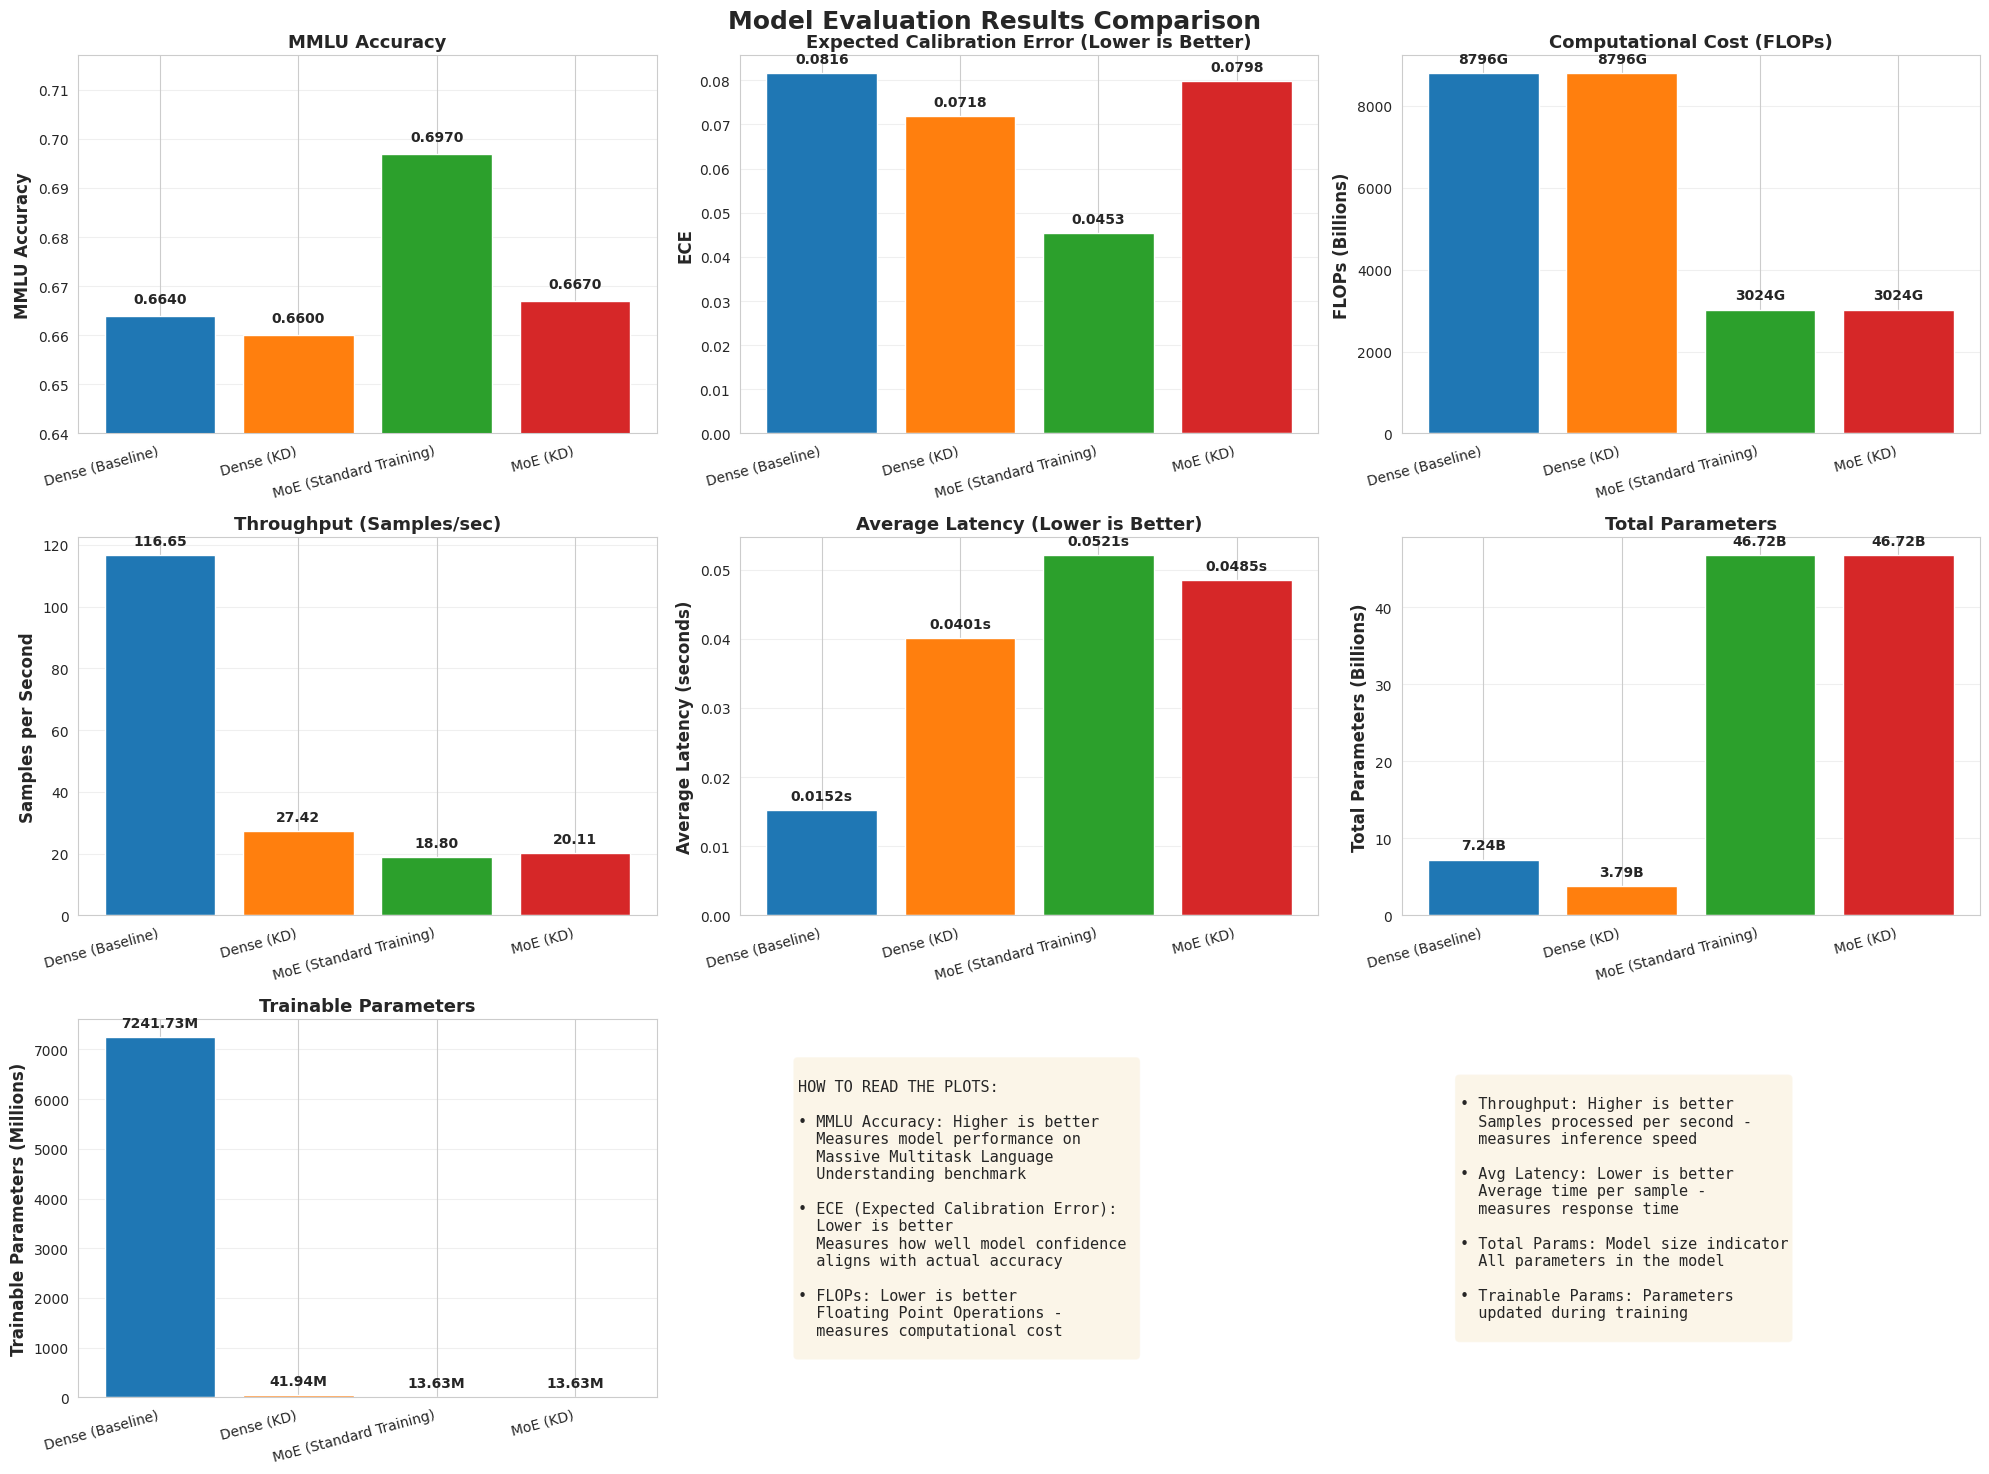

DETAILED METRICS COMPARISON



Model,MMLU Accuracy,Top-2 Accuracy,ECE,FLOPs (G),Throughput (samples/sec),Avg Latency (sec),Tokens/sec,ms/token,Total Params (B),Trainable Params (M),Model Size (MB),GPU Memory (GB),Accuracy % Change
Dense (Baseline),0.6640,0.8310,0.0816,8796.09,116.65,0.0152,33175.65,0.03,7.24,7241.73,13812.51,13.52,0.0000
Dense (KD),0.6600,0.8300,0.0718,8796.09,27.42,0.0401,7799.28,0.13,3.79,41.94,4489.02,18.35,-0.6000
MoE (Standard Training),0.6970,0.8640,0.0453,3023.66,18.80,0.0521,5346.35,0.19,46.72,13.63,89130.51,106.37,4.9700
MoE (KD),0.6670,0.8380,0.0798,3023.66,20.11,0.0485,5720.89,0.17,46.72,13.63,89130.51,106.37,0.4500


KEY INSIGHTS

✓ Best MMLU Accuracy: MoE (Standard Training) (0.6970)
✓ Best Top-2 Accuracy: MoE (Standard Training) (0.8640)
✓ Best Calibration (Lowest ECE): MoE (Standard Training) (0.0453)
✓ Highest Throughput: Dense (Baseline) (116.65 samples/sec)
✓ Lowest Latency: Dense (Baseline) (0.0152 seconds)
✓ Most Efficient (Lowest FLOPs): MoE (Standard Training) (3023.66G FLOPs)
✓ Lowest Memory: Dense (Baseline) (13.52 GB)


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from IPython.display import display, HTML

# Set style for better visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 15)

# Define the file paths for each model's results
results_files = {
    'Dense (Baseline)': 'results/baseline_comprehensive.json',
    'Dense (KD)': 'results/trained_dense_kd_comprehensive.json',
    'MoE (Standard Training)': 'results/trained_moe_comprehensive.json',
    'MoE (KD)': 'results/trained_moe_kd_comprehensive.json'
}

def load_results(filepath):
    """Load results from JSON file, handling missing files gracefully."""
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            return json.load(f)
    else:
        print(f"Warning: {filepath} not found. Returning None.")
        return None

# Load all results
all_results = {}
for model_name, filepath in results_files.items():
    results = load_results(filepath)
    if results is not None:
        all_results[model_name] = results

# Check if we have all the files
if len(all_results) < len(results_files):
    missing = [name for name, path in results_files.items() if name not in all_results]
    print(f"Warning: Missing results for: {missing}")
    print("Available files:")
    for name in all_results.keys():
        print(f"  ✓ {name}")

# Extract metrics and create DataFrame
results_data = []
for model_name, data in all_results.items():
    if data is None:
        continue
    
    # Extract all relevant metrics
    row = {
        'Model': model_name,
        'MMLU Accuracy': data.get('accuracy', np.nan),
        'Top-2 Accuracy': data.get('top2_accuracy', np.nan),
        'ECE': data.get('ece', np.nan),
        'FLOPs (G)': data.get('flops', 0) / 1e9 if data.get('flops') else np.nan,
        'Throughput (samples/sec)': data.get('samples_per_second', np.nan),
        'Avg Latency (sec)': data.get('avg_latency', np.nan),
        'Tokens/sec': data.get('tokens_per_second', np.nan),
        'ms/token': data.get('ms_per_token', np.nan),
        'Total Params (B)': data.get('total_params', 0) / 1e9 if data.get('total_params') else np.nan,
        'Active Params (B)': data.get('active_params', 0) / 1e9 if data.get('active_params') else np.nan,
        'Trainable Params (M)': data.get('trainable_params', 0) / 1e6 if data.get('trainable_params') else np.nan,
        'Model Size (MB)': data.get('model_size_mb', np.nan),
        'GPU Memory (GB)': data.get('gpu_memory_allocated_gb', np.nan),
    }
    results_data.append(row)

# Create DataFrame
df = pd.DataFrame(results_data)

# Calculate improvements vs baseline if baseline exists
if 'Dense (Baseline)' in df['Model'].values:
    baseline_idx = df[df['Model'] == 'Dense (Baseline)'].index[0]
    baseline_acc = df.loc[baseline_idx, 'MMLU Accuracy']
    df['Accuracy vs Baseline'] = df['MMLU Accuracy'] - baseline_acc
    df['Accuracy % Change'] = ((df['MMLU Accuracy'] - baseline_acc) / baseline_acc * 100).round(2)

# Format the DataFrame for display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("COMPREHENSIVE MODEL EVALUATION RESULTS")
print(f"Data loaded from JSON files in 'results/' directory")
print()

# Display main metrics table
display_cols = ['Model', 'MMLU Accuracy', 'Top-2 Accuracy', 'ECE', 
                'FLOPs (G)', 'Throughput (samples/sec)', 'Avg Latency (sec)',
                'Total Params (B)', 'Trainable Params (M)', 'GPU Memory (GB)']

if 'Accuracy % Change' in df.columns:
    display_cols.append('Accuracy % Change')

df_display = df[display_cols].copy()

# Format numeric columns for better readability
for col in df_display.columns:
    if col != 'Model':
        if 'Accuracy' in col or 'ECE' in col:
            df_display[col] = df_display[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
        elif 'Params' in col or 'Size' in col or 'Memory' in col:
            df_display[col] = df_display[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A')
        elif 'Change' in col:
            df_display[col] = df_display[col].apply(lambda x: f'{x:+.2f}%' if pd.notna(x) else 'N/A')
        elif 'Latency' in col:
            df_display[col] = df_display[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
        else:
            df_display[col] = df_display[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A')

print("Main Metrics Table:")
print()
display(HTML(df_display.to_html(index=False, escape=False, classes='table table-striped')))

# Create visualizations (only for models with valid data)
valid_df = df.dropna(subset=['MMLU Accuracy'])

if len(valid_df) > 0:
    # Create 7 plots in a 3x3 grid (2 empty spots for key)
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    fig.suptitle('Model Evaluation Results Comparison', fontsize=18, fontweight='bold')
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(valid_df)]
    
    # 1. MMLU Accuracy comparison
    ax = axes[0, 0]
    bars = ax.bar(valid_df['Model'], valid_df['MMLU Accuracy'], color=colors)
    ax.set_ylabel('MMLU Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('MMLU Accuracy', fontsize=13, fontweight='bold')
    if len(valid_df) > 0:
        y_min = valid_df['MMLU Accuracy'].min() - 0.02
        y_max = valid_df['MMLU Accuracy'].max() + 0.02
        ax.set_ylim([max(0, y_min), y_max])
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, valid_df['MMLU Accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # 2. ECE (Expected Calibration Error)
    ax = axes[0, 1]
    bars = ax.bar(valid_df['Model'], valid_df['ECE'], color=colors)
    ax.set_ylabel('ECE', fontsize=12, fontweight='bold')
    ax.set_title('Expected Calibration Error (Lower is Better)', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, valid_df['ECE']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valid_df['ECE']) * 0.02, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # 3. FLOPs comparison
    ax = axes[0, 2]
    bars = ax.bar(valid_df['Model'], valid_df['FLOPs (G)'], color=colors)
    ax.set_ylabel('FLOPs (Billions)', fontsize=12, fontweight='bold')
    ax.set_title('Computational Cost (FLOPs)', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, valid_df['FLOPs (G)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valid_df['FLOPs (G)']) * 0.02, 
                f'{val:.0f}G', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # 4. Throughput (samples/sec)
    ax = axes[1, 0]
    bars = ax.bar(valid_df['Model'], valid_df['Throughput (samples/sec)'], color=colors)
    ax.set_ylabel('Samples per Second', fontsize=12, fontweight='bold')
    ax.set_title('Throughput (Samples/sec)', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, valid_df['Throughput (samples/sec)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valid_df['Throughput (samples/sec)']) * 0.02, 
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # 5. Average Latency
    ax = axes[1, 1]
    bars = ax.bar(valid_df['Model'], valid_df['Avg Latency (sec)'], color=colors)
    ax.set_ylabel('Average Latency (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Average Latency (Lower is Better)', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, valid_df['Avg Latency (sec)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valid_df['Avg Latency (sec)']) * 0.02, 
                f'{val:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # 6. Total Parameters
    ax = axes[1, 2]
    bars = ax.bar(valid_df['Model'], valid_df['Total Params (B)'], color=colors)
    ax.set_ylabel('Total Parameters (Billions)', fontsize=12, fontweight='bold')
    ax.set_title('Total Parameters', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, valid_df['Total Params (B)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valid_df['Total Params (B)']) * 0.02, 
                f'{val:.2f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # 7. Trainable Parameters
    ax = axes[2, 0]
    bars = ax.bar(valid_df['Model'], valid_df['Trainable Params (M)'], color=colors)
    ax.set_ylabel('Trainable Parameters (Millions)', fontsize=12, fontweight='bold')
    ax.set_title('Trainable Parameters', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, valid_df['Trainable Params (M)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valid_df['Trainable Params (M)']) * 0.02, 
                f'{val:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # Add key/legend in the empty subplots
    # Key subplot 1 (bottom middle)
    ax_key1 = axes[2, 1]
    ax_key1.axis('off')
    key_text1 = """
HOW TO READ THE PLOTS:

• MMLU Accuracy: Higher is better
  Measures model performance on 
  Massive Multitask Language 
  Understanding benchmark

• ECE (Expected Calibration Error): 
  Lower is better
  Measures how well model confidence 
  aligns with actual accuracy

• FLOPs: Lower is better
  Floating Point Operations - 
  measures computational cost
    """
    ax_key1.text(0.1, 0.5, key_text1, fontsize=11, 
                 verticalalignment='center', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Key subplot 2 (bottom right)
    ax_key2 = axes[2, 2]
    ax_key2.axis('off')
    key_text2 = """
• Throughput: Higher is better
  Samples processed per second - 
  measures inference speed

• Avg Latency: Lower is better
  Average time per sample - 
  measures response time

• Total Params: Model size indicator
  All parameters in the model

• Trainable Params: Parameters 
  updated during training
    """
    ax_key2.text(0.1, 0.5, key_text2, fontsize=11,
                 verticalalignment='center', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout()
    plt.show()

    # Create a detailed comparison table
    print("DETAILED METRICS COMPARISON")
    print()

    detailed_cols = ['Model', 'MMLU Accuracy', 'Top-2 Accuracy', 'ECE', 
                     'FLOPs (G)', 'Throughput (samples/sec)', 'Avg Latency (sec)',
                     'Tokens/sec', 'ms/token', 'Total Params (B)', 'Trainable Params (M)', 
                     'Model Size (MB)', 'GPU Memory (GB)']
    
    if 'Accuracy % Change' in df.columns:
        detailed_cols.append('Accuracy % Change')
    
    detailed_df = df[detailed_cols].copy()

    # Format all numeric columns
    for col in detailed_df.columns:
        if col != 'Model':
            if 'Accuracy' in col or 'ECE' in col:
                detailed_df[col] = detailed_df[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
            elif 'Params' in col or 'Size' in col or 'Memory' in col:
                detailed_df[col] = detailed_df[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A')
            elif 'Change' in col:
                detailed_df[col] = detailed_df[col].apply(lambda x: f'{x:+.2f}%' if pd.notna(x) else 'N/A')
            elif 'Latency' in col:
                detailed_df[col] = detailed_df[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
            else:
                detailed_df[col] = detailed_df[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'N/A')

    display(HTML(detailed_df.to_html(index=False, escape=False, classes='table table-striped table-bordered')))

    
    print("KEY INSIGHTS")
  
    print()
    
    if not valid_df.empty:
        if 'MMLU Accuracy' in valid_df.columns:
            best_acc_idx = valid_df['MMLU Accuracy'].idxmax()
            print(f"✓ Best MMLU Accuracy: {valid_df.loc[best_acc_idx, 'Model']} ({valid_df.loc[best_acc_idx, 'MMLU Accuracy']:.4f})")
        
        if 'Top-2 Accuracy' in valid_df.columns:
            best_top2_idx = valid_df['Top-2 Accuracy'].idxmax()
            print(f"✓ Best Top-2 Accuracy: {valid_df.loc[best_top2_idx, 'Model']} ({valid_df.loc[best_top2_idx, 'Top-2 Accuracy']:.4f})")
        
        if 'ECE' in valid_df.columns:
            best_ece_idx = valid_df['ECE'].idxmin()
            print(f"✓ Best Calibration (Lowest ECE): {valid_df.loc[best_ece_idx, 'Model']} ({valid_df.loc[best_ece_idx, 'ECE']:.4f})")
        
        if 'Throughput (samples/sec)' in valid_df.columns:
            best_throughput_idx = valid_df['Throughput (samples/sec)'].idxmax()
            print(f"✓ Highest Throughput: {valid_df.loc[best_throughput_idx, 'Model']} ({valid_df.loc[best_throughput_idx, 'Throughput (samples/sec)']:.2f} samples/sec)")
        
        if 'Avg Latency (sec)' in valid_df.columns:
            best_latency_idx = valid_df['Avg Latency (sec)'].idxmin()
            print(f"✓ Lowest Latency: {valid_df.loc[best_latency_idx, 'Model']} ({valid_df.loc[best_latency_idx, 'Avg Latency (sec)']:.4f} seconds)")
        
        if 'FLOPs (G)' in valid_df.columns:
            best_flops_idx = valid_df['FLOPs (G)'].idxmin()
            print(f"✓ Most Efficient (Lowest FLOPs): {valid_df.loc[best_flops_idx, 'Model']} ({valid_df.loc[best_flops_idx, 'FLOPs (G)']:.2f}G FLOPs)")
        
        if 'GPU Memory (GB)' in valid_df.columns:
            best_mem_idx = valid_df['GPU Memory (GB)'].idxmin()
            print(f"✓ Lowest Memory: {valid_df.loc[best_mem_idx, 'Model']} ({valid_df.loc[best_mem_idx, 'GPU Memory (GB)']:.2f} GB)")
else:
    print("No valid data found to visualize.")

LOADING ALL METRICS (CORRECT TEACHER ASSIGNMENTS)
Dense KD: Dense Baseline as teacher
MoE Standard: MoE Baseline as teacher
MoE KD: MoE Baseline as teacher
MoE Baseline: Knowledge transfer from Dense Baseline

Loaded metrics for:
  Baselines: ['dense_baseline', 'moe_baseline']
  Training metrics: ['dense_kd', 'moe_kd', 'moe_standard']
  Post-training KD metrics: ['dense_kd', 'moe_standard', 'moe_kd', 'moe_baseline_knowledge_transfer']
  Comprehensive results: ['dense_kd', 'moe_standard', 'moe_kd']

GENERATING TRAINING LOSSES VISUALIZATION (ALL MODELS)
Saved training losses visualization to results/training_losses_all_models.png


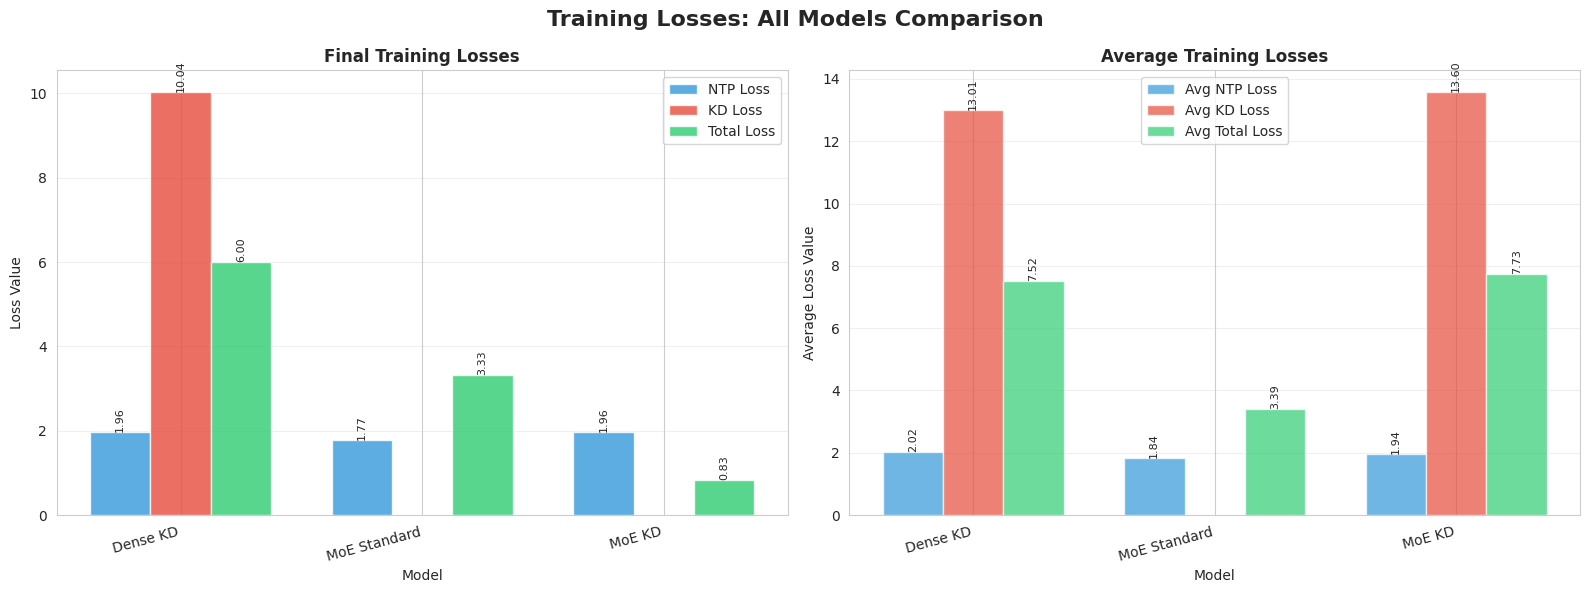


GENERATING RETENTION RATES VISUALIZATION (ALL MODELS)
Saved retention rates visualization to results/retention_rates_all_models.png


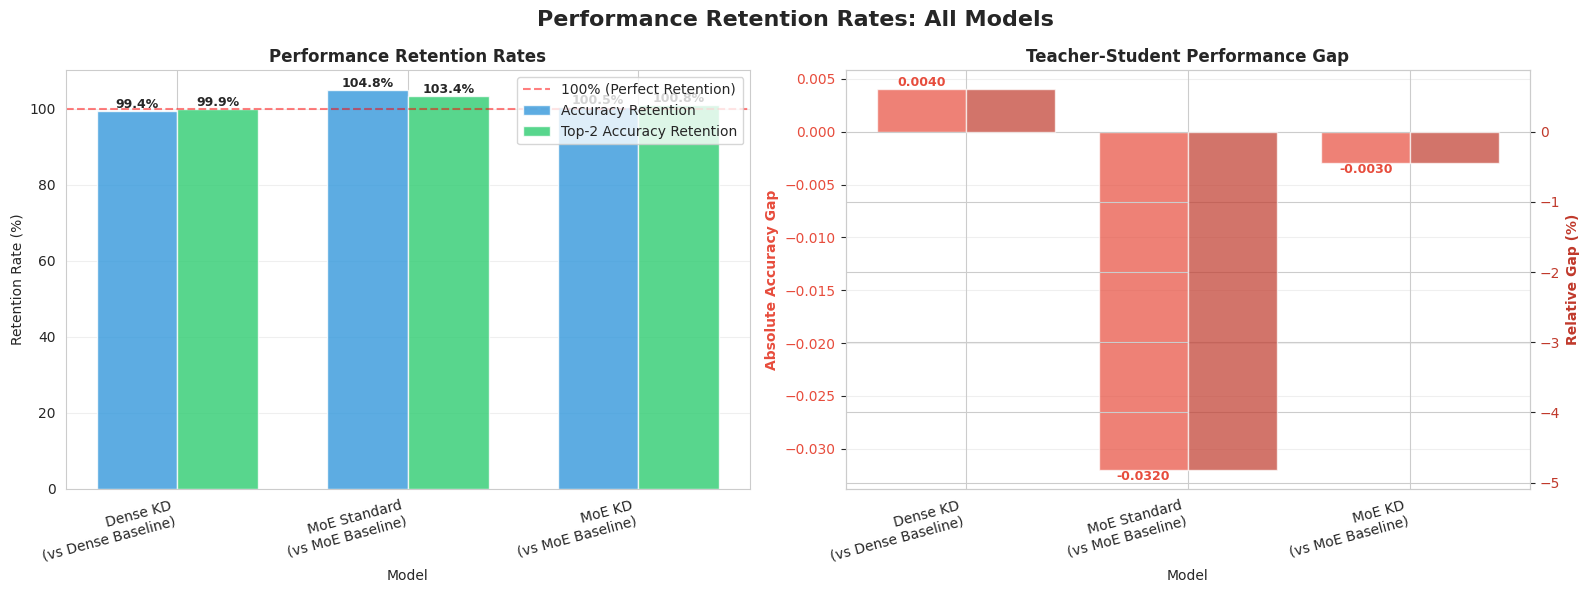


GENERATING KNOWLEDGE TRANSFER EFFICIENCY VISUALIZATION (ALL MODELS)
Saved KTE visualization to results/kte_all_models.png


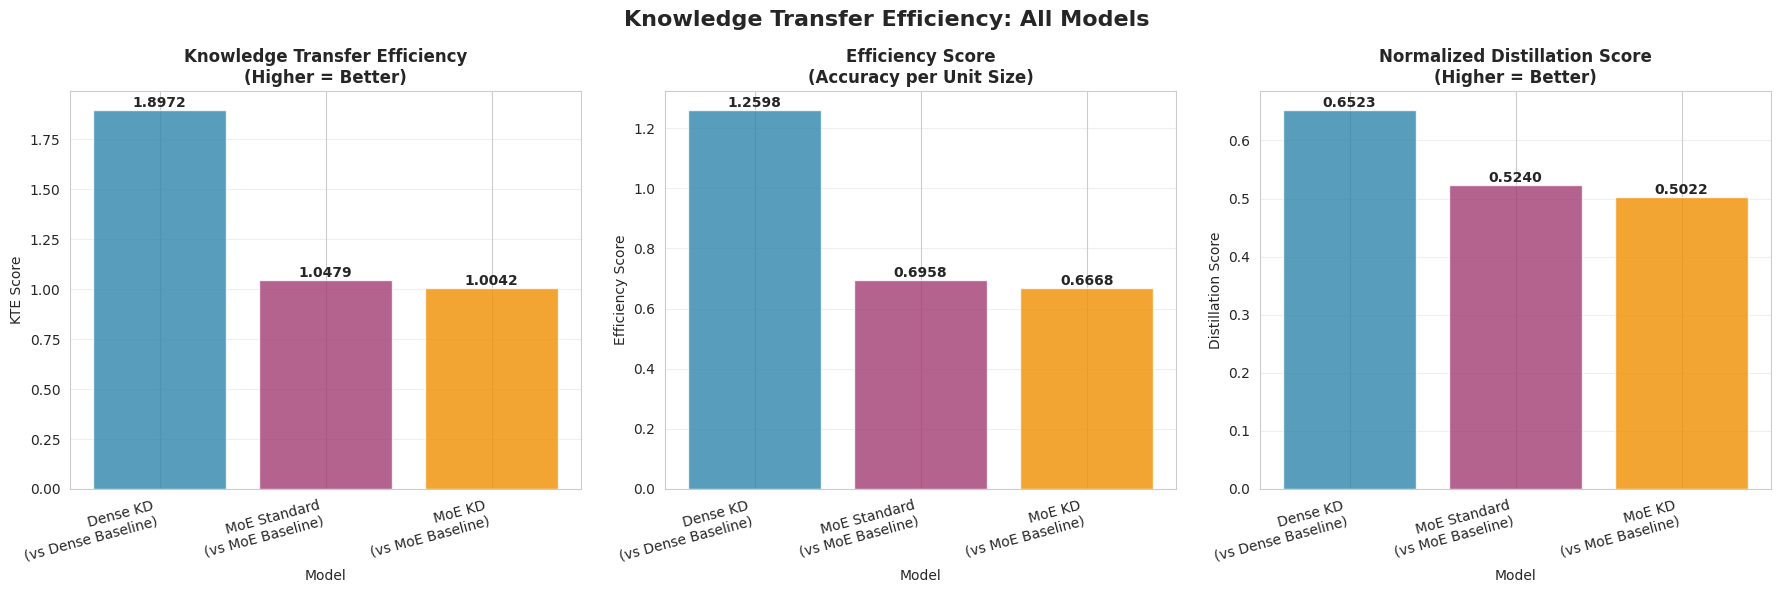


GENERATING MOE BASELINE KNOWLEDGE TRANSFER VISUALIZATION
Saved MoE baseline knowledge transfer visualization to results/moe_baseline_knowledge_transfer.png


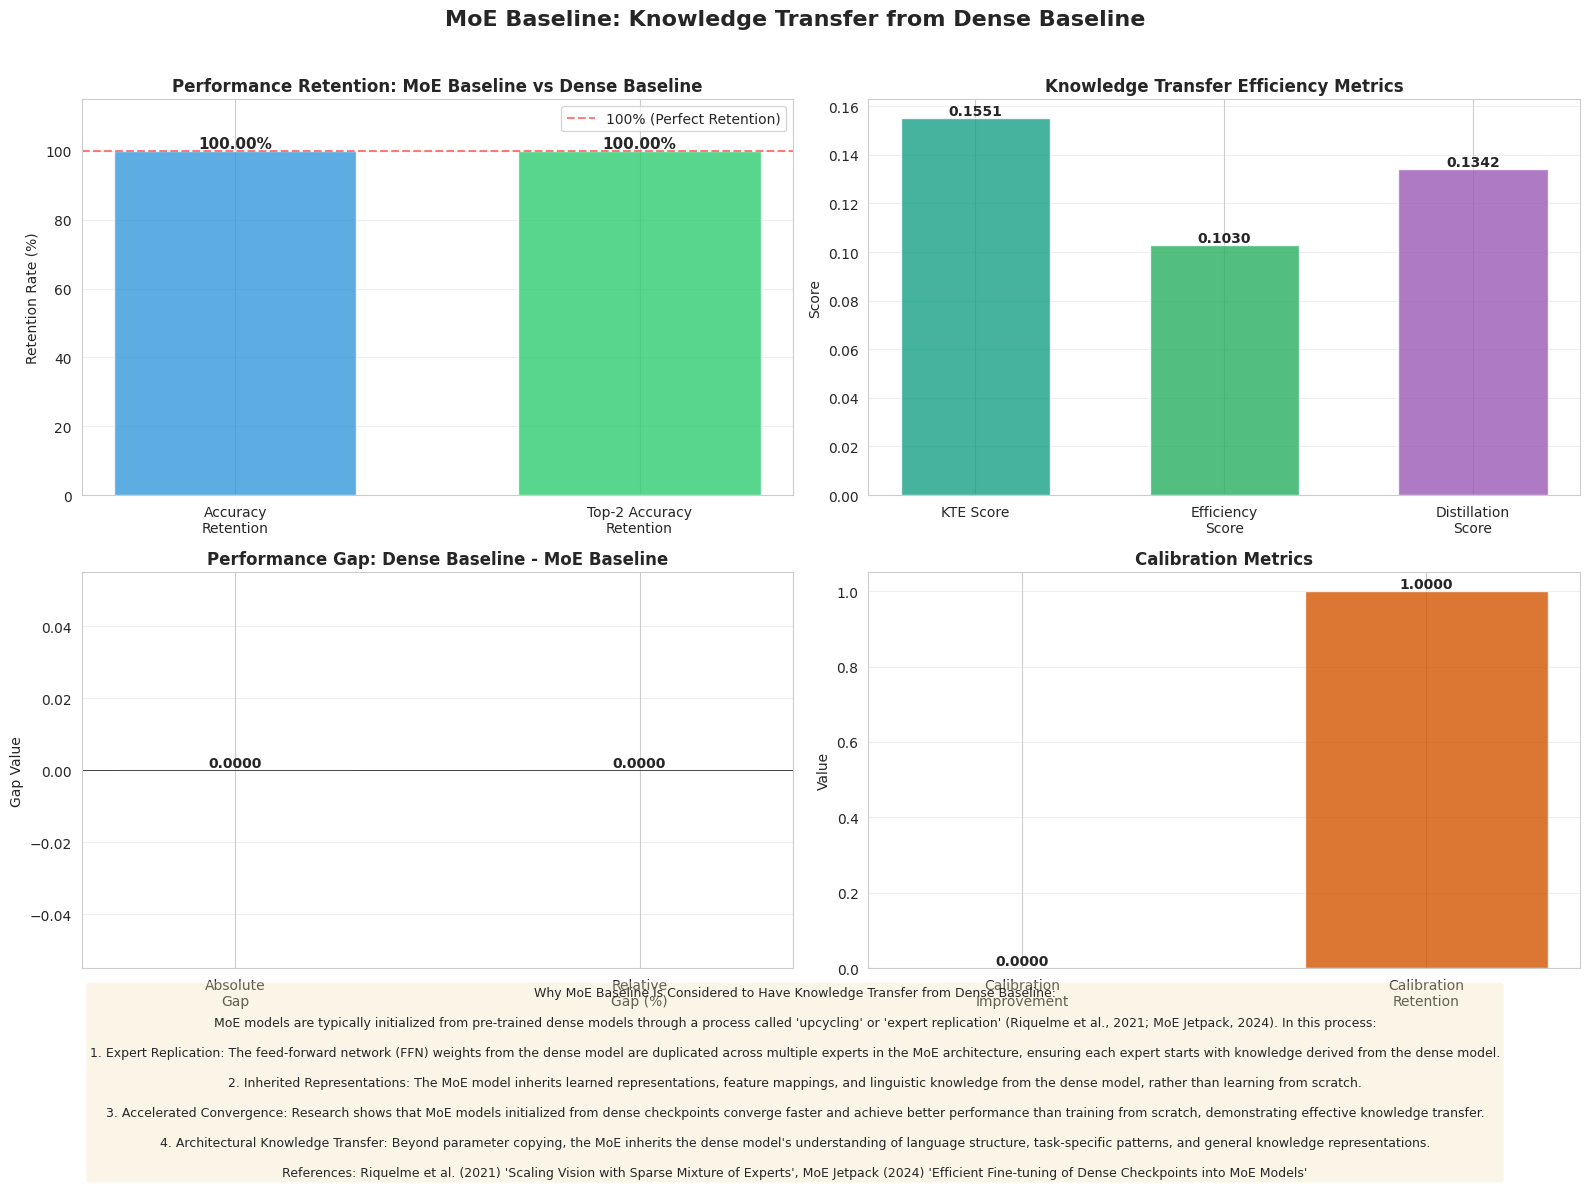


ALL VISUALIZATIONS COMPLETE!


In [42]:
# COMPREHENSIVE KD METRICS VISUALIZATION (ALL 4 MODELS)
# Dense KD uses Dense Baseline as teacher
# MoE models use MoE Baseline as teacher
# MoE Baseline shows knowledge transfer from Dense Baseline

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# 1. LOAD ALL METRICS (CORRECT TEACHER ASSIGNMENTS)

def load_all_metrics_with_correct_teachers():
    """Load all metrics with correct teacher assignments:
    - Dense KD: Dense Baseline as teacher
    - MoE Standard: MoE Baseline as teacher
    - MoE KD: MoE Baseline as teacher
    """
    metrics = {
        'training': {},
        'post_training': {},
        'comprehensive': {},
        'baselines': {}
    }
    
    results_dir = Path("results")
    
    # Load baselines
    baseline_files = {
        'dense_baseline': results_dir / "baseline_comprehensive.json",
        'moe_baseline': results_dir / "moe_baseline_comprehensive.json",
    }
    
    for baseline_name, file_path in baseline_files.items():
        if file_path.exists():
            with open(file_path, 'r') as f:
                metrics['baselines'][baseline_name] = json.load(f)
        # Also try loading from globals
        elif baseline_name == 'dense_baseline' and 'baseline_comprehensive' in globals():
            metrics['baselines'][baseline_name] = baseline_comprehensive
        elif baseline_name == 'moe_baseline' and 'moe_comprehensive' in globals():
            metrics['baselines'][baseline_name] = moe_comprehensive
    
    if 'dense_baseline' not in metrics['baselines']:
        print("Warning: Dense baseline not found.")
    if 'moe_baseline' not in metrics['baselines']:
        print("Warning: MoE baseline not found.")
    
    # Load training metrics
    training_metrics_file = results_dir / "training_metrics_comparison.json"
    if training_metrics_file.exists():
        with open(training_metrics_file, 'r') as f:
            metrics['training'] = json.load(f)
    
    # Load comprehensive evaluation results
    eval_files = {
        'dense_kd': results_dir / "trained_dense_kd_comprehensive.json",
        'moe_standard': results_dir / "trained_moe_standard_comprehensive.json",
        'moe_kd': results_dir / "trained_moe_kd_comprehensive.json",
    }
    
    for model_name, file_path in eval_files.items():
        if file_path.exists():
            with open(file_path, 'r') as f:
                data = json.load(f)
                metrics['comprehensive'][model_name] = data
                
                # Extract training metrics if embedded
                if 'training_metrics' in data:
                    if model_name not in metrics['training']:
                        metrics['training'][model_name] = data['training_metrics']
    
    # Compute KD metrics with correct teacher assignments
    dense_baseline = metrics['baselines'].get('dense_baseline')
    moe_baseline = metrics['baselines'].get('moe_baseline')
    
    # Dense KD: Use Dense Baseline as teacher
    if 'dense_kd' in metrics['comprehensive'] and dense_baseline:
        try:
            kd_metrics = compute_kd_specific_metrics(
                teacher_metrics=dense_baseline,
                student_kd_metrics=metrics['comprehensive']['dense_kd'],
                student_no_kd_metrics=None,
                kd_config=KD_CONFIG_DENSE if 'KD_CONFIG_DENSE' in globals() else None,
                alpha=0.5
            )
            metrics['post_training']['dense_kd'] = kd_metrics
        except Exception as e:
            print(f"Warning: Could not compute KD metrics for dense_kd: {e}")
    
    # MoE Standard: Use MoE Baseline as teacher
    if 'moe_standard' in metrics['comprehensive'] and moe_baseline:
        try:
            kd_metrics = compute_kd_specific_metrics(
                teacher_metrics=moe_baseline,
                student_kd_metrics=metrics['comprehensive']['moe_standard'],
                student_no_kd_metrics=None,
                kd_config=None,  # No KD in standard training
                alpha=0.5
            )
            metrics['post_training']['moe_standard'] = kd_metrics
        except Exception as e:
            print(f"Warning: Could not compute KD metrics for moe_standard: {e}")
    
    # MoE KD: Use MoE Baseline as teacher
    if 'moe_kd' in metrics['comprehensive'] and moe_baseline:
        try:
            student_no_kd = metrics['comprehensive'].get('moe_standard')
            kd_metrics = compute_kd_specific_metrics(
                teacher_metrics=moe_baseline,
                student_kd_metrics=metrics['comprehensive']['moe_kd'],
                student_no_kd_metrics=student_no_kd,
                kd_config=KD_CONFIG if 'KD_CONFIG' in globals() else None,
                alpha=0.5
            )
            metrics['post_training']['moe_kd'] = kd_metrics
        except Exception as e:
            print(f"Warning: Could not compute KD metrics for moe_kd: {e}")
    
    # Compute MoE Baseline knowledge transfer from Dense Baseline
    if dense_baseline and moe_baseline:
        try:
            moe_knowledge_transfer = compute_kd_specific_metrics(
                teacher_metrics=dense_baseline,
                student_kd_metrics=moe_baseline,
                student_no_kd_metrics=None,
                kd_config=None,
                alpha=0.5
            )
            metrics['post_training']['moe_baseline_knowledge_transfer'] = moe_knowledge_transfer
        except Exception as e:
            print(f"Warning: Could not compute knowledge transfer metrics for MoE baseline: {e}")
    
    return metrics

# 2. VISUALIZE TRAINING LOSSES FOR ALL MODELS

def plot_training_losses_all_models(metrics_data, save_path="results/training_losses_all_models.png"):
    """Create visualization for training losses across all models."""
    
    if not metrics_data:
        print("No training metrics data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Training Losses: All Models Comparison', fontsize=16, fontweight='bold')
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = ['Dense KD', 'MoE Standard', 'MoE KD']
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in metrics_data]
    available_labels = [model_labels[models.index(m)] for m in available_models]
    
    if not available_models:
        print("No training metrics available for plotting")
        return
    
    x = np.arange(len(available_models))
    width = 0.25
    
    # 1. Final Losses
    ax = axes[0]
    final_ntp = [metrics_data[m].get('final_ntp_loss', 0) for m in available_models]
    final_kd = [metrics_data[m].get('final_kd_loss', 0) for m in available_models]
    final_total = [metrics_data[m].get('final_total_loss', 0) for m in available_models]
    
    ax.bar(x - width, final_ntp, width, label='NTP Loss', color='#3498db', alpha=0.8)
    ax.bar(x, final_kd, width, label='KD Loss', color='#e74c3c', alpha=0.8)
    ax.bar(x + width, final_total, width, label='Total Loss', color='#2ecc71', alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Loss Value')
    ax.set_title('Final Training Losses', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (ntp, kd, total) in enumerate(zip(final_ntp, final_kd, final_total)):
        ax.text(i - width, ntp, f'{ntp:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
        if kd > 0:
            ax.text(i, kd, f'{kd:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
        ax.text(i + width, total, f'{total:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    # 2. Average Losses
    ax = axes[1]
    avg_ntp = [metrics_data[m].get('avg_ntp_loss', 0) for m in available_models]
    avg_kd = [metrics_data[m].get('avg_kd_loss', 0) for m in available_models]
    avg_total = [metrics_data[m].get('avg_total_loss', 0) for m in available_models]
    
    ax.bar(x - width, avg_ntp, width, label='Avg NTP Loss', color='#3498db', alpha=0.7)
    ax.bar(x, avg_kd, width, label='Avg KD Loss', color='#e74c3c', alpha=0.7)
    ax.bar(x + width, avg_total, width, label='Avg Total Loss', color='#2ecc71', alpha=0.7)
    ax.set_xlabel('Model')
    ax.set_ylabel('Average Loss Value')
    ax.set_title('Average Training Losses', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (ntp, kd, total) in enumerate(zip(avg_ntp, avg_kd, avg_total)):
        ax.text(i - width, ntp, f'{ntp:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
        if kd > 0:
            ax.text(i, kd, f'{kd:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
        ax.text(i + width, total, f'{total:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved training losses visualization to {save_path}")
    plt.show()

# 3. VISUALIZE RETENTION RATES FOR ALL MODELS

def plot_retention_rates_all_models(kd_metrics_data, save_path="results/retention_rates_all_models.png"):
    """Create visualization for retention rates across all models."""
    
    if not kd_metrics_data:
        print("No post-training KD metrics data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Performance Retention Rates: All Models', fontsize=16, fontweight='bold')
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = ['Dense KD\n(vs Dense Baseline)', 'MoE Standard\n(vs MoE Baseline)', 'MoE KD\n(vs MoE Baseline)']
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in kd_metrics_data]
    available_labels = [model_labels[models.index(m)] for m in available_models]
    
    if not available_models:
        print("No retention rate data available")
        return
    
    x = np.arange(len(available_models))
    width = 0.35
    
    # 1. Accuracy Retention Rates
    ax = axes[0]
    acc_retention = [kd_metrics_data[m].get('accuracy_retention_rate', 0) for m in available_models]
    top2_retention = [kd_metrics_data[m].get('top2_accuracy_retention_rate', 0) for m in available_models]
    
    bars1 = ax.bar(x - width/2, acc_retention, width, label='Accuracy Retention', 
                   color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, top2_retention, width, label='Top-2 Accuracy Retention', 
                   color='#2ecc71', alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Retention Rate (%)')
    ax.set_title('Performance Retention Rates', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='100% (Perfect Retention)')
    ax.legend(loc='upper right')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. Teacher-Student Gap
    ax = axes[1]
    acc_gap = [kd_metrics_data[m].get('teacher_student_accuracy_gap', 0) for m in available_models]
    acc_gap_pct = [kd_metrics_data[m].get('teacher_student_accuracy_gap_pct', 0) for m in available_models]
    
    ax2 = ax.twinx()
    bars1 = ax.bar(x - 0.2, acc_gap, width=0.4, label='Absolute Gap', color='#e74c3c', alpha=0.7)
    bars2 = ax2.bar(x + 0.2, acc_gap_pct, width=0.4, label='Relative Gap (%)', color='#c0392b', alpha=0.7)
    ax.set_xlabel('Model')
    ax.set_ylabel('Absolute Accuracy Gap', color='#e74c3c', fontweight='bold')
    ax2.set_ylabel('Relative Gap (%)', color='#c0392b', fontweight='bold')
    ax.set_title('Teacher-Student Performance Gap', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.tick_params(axis='y', labelcolor='#c0392b')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    # Add value labels
    for bar, gap in zip(bars1, acc_gap):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{gap:.4f}', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=9, fontweight='bold', color='#e74c3c')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved retention rates visualization to {save_path}")
    plt.show()

# 4. VISUALIZE KNOWLEDGE TRANSFER EFFICIENCY FOR ALL MODELS

def plot_kte_all_models(kd_metrics_data, save_path="results/kte_all_models.png"):
    """Create visualization for Knowledge Transfer Efficiency across all models."""
    
    if not kd_metrics_data:
        print("No post-training KD metrics data available")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Knowledge Transfer Efficiency: All Models', fontsize=16, fontweight='bold')
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = ['Dense KD\n(vs Dense Baseline)', 'MoE Standard\n(vs MoE Baseline)', 'MoE KD\n(vs MoE Baseline)']
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in kd_metrics_data]
    available_labels = [model_labels[models.index(m)] for m in available_models]
    
    if not available_models:
        print("No KTE data available")
        return
    
    x = np.arange(len(available_models))
    
    # 1. Knowledge Transfer Efficiency (KTE)
    ax = axes[0]
    kte = [kd_metrics_data[m].get('knowledge_transfer_efficiency', 0) for m in available_models]
    bars = ax.bar(available_models, kte, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('KTE Score')
    ax.set_title('Knowledge Transfer Efficiency\n(Higher = Better)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, kte):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Efficiency Score
    ax = axes[1]
    eff_score = [kd_metrics_data[m].get('efficiency_score', 0) for m in available_models]
    bars = ax.bar(available_models, eff_score, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Efficiency Score')
    ax.set_title('Efficiency Score\n(Accuracy per Unit Size)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, eff_score):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Distillation Score
    ax = axes[2]
    dist_score = [kd_metrics_data[m].get('distillation_score_normalized', 0) for m in available_models]
    bars = ax.bar(available_models, dist_score, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Distillation Score')
    ax.set_title('Normalized Distillation Score\n(Higher = Better)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, dist_score):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved KTE visualization to {save_path}")
    plt.show()

# 5. VISUALIZE MOE BASELINE KNOWLEDGE TRANSFER FROM DENSE BASELINE

def plot_moe_baseline_knowledge_transfer(kd_metrics_data, save_path="results/moe_baseline_knowledge_transfer.png"):
    """Visualize how MoE baseline has knowledge transfer from Dense baseline."""
    
    if 'moe_baseline_knowledge_transfer' not in kd_metrics_data:
        print("MoE baseline knowledge transfer metrics not available")
        return
    
    kt_metrics = kd_metrics_data['moe_baseline_knowledge_transfer']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('MoE Baseline: Knowledge Transfer from Dense Baseline', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # 1. Performance Retention
    ax = axes[0, 0]
    acc_retention = kt_metrics.get('accuracy_retention_rate', 0)
    top2_retention = kt_metrics.get('top2_accuracy_retention_rate', 0)
    
    categories = ['Accuracy\nRetention', 'Top-2 Accuracy\nRetention']
    values = [acc_retention, top2_retention]
    colors_bars = ['#3498db', '#2ecc71']
    
    bars = ax.bar(categories, values, color=colors_bars, alpha=0.8, width=0.6)
    ax.set_ylabel('Retention Rate (%)')
    ax.set_title('Performance Retention: MoE Baseline vs Dense Baseline', fontweight='bold')
    ax.set_ylim([0, max(values) * 1.15])
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='100% (Perfect Retention)')
    ax.legend()
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 2. Knowledge Transfer Efficiency
    ax = axes[0, 1]
    kte = kt_metrics.get('knowledge_transfer_efficiency', 0)
    eff_score = kt_metrics.get('efficiency_score', 0)
    dist_score = kt_metrics.get('distillation_score_normalized', 0)
    
    categories = ['KTE Score', 'Efficiency\nScore', 'Distillation\nScore']
    values = [kte, eff_score, dist_score]
    colors_bars = ['#16a085', '#27ae60', '#9b59b6']
    
    bars = ax.bar(categories, values, color=colors_bars, alpha=0.8, width=0.6)
    ax.set_ylabel('Score')
    ax.set_title('Knowledge Transfer Efficiency Metrics', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 3. Performance Gap
    ax = axes[1, 0]
    acc_gap = kt_metrics.get('teacher_student_accuracy_gap', 0)
    acc_gap_pct = kt_metrics.get('teacher_student_accuracy_gap_pct', 0)
    
    categories = ['Absolute\nGap', 'Relative\nGap (%)']
    values = [acc_gap, acc_gap_pct]
    colors_bars = ['#e74c3c', '#c0392b']
    
    bars = ax.bar(categories, values, color=colors_bars, alpha=0.8, width=0.6)
    ax.set_ylabel('Gap Value')
    ax.set_title('Performance Gap: Dense Baseline - MoE Baseline', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=10, fontweight='bold')
    
    # 4. Calibration Comparison
    ax = axes[1, 1]
    calib_improvement = kt_metrics.get('calibration_improvement', 0)
    calib_retention = kt_metrics.get('calibration_retention', 0)
    
    categories = ['Calibration\nImprovement', 'Calibration\nRetention']
    values = [calib_improvement, calib_retention]
    colors_bars = ['#e67e22', '#d35400']
    
    bars = ax.bar(categories, values, color=colors_bars, alpha=0.8, width=0.6)
    ax.set_ylabel('Value')
    ax.set_title('Calibration Metrics', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=10, fontweight='bold')
    
    # Add explanatory footnote
    footnote_text = (
        "Why MoE Baseline is Considered to Have Knowledge Transfer from Dense Baseline:\n\n"
        "MoE models are typically initialized from pre-trained dense models through a process called "
        "'upcycling' or 'expert replication' (Riquelme et al., 2021; MoE Jetpack, 2024). In this process:\n\n"
        "1. Expert Replication: The feed-forward network (FFN) weights from the dense model are duplicated "
        "across multiple experts in the MoE architecture, ensuring each expert starts with knowledge "
        "derived from the dense model.\n\n"
        "2. Inherited Representations: The MoE model inherits learned representations, feature mappings, "
        "and linguistic knowledge from the dense model, rather than learning from scratch.\n\n"
        "3. Accelerated Convergence: Research shows that MoE models initialized from dense checkpoints "
        "converge faster and achieve better performance than training from scratch, demonstrating effective "
        "knowledge transfer.\n\n"
        "4. Architectural Knowledge Transfer: Beyond parameter copying, the MoE inherits the dense model's "
        "understanding of language structure, task-specific patterns, and general knowledge representations.\n\n"
        "References: Riquelme et al. (2021) 'Scaling Vision with Sparse Mixture of Experts', "
        "MoE Jetpack (2024) 'Efficient Fine-tuning of Dense Checkpoints into MoE Models'"
    )
    
    fig.text(0.5, 0.02, footnote_text, ha='center', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
             wrap=True)
    
    plt.tight_layout(rect=[0, 0.15, 1, 0.98])
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved MoE baseline knowledge transfer visualization to {save_path}")
    plt.show()

# 6. MAIN EXECUTION

print("=" * 80)
print("LOADING ALL METRICS (CORRECT TEACHER ASSIGNMENTS)")
print("=" * 80)
print("Dense KD: Dense Baseline as teacher")
print("MoE Standard: MoE Baseline as teacher")
print("MoE KD: MoE Baseline as teacher")
print("MoE Baseline: Knowledge transfer from Dense Baseline")
print("=" * 80)

all_metrics = load_all_metrics_with_correct_teachers()

print(f"\nLoaded metrics for:")
print(f"  Baselines: {list(all_metrics['baselines'].keys())}")
print(f"  Training metrics: {list(all_metrics['training'].keys())}")
print(f"  Post-training KD metrics: {list(all_metrics['post_training'].keys())}")
print(f"  Comprehensive results: {list(all_metrics['comprehensive'].keys())}")

# Create visualizations
if all_metrics['training']:
    print("\n" + "=" * 80)
    print("GENERATING TRAINING LOSSES VISUALIZATION (ALL MODELS)")
    print("=" * 80)
    plot_training_losses_all_models(all_metrics['training'])

if all_metrics['post_training']:
    print("\n" + "=" * 80)
    print("GENERATING RETENTION RATES VISUALIZATION (ALL MODELS)")
    print("=" * 80)
    plot_retention_rates_all_models(all_metrics['post_training'])
    
    print("\n" + "=" * 80)
    print("GENERATING KNOWLEDGE TRANSFER EFFICIENCY VISUALIZATION (ALL MODELS)")
    print("=" * 80)
    plot_kte_all_models(all_metrics['post_training'])
    
    print("\n" + "=" * 80)
    print("GENERATING MOE BASELINE KNOWLEDGE TRANSFER VISUALIZATION")
    print("=" * 80)
    plot_moe_baseline_knowledge_transfer(all_metrics['post_training'])

print("\n" + "=" * 80)
print("ALL VISUALIZATIONS COMPLETE!")
print("=" * 80)

LOADING ALL METRICS (ALL USE DENSE BASELINE AS TEACHER)
Dense KD: Dense Baseline as teacher (KD improvement vs Dense Baseline)
MoE Standard: Dense Baseline as teacher (knowledge transfer)
MoE KD: Dense Baseline as teacher (knowledge transfer)
MoE KD: KD improvement vs MoE Standard
MoE Baseline: Knowledge transfer from Dense Baseline

Loaded metrics for:
  Baselines: ['dense_baseline', 'moe_baseline']
  Training metrics: ['dense_kd', 'moe_kd', 'moe_standard']
  Post-training KD metrics: ['dense_kd', 'moe_standard', 'moe_kd', 'moe_baseline_knowledge_transfer']
  Comprehensive results: ['dense_kd', 'moe_standard', 'moe_kd']

CREATING PRIORITIZED KD METRICS TABLE
Saved prioritized KD metrics table to results/kd_metrics_prioritized_table.csv

PRIORITIZED KD METRICS TABLE (Most Important First)
       Model Teacher (Knowledge Transfer) Comparison Baseline (KD Improvement)  KD Accuracy Improvement  KD Accuracy Improvement (%)  Accuracy Retention Rate (%)  Top-2 Accuracy Retention (%)  Knowled

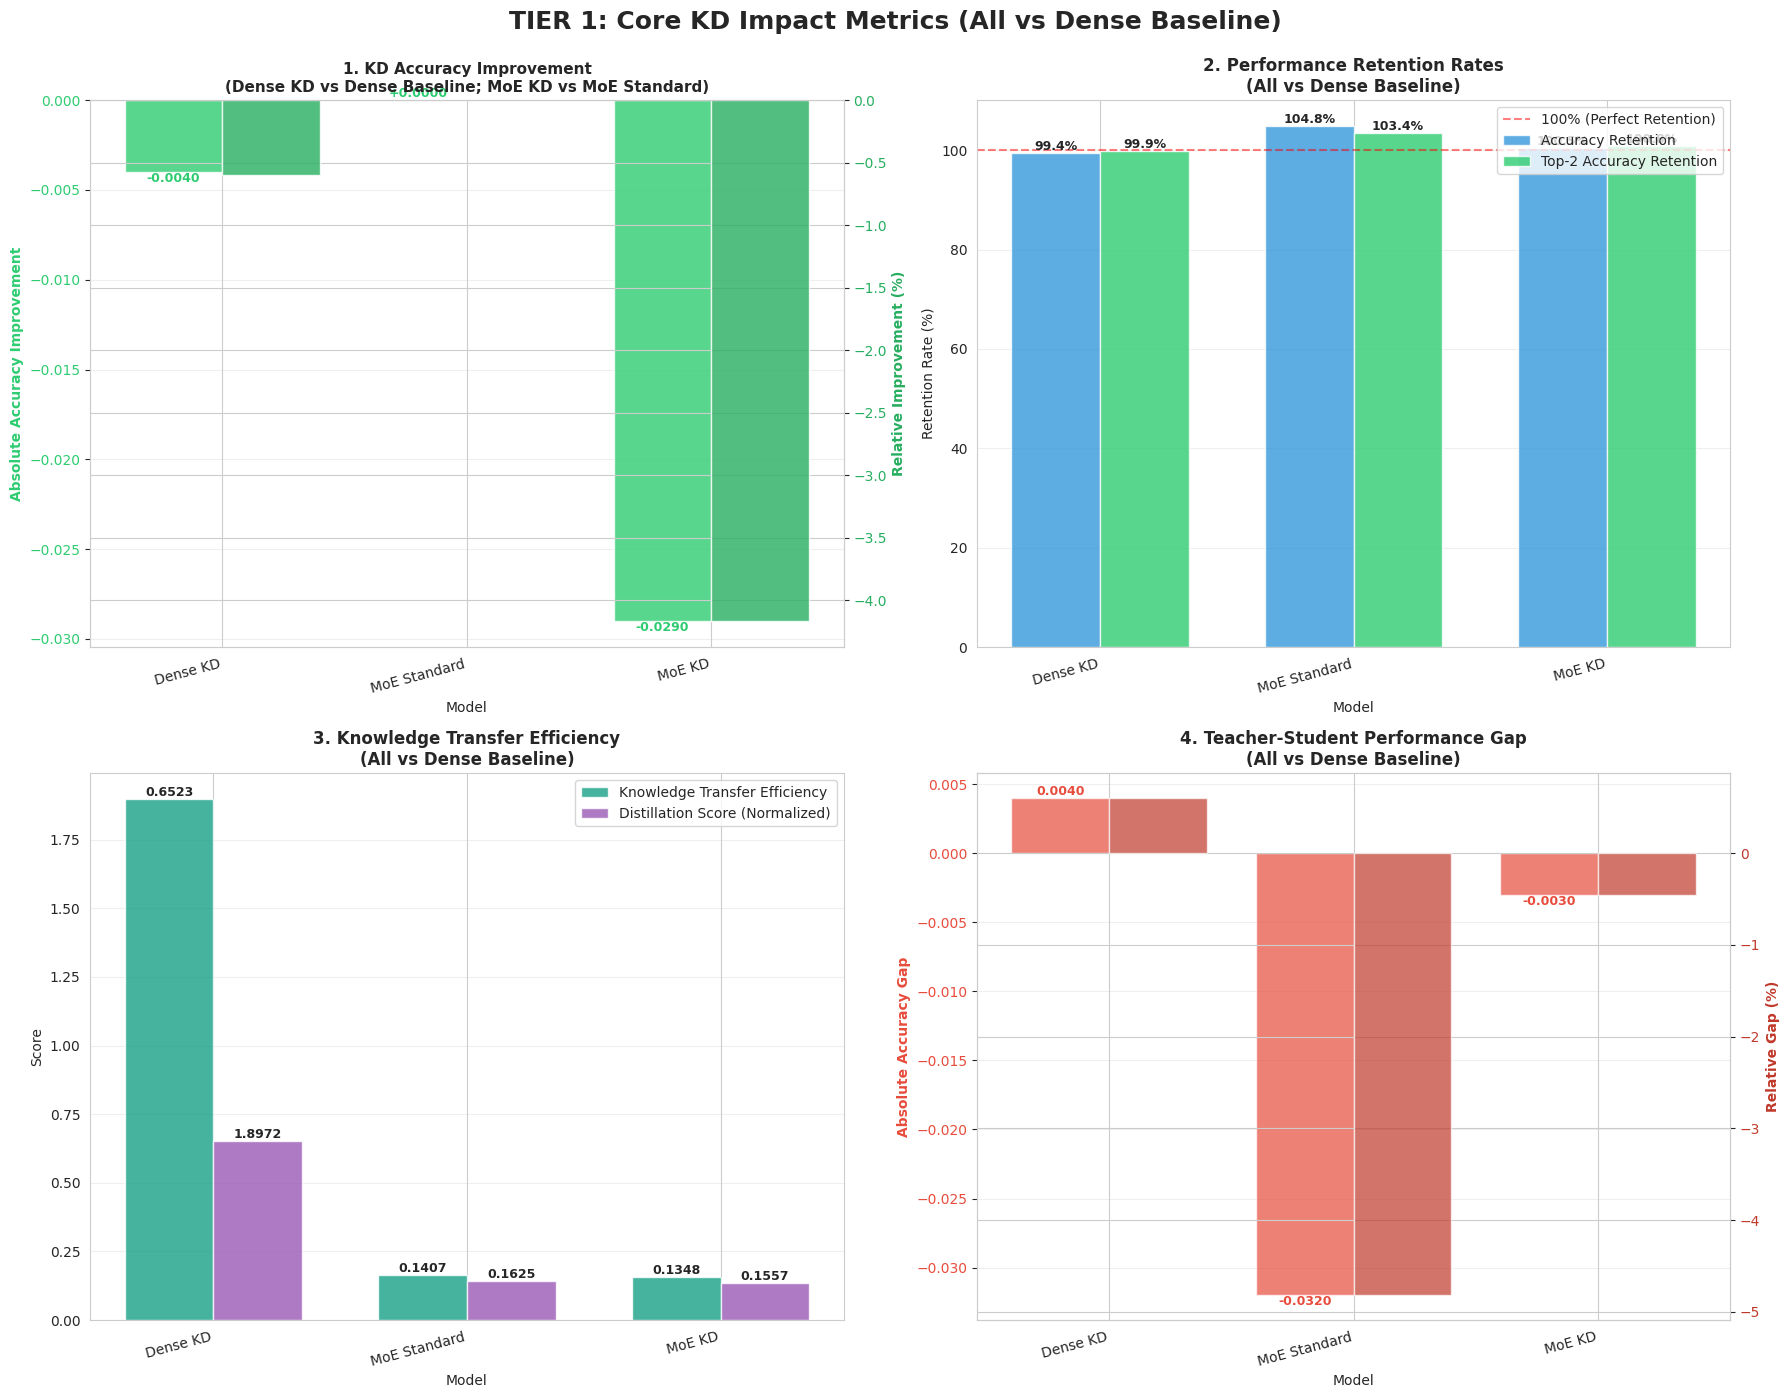


GENERATING TIER 2: COMPARATIVE ANALYSIS METRICS
Saved Tier 2 comparative metrics to results/tier2_comparative_kd_metrics.png


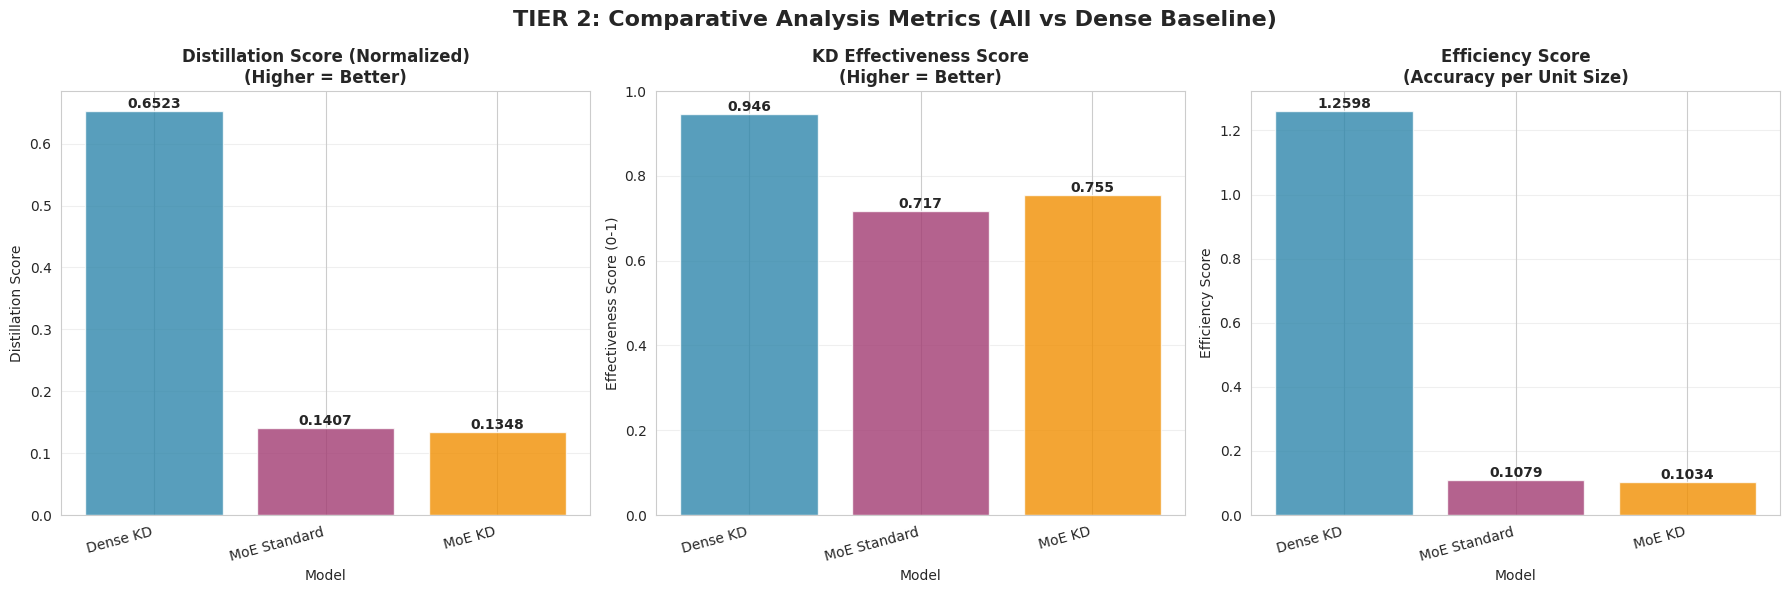


GENERATING TIER 3: TRAINING DYNAMICS METRICS
Saved Tier 3 training dynamics to results/tier3_training_dynamics.png


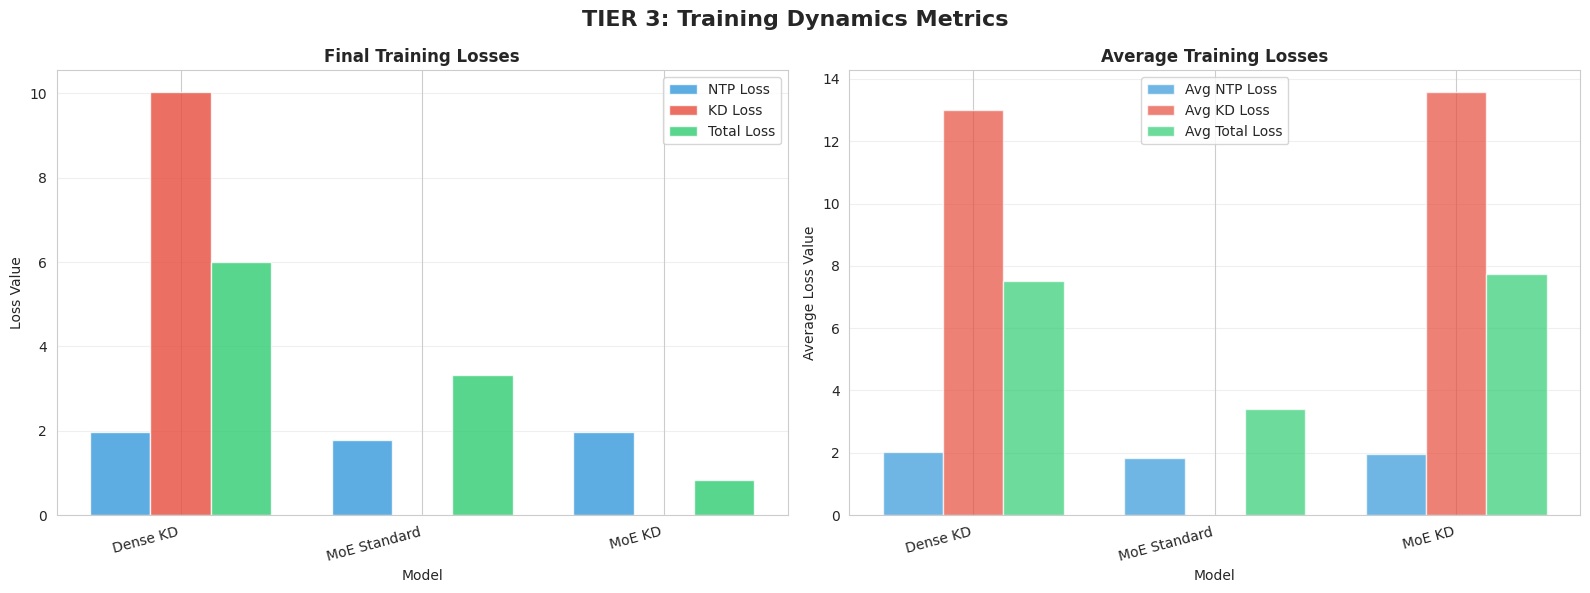


GENERATING TRAINING LOSSES VISUALIZATION (ALL MODELS)
Saved training losses visualization to results/training_losses_all_models.png


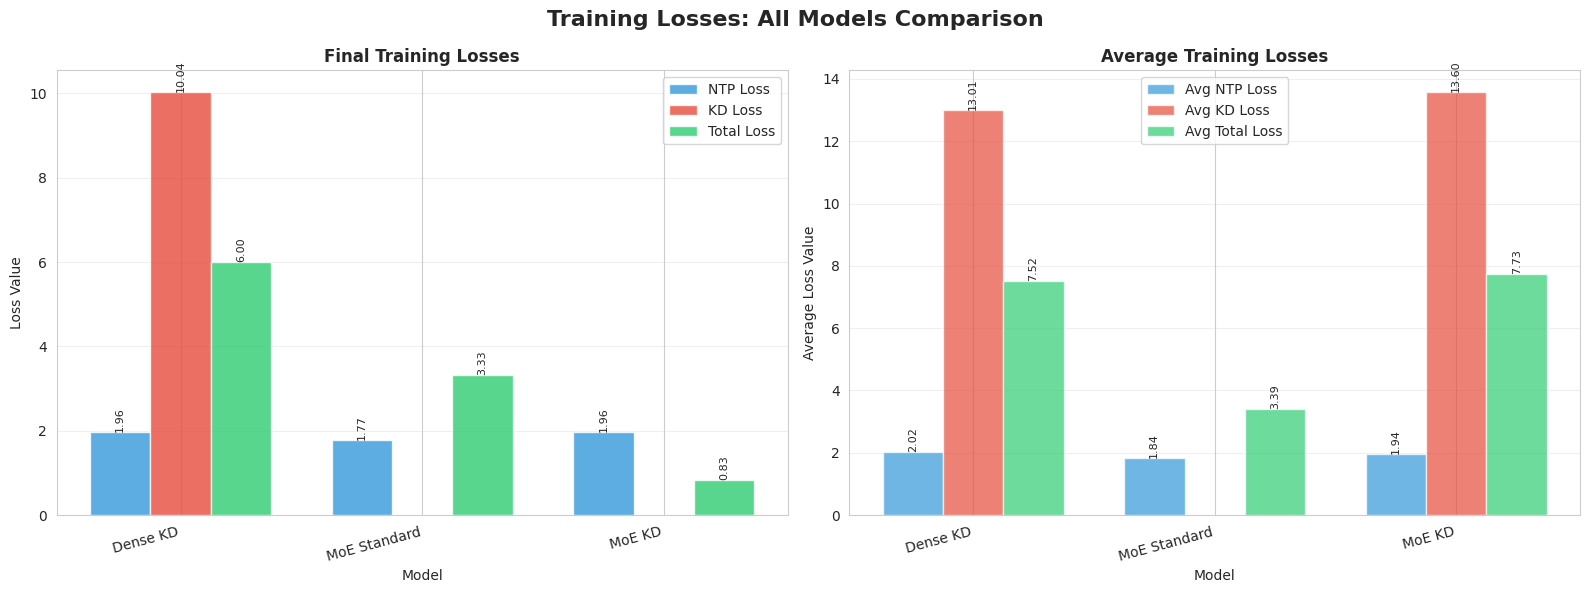


GENERATING RETENTION RATES VISUALIZATION (ALL MODELS)
Saved retention rates visualization to results/retention_rates_all_models.png


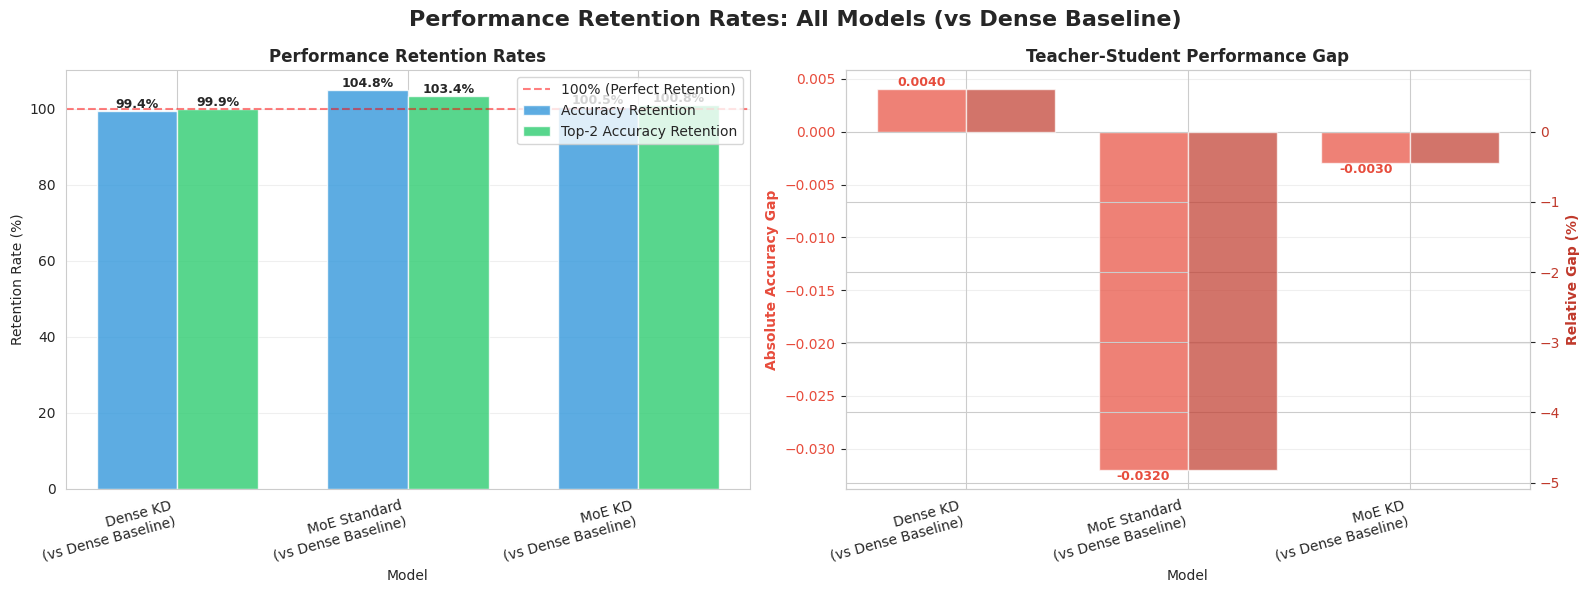


GENERATING KNOWLEDGE TRANSFER EFFICIENCY VISUALIZATION (ALL MODELS)
Saved KTE visualization to results/kte_all_models.png


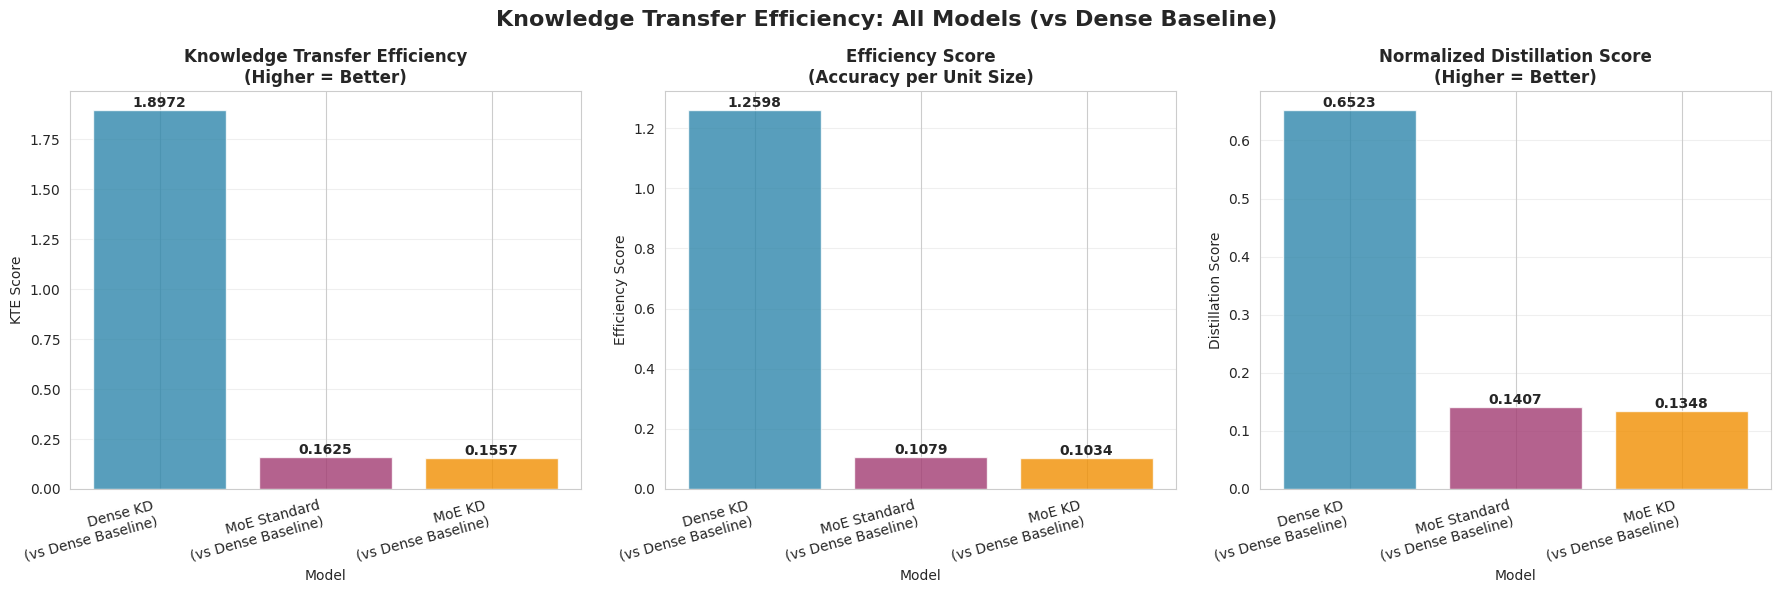


GENERATING MOE BASELINE KNOWLEDGE TRANSFER VISUALIZATION
Saved MoE baseline knowledge transfer visualization to results/moe_baseline_knowledge_transfer.png


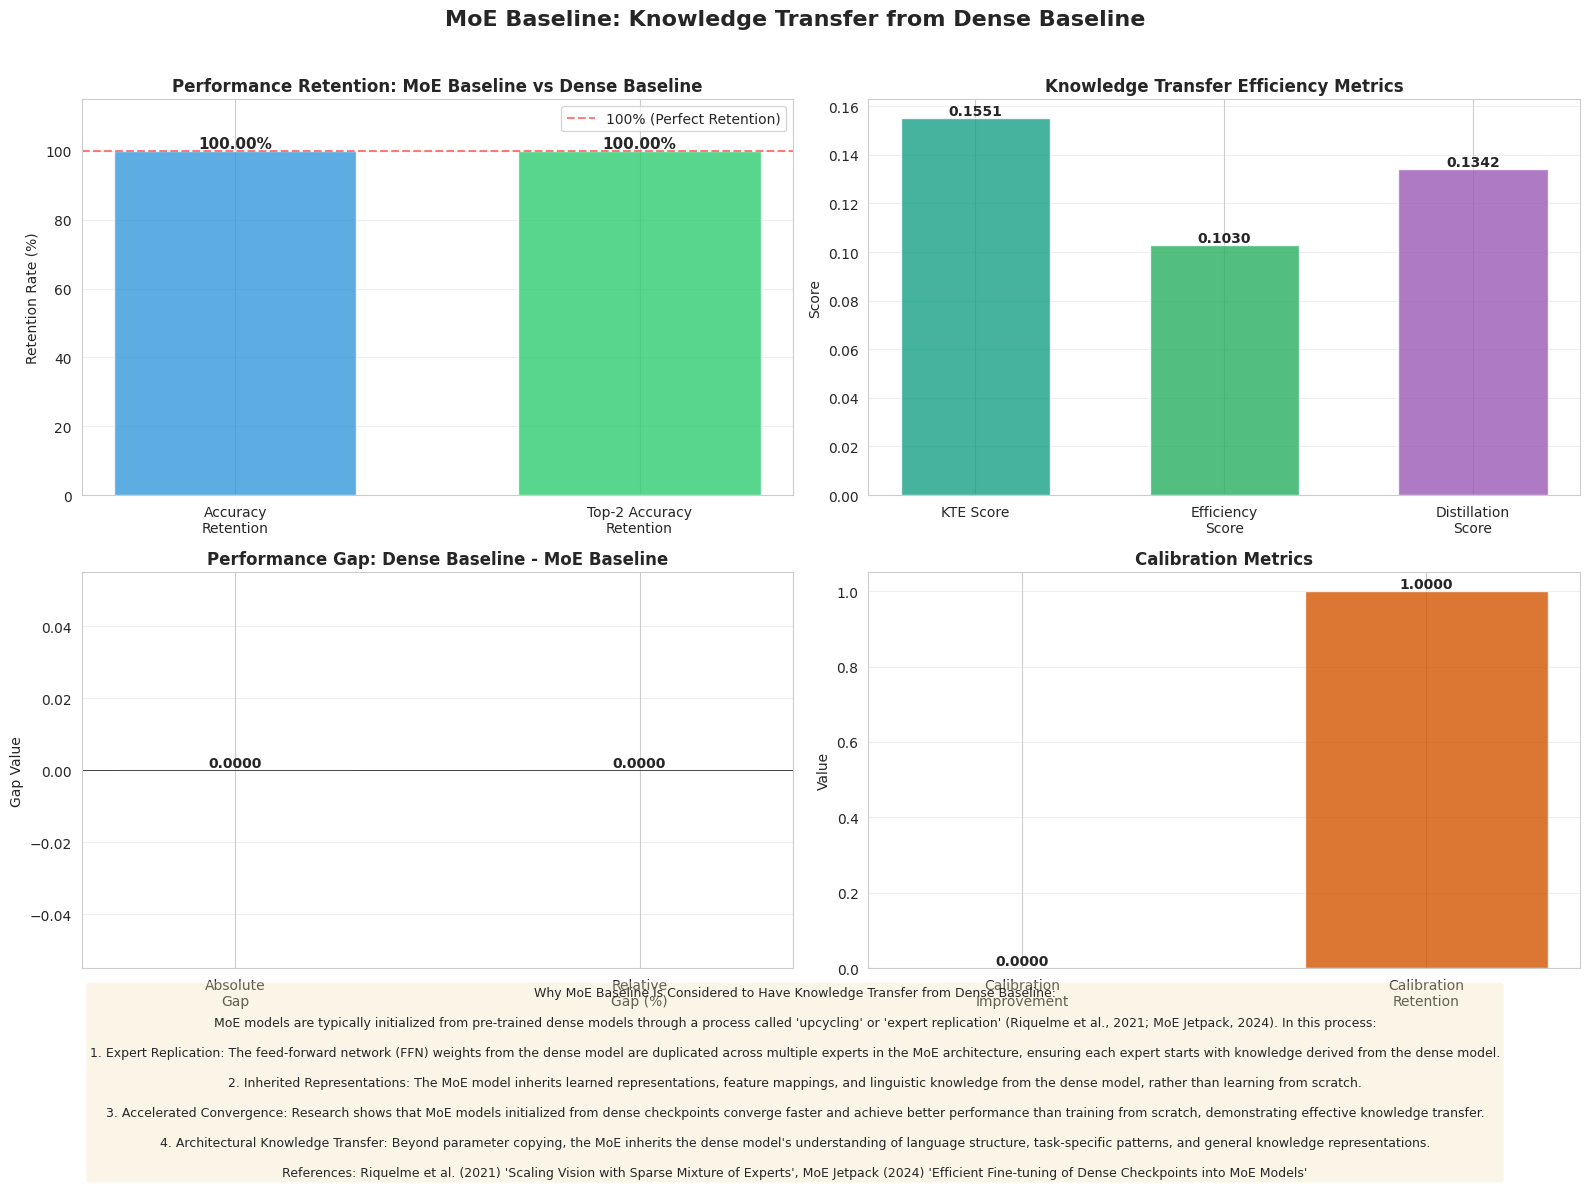


ALL VISUALIZATIONS COMPLETE!

Teacher Assignments:
  Knowledge Transfer (Retention, KTE, Gap): All models vs Dense Baseline
  KD Improvement:
    - Dense KD: vs Dense Baseline
    - MoE KD: vs MoE Standard


In [43]:
# COMPREHENSIVE KD METRICS VISUALIZATION (ALL MODELS)
# All models use Dense Baseline as teacher for knowledge transfer
# Dense KD: KD improvement vs Dense Baseline
# MoE KD: KD improvement vs MoE Standard

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10

# ============================================================================
# 1. LOAD ALL METRICS (ALL USE DENSE BASELINE AS TEACHER)
# ============================================================================

def load_all_metrics_with_dense_teacher():
    """Load all metrics with Dense Baseline as teacher for all models.
    
    Teacher assignments:
    - All models (Dense KD, MoE Standard, MoE KD): Dense Baseline as teacher for knowledge transfer
    
    KD improvement comparisons:
    - Dense KD: vs Dense Baseline (no trained standard model available)
    - MoE KD: vs MoE Standard (to show KD improvement)
    """
    metrics = {
        'training': {},
        'post_training': {},
        'comprehensive': {},
        'baselines': {}
    }
    
    results_dir = Path("results")
    
    # Load Dense Baseline (teacher for ALL models)
    baseline_file = results_dir / "baseline_comprehensive.json"
    if baseline_file.exists():
        with open(baseline_file, 'r') as f:
            metrics['baselines']['dense_baseline'] = json.load(f)
    elif 'baseline_comprehensive' in globals():
        metrics['baselines']['dense_baseline'] = baseline_comprehensive
    
    if 'dense_baseline' not in metrics['baselines']:
        print("Warning: Dense baseline not found.")
        return metrics
    
    dense_baseline = metrics['baselines']['dense_baseline']
    
    # Load MoE Baseline (for reference, but not used as teacher)
    moe_baseline_file = results_dir / "moe_baseline_comprehensive.json"
    if moe_baseline_file.exists():
        with open(moe_baseline_file, 'r') as f:
            metrics['baselines']['moe_baseline'] = json.load(f)
    elif 'moe_comprehensive' in globals():
        metrics['baselines']['moe_baseline'] = moe_comprehensive
    
    # Load training metrics
    training_metrics_file = results_dir / "training_metrics_comparison.json"
    if training_metrics_file.exists():
        with open(training_metrics_file, 'r') as f:
            metrics['training'] = json.load(f)
    
    # Load comprehensive evaluation results
    eval_files = {
        'dense_kd': results_dir / "trained_dense_kd_comprehensive.json",
        'moe_standard': results_dir / "trained_moe_standard_comprehensive.json",
        'moe_kd': results_dir / "trained_moe_kd_comprehensive.json",
    }
    
    for model_name, file_path in eval_files.items():
        if file_path.exists():
            with open(file_path, 'r') as f:
                data = json.load(f)
                metrics['comprehensive'][model_name] = data
                
                # Extract training metrics if embedded
                if 'training_metrics' in data:
                    if model_name not in metrics['training']:
                        metrics['training'][model_name] = data['training_metrics']
    
    # Compute KD metrics for ALL models using Dense Baseline as teacher
    for model_name in ['dense_kd', 'moe_standard', 'moe_kd']:
        if model_name in metrics['comprehensive']:
            student_metrics = metrics['comprehensive'][model_name]
            
            # Determine no-KD baseline for KD improvement comparison
            student_no_kd_metrics = None
            if model_name == 'dense_kd':
                # For Dense KD, compare to Dense Baseline (no trained standard model available)
                student_no_kd_metrics = dense_baseline
            elif model_name == 'moe_kd':
                # For MoE KD, compare to MoE Standard to show KD improvement
                if 'moe_standard' in metrics['comprehensive']:
                    student_no_kd_metrics = metrics['comprehensive']['moe_standard']
            
            # Get KD config if available
            kd_config = None
            if model_name in ['dense_kd', 'moe_kd']:
                if 'KD_CONFIG_DENSE' in globals() and model_name == 'dense_kd':
                    kd_config = KD_CONFIG_DENSE
                elif 'KD_CONFIG' in globals() and model_name == 'moe_kd':
                    kd_config = KD_CONFIG
            
            # Compute KD metrics using Dense Baseline as teacher for knowledge transfer
            try:
                kd_metrics = compute_kd_specific_metrics(
                    teacher_metrics=dense_baseline,  # Dense Baseline is teacher for ALL
                    student_kd_metrics=student_metrics,
                    student_no_kd_metrics=student_no_kd_metrics,  # For KD improvement comparison
                    kd_config=kd_config,
                    alpha=0.5
                )
                metrics['post_training'][model_name] = kd_metrics
            except Exception as e:
                print(f"Warning: Could not compute KD metrics for {model_name}: {e}")
    
    # Compute MoE Baseline knowledge transfer from Dense Baseline
    moe_baseline = metrics['baselines'].get('moe_baseline')
    if dense_baseline and moe_baseline:
        try:
            moe_knowledge_transfer = compute_kd_specific_metrics(
                teacher_metrics=dense_baseline,
                student_kd_metrics=moe_baseline,
                student_no_kd_metrics=None,
                kd_config=None,
                alpha=0.5
            )
            metrics['post_training']['moe_baseline_knowledge_transfer'] = moe_knowledge_transfer
        except Exception as e:
            print(f"Warning: Could not compute knowledge transfer metrics for MoE baseline: {e}")
    
    return metrics

# ============================================================================
# 2. CREATE PRIORITIZED KD METRICS TABLE
# ============================================================================

def create_prioritized_kd_metrics_table(all_metrics, save_path="results/kd_metrics_prioritized_table.csv"):
    """Create a prioritized table of the most important KD metrics."""
    
    table_data = []
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = {
        'dense_kd': 'Dense KD',
        'moe_standard': 'MoE Standard',
        'moe_kd': 'MoE KD'
    }
    
    for model_name in models:
        if model_name not in all_metrics['post_training']:
            continue
        
        kd_metrics = all_metrics['post_training'][model_name]
        training_metrics = all_metrics['training'].get(model_name, {})
        
        row = {
            'Model': model_labels[model_name],
            'Teacher (Knowledge Transfer)': 'Dense Baseline',
        }
        
        # Determine comparison baseline for KD improvement
        if model_name == 'dense_kd':
            row['Comparison Baseline (KD Improvement)'] = 'Dense Baseline'
        elif model_name == 'moe_kd':
            row['Comparison Baseline (KD Improvement)'] = 'MoE Standard'
        else:
            row['Comparison Baseline (KD Improvement)'] = 'N/A'
        
        # TIER 1: Core Impact Metrics (Most Important)
        row['KD Accuracy Improvement'] = kd_metrics.get('kd_accuracy_improvement', None)
        row['KD Accuracy Improvement (%)'] = kd_metrics.get('kd_accuracy_improvement_pct', None)
        row['Accuracy Retention Rate (%)'] = kd_metrics.get('accuracy_retention_rate', None)
        row['Top-2 Accuracy Retention (%)'] = kd_metrics.get('top2_accuracy_retention_rate', None)
        row['Knowledge Transfer Efficiency'] = kd_metrics.get('knowledge_transfer_efficiency', None)
        
        # TIER 2: Comparative Analysis
        row['Distillation Score (Normalized)'] = kd_metrics.get('distillation_score_normalized', None)
        row['Teacher-Student Accuracy Gap'] = kd_metrics.get('teacher_student_accuracy_gap', None)
        row['Teacher-Student Gap (%)'] = kd_metrics.get('teacher_student_accuracy_gap_pct', None)
        row['KD Effectiveness Score'] = kd_metrics.get('kd_effectiveness_score', None)
        
        # TIER 3: Training Dynamics
        row['Avg KD Loss'] = training_metrics.get('avg_kd_loss', None)
        row['Final KD Loss'] = training_metrics.get('final_kd_loss', None)
        row['KD/Total Loss Ratio'] = training_metrics.get('avg_kd_total_ratio', None)
        
        # TIER 4: Additional Context
        row['Calibration Improvement'] = kd_metrics.get('calibration_improvement', None)
        row['Compression Ratio'] = kd_metrics.get('compression_ratio', None)
        row['Efficiency Score'] = kd_metrics.get('efficiency_score', None)
        
        table_data.append(row)
    
    df = pd.DataFrame(table_data)
    
    # Save to CSV
    df.to_csv(save_path, index=False)
    print(f"Saved prioritized KD metrics table to {save_path}")
    
    # Display formatted table
    print("\n" + "=" * 140)
    print("PRIORITIZED KD METRICS TABLE (Most Important First)")
    print("=" * 140)
    
    # Format for display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 25)
    
    print(df.to_string(index=False))
    
    return df

# ============================================================================
# 3. VISUALIZE TIER 1: CORE IMPACT METRICS (MOST IMPORTANT)
# ============================================================================

def plot_tier1_core_impact_metrics(kd_metrics_data, save_path="results/tier1_core_kd_impact.png"):
    """Visualize the most important KD impact metrics."""
    
    if not kd_metrics_data:
        print("No post-training KD metrics data available")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('TIER 1: Core KD Impact Metrics (All vs Dense Baseline)', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = {
        'dense_kd': 'Dense KD',
        'moe_standard': 'MoE Standard',
        'moe_kd': 'MoE KD'
    }
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in kd_metrics_data]
    available_labels = [model_labels[m] for m in available_models]
    
    if not available_models:
        print("No KD metrics available for plotting")
        return
    
    x = np.arange(len(available_models))
    width = 0.35
    
    # 1. KD Accuracy Improvement (if available)
    ax = axes[0, 0]
    improvements = []
    improvement_pcts = []
    has_improvement_data = False
    
    for m in available_models:
        if 'kd_accuracy_improvement' in kd_metrics_data[m]:
            improvements.append(kd_metrics_data[m]['kd_accuracy_improvement'])
            improvement_pcts.append(kd_metrics_data[m].get('kd_accuracy_improvement_pct', 0))
            has_improvement_data = True
        else:
            improvements.append(0)
            improvement_pcts.append(0)
    
    if has_improvement_data:
        ax2 = ax.twinx()
        bars1 = ax.bar(x - 0.2, improvements, width=0.4, label='Absolute Improvement', 
                      color='#2ecc71', alpha=0.8)
        bars2 = ax2.bar(x + 0.2, improvement_pcts, width=0.4, label='Relative Improvement (%)', 
                       color='#27ae60', alpha=0.8)
        ax.set_ylabel('Absolute Accuracy Improvement', color='#2ecc71', fontweight='bold')
        ax2.set_ylabel('Relative Improvement (%)', color='#27ae60', fontweight='bold')
        ax.tick_params(axis='y', labelcolor='#2ecc71')
        ax2.tick_params(axis='y', labelcolor='#27ae60')
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        
        for bar, val in zip(bars1, improvements):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:+.4f}', ha='center', va='bottom' if height >= 0 else 'top',
                    fontsize=9, fontweight='bold', color='#2ecc71')
    else:
        ax.text(0.5, 0.5, 'KD Improvement data not available', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
    
    ax.set_xlabel('Model')
    ax.set_title('1. KD Accuracy Improvement\n(Dense KD vs Dense Baseline; MoE KD vs MoE Standard)', 
                 fontweight='bold', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Accuracy Retention Rates (vs Dense Baseline)
    ax = axes[0, 1]
    acc_retention = [kd_metrics_data[m].get('accuracy_retention_rate', 0) for m in available_models]
    top2_retention = [kd_metrics_data[m].get('top2_accuracy_retention_rate', 0) for m in available_models]
    
    bars1 = ax.bar(x - width/2, acc_retention, width, label='Accuracy Retention', 
                   color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, top2_retention, width, label='Top-2 Accuracy Retention', 
                   color='#2ecc71', alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Retention Rate (%)')
    ax.set_title('2. Performance Retention Rates\n(All vs Dense Baseline)', 
                 fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='100% (Perfect Retention)')
    ax.legend(loc='upper right')
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 3. Knowledge Transfer Efficiency (vs Dense Baseline)
    ax = axes[1, 0]
    kte = [kd_metrics_data[m].get('knowledge_transfer_efficiency', 0) for m in available_models]
    dist_score = [kd_metrics_data[m].get('distillation_score_normalized', 0) for m in available_models]
    
    bars1 = ax.bar(x - width/2, kte, width, label='Knowledge Transfer Efficiency', 
                   color='#16a085', alpha=0.8)
    bars2 = ax.bar(x + width/2, dist_score, width, label='Distillation Score (Normalized)', 
                   color='#9b59b6', alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_title('3. Knowledge Transfer Efficiency\n(All vs Dense Baseline)', 
                 fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    for bars in [bars1, bars2]:
        for bar, val in zip(bars, [kte, dist_score][bars == bars1]):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 4. Teacher-Student Gap (vs Dense Baseline)
    ax = axes[1, 1]
    acc_gap = [kd_metrics_data[m].get('teacher_student_accuracy_gap', 0) for m in available_models]
    acc_gap_pct = [kd_metrics_data[m].get('teacher_student_accuracy_gap_pct', 0) for m in available_models]
    
    ax2 = ax.twinx()
    bars1 = ax.bar(x - 0.2, acc_gap, width=0.4, label='Absolute Gap', color='#e74c3c', alpha=0.7)
    bars2 = ax2.bar(x + 0.2, acc_gap_pct, width=0.4, label='Relative Gap (%)', color='#c0392b', alpha=0.7)
    ax.set_xlabel('Model')
    ax.set_ylabel('Absolute Accuracy Gap', color='#e74c3c', fontweight='bold')
    ax2.set_ylabel('Relative Gap (%)', color='#c0392b', fontweight='bold')
    ax.set_title('4. Teacher-Student Performance Gap\n(All vs Dense Baseline)', 
                 fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.tick_params(axis='y', labelcolor='#c0392b')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    for bar, gap in zip(bars1, acc_gap):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{gap:.4f}', ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=9, fontweight='bold', color='#e74c3c')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved Tier 1 core impact metrics to {save_path}")
    plt.show()

# ============================================================================
# 4. VISUALIZE TIER 2: COMPARATIVE ANALYSIS METRICS
# ============================================================================

def plot_tier2_comparative_metrics(kd_metrics_data, save_path="results/tier2_comparative_kd_metrics.png"):
    """Visualize Tier 2 comparative analysis metrics."""
    
    if not kd_metrics_data:
        print("No post-training KD metrics data available")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('TIER 2: Comparative Analysis Metrics (All vs Dense Baseline)', fontsize=16, fontweight='bold')
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = {
        'dense_kd': 'Dense KD',
        'moe_standard': 'MoE Standard',
        'moe_kd': 'MoE KD'
    }
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in kd_metrics_data]
    available_labels = [model_labels[m] for m in available_models]
    
    if not available_models:
        return
    
    x = np.arange(len(available_models))
    
    # 1. Distillation Score (Normalized)
    ax = axes[0]
    dist_score = [kd_metrics_data[m].get('distillation_score_normalized', 0) for m in available_models]
    bars = ax.bar(available_models, dist_score, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Distillation Score')
    ax.set_title('Distillation Score (Normalized)\n(Higher = Better)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, dist_score):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. KD Effectiveness Score
    ax = axes[1]
    kd_effect = [kd_metrics_data[m].get('kd_effectiveness_score', 0) for m in available_models]
    bars = ax.bar(available_models, kd_effect, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Effectiveness Score (0-1)')
    ax.set_title('KD Effectiveness Score\n(Higher = Better)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, kd_effect):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Efficiency Score
    ax = axes[2]
    eff_score = [kd_metrics_data[m].get('efficiency_score', 0) for m in available_models]
    bars = ax.bar(available_models, eff_score, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Efficiency Score')
    ax.set_title('Efficiency Score\n(Accuracy per Unit Size)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, eff_score):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved Tier 2 comparative metrics to {save_path}")
    plt.show()

# ============================================================================
# 5. VISUALIZE TIER 3: TRAINING DYNAMICS
# ============================================================================

def plot_tier3_training_dynamics(training_metrics_data, save_path="results/tier3_training_dynamics.png"):
    """Visualize Tier 3 training dynamics metrics."""
    
    if not training_metrics_data:
        print("No training metrics data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('TIER 3: Training Dynamics Metrics', fontsize=16, fontweight='bold')
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = ['Dense KD', 'MoE Standard', 'MoE KD']
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in training_metrics_data]
    available_labels = [model_labels[models.index(m)] for m in available_models]
    
    if not available_models:
        return
    
    x = np.arange(len(available_models))
    width = 0.25
    
    # 1. Final Losses
    ax = axes[0]
    final_ntp = [training_metrics_data[m].get('final_ntp_loss', 0) for m in available_models]
    final_kd = [training_metrics_data[m].get('final_kd_loss', 0) for m in available_models]
    final_total = [training_metrics_data[m].get('final_total_loss', 0) for m in available_models]
    
    ax.bar(x - width, final_ntp, width, label='NTP Loss', color='#3498db', alpha=0.8)
    ax.bar(x, final_kd, width, label='KD Loss', color='#e74c3c', alpha=0.8)
    ax.bar(x + width, final_total, width, label='Total Loss', color='#2ecc71', alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Loss Value')
    ax.set_title('Final Training Losses', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Average Losses
    ax = axes[1]
    avg_ntp = [training_metrics_data[m].get('avg_ntp_loss', 0) for m in available_models]
    avg_kd = [training_metrics_data[m].get('avg_kd_loss', 0) for m in available_models]
    avg_total = [training_metrics_data[m].get('avg_total_loss', 0) for m in available_models]
    
    ax.bar(x - width, avg_ntp, width, label='Avg NTP Loss', color='#3498db', alpha=0.7)
    ax.bar(x, avg_kd, width, label='Avg KD Loss', color='#e74c3c', alpha=0.7)
    ax.bar(x + width, avg_total, width, label='Avg Total Loss', color='#2ecc71', alpha=0.7)
    ax.set_xlabel('Model')
    ax.set_ylabel('Average Loss Value')
    ax.set_title('Average Training Losses', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved Tier 3 training dynamics to {save_path}")
    plt.show()

# ============================================================================
# 6. VISUALIZE TRAINING LOSSES FOR ALL MODELS (KEEP EXISTING)
# ============================================================================

def plot_training_losses_all_models(metrics_data, save_path="results/training_losses_all_models.png"):
    """Create visualization for training losses across all models."""
    
    if not metrics_data:
        print("No training metrics data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Training Losses: All Models Comparison', fontsize=16, fontweight='bold')
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = ['Dense KD', 'MoE Standard', 'MoE KD']
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in metrics_data]
    available_labels = [model_labels[models.index(m)] for m in available_models]
    
    if not available_models:
        print("No training metrics available for plotting")
        return
    
    x = np.arange(len(available_models))
    width = 0.25
    
    # 1. Final Losses
    ax = axes[0]
    final_ntp = [metrics_data[m].get('final_ntp_loss', 0) for m in available_models]
    final_kd = [metrics_data[m].get('final_kd_loss', 0) for m in available_models]
    final_total = [metrics_data[m].get('final_total_loss', 0) for m in available_models]
    
    ax.bar(x - width, final_ntp, width, label='NTP Loss', color='#3498db', alpha=0.8)
    ax.bar(x, final_kd, width, label='KD Loss', color='#e74c3c', alpha=0.8)
    ax.bar(x + width, final_total, width, label='Total Loss', color='#2ecc71', alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Loss Value')
    ax.set_title('Final Training Losses', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (ntp, kd, total) in enumerate(zip(final_ntp, final_kd, final_total)):
        ax.text(i - width, ntp, f'{ntp:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
        if kd > 0:
            ax.text(i, kd, f'{kd:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
        ax.text(i + width, total, f'{total:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    # 2. Average Losses
    ax = axes[1]
    avg_ntp = [metrics_data[m].get('avg_ntp_loss', 0) for m in available_models]
    avg_kd = [metrics_data[m].get('avg_kd_loss', 0) for m in available_models]
    avg_total = [metrics_data[m].get('avg_total_loss', 0) for m in available_models]
    
    ax.bar(x - width, avg_ntp, width, label='Avg NTP Loss', color='#3498db', alpha=0.7)
    ax.bar(x, avg_kd, width, label='Avg KD Loss', color='#e74c3c', alpha=0.7)
    ax.bar(x + width, avg_total, width, label='Avg Total Loss', color='#2ecc71', alpha=0.7)
    ax.set_xlabel('Model')
    ax.set_ylabel('Average Loss Value')
    ax.set_title('Average Training Losses', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (ntp, kd, total) in enumerate(zip(avg_ntp, avg_kd, avg_total)):
        ax.text(i - width, ntp, f'{ntp:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
        if kd > 0:
            ax.text(i, kd, f'{kd:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
        ax.text(i + width, total, f'{total:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved training losses visualization to {save_path}")
    plt.show()

# ============================================================================
# 7. VISUALIZE RETENTION RATES FOR ALL MODELS (KEEP EXISTING)
# ============================================================================

def plot_retention_rates_all_models(kd_metrics_data, save_path="results/retention_rates_all_models.png"):
    """Create visualization for retention rates across all models."""
    
    if not kd_metrics_data:
        print("No post-training KD metrics data available")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Performance Retention Rates: All Models (vs Dense Baseline)', fontsize=16, fontweight='bold')
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = ['Dense KD\n(vs Dense Baseline)', 'MoE Standard\n(vs Dense Baseline)', 'MoE KD\n(vs Dense Baseline)']
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in kd_metrics_data]
    available_labels = [model_labels[models.index(m)] for m in available_models]
    
    if not available_models:
        print("No retention rate data available")
        return
    
    x = np.arange(len(available_models))
    width = 0.35
    
    # 1. Accuracy Retention Rates
    ax = axes[0]
    acc_retention = [kd_metrics_data[m].get('accuracy_retention_rate', 0) for m in available_models]
    top2_retention = [kd_metrics_data[m].get('top2_accuracy_retention_rate', 0) for m in available_models]
    
    bars1 = ax.bar(x - width/2, acc_retention, width, label='Accuracy Retention', 
                   color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, top2_retention, width, label='Top-2 Accuracy Retention', 
                   color='#2ecc71', alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Retention Rate (%)')
    ax.set_title('Performance Retention Rates', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='100% (Perfect Retention)')
    ax.legend(loc='upper right')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 2. Teacher-Student Gap
    ax = axes[1]
    acc_gap = [kd_metrics_data[m].get('teacher_student_accuracy_gap', 0) for m in available_models]
    acc_gap_pct = [kd_metrics_data[m].get('teacher_student_accuracy_gap_pct', 0) for m in available_models]
    
    ax2 = ax.twinx()
    bars1 = ax.bar(x - 0.2, acc_gap, width=0.4, label='Absolute Gap', color='#e74c3c', alpha=0.7)
    bars2 = ax2.bar(x + 0.2, acc_gap_pct, width=0.4, label='Relative Gap (%)', color='#c0392b', alpha=0.7)
    ax.set_xlabel('Model')
    ax.set_ylabel('Absolute Accuracy Gap', color='#e74c3c', fontweight='bold')
    ax2.set_ylabel('Relative Gap (%)', color='#c0392b', fontweight='bold')
    ax.set_title('Teacher-Student Performance Gap', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.tick_params(axis='y', labelcolor='#c0392b')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    # Add value labels
    for bar, gap in zip(bars1, acc_gap):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{gap:.4f}', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=9, fontweight='bold', color='#e74c3c')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved retention rates visualization to {save_path}")
    plt.show()

# ============================================================================
# 8. VISUALIZE KNOWLEDGE TRANSFER EFFICIENCY FOR ALL MODELS (KEEP EXISTING)
# ============================================================================

def plot_kte_all_models(kd_metrics_data, save_path="results/kte_all_models.png"):
    """Create visualization for Knowledge Transfer Efficiency across all models."""
    
    if not kd_metrics_data:
        print("No post-training KD metrics data available")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Knowledge Transfer Efficiency: All Models (vs Dense Baseline)', fontsize=16, fontweight='bold')
    
    models = ['dense_kd', 'moe_standard', 'moe_kd']
    model_labels = ['Dense KD\n(vs Dense Baseline)', 'MoE Standard\n(vs Dense Baseline)', 'MoE KD\n(vs Dense Baseline)']
    colors = {'dense_kd': '#2E86AB', 'moe_standard': '#A23B72', 'moe_kd': '#F18F01'}
    
    available_models = [m for m in models if m in kd_metrics_data]
    available_labels = [model_labels[models.index(m)] for m in available_models]
    
    if not available_models:
        print("No KTE data available")
        return
    
    x = np.arange(len(available_models))
    
    # 1. Knowledge Transfer Efficiency (KTE)
    ax = axes[0]
    kte = [kd_metrics_data[m].get('knowledge_transfer_efficiency', 0) for m in available_models]
    bars = ax.bar(available_models, kte, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('KTE Score')
    ax.set_title('Knowledge Transfer Efficiency\n(Higher = Better)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, kte):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Efficiency Score
    ax = axes[1]
    eff_score = [kd_metrics_data[m].get('efficiency_score', 0) for m in available_models]
    bars = ax.bar(available_models, eff_score, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Efficiency Score')
    ax.set_title('Efficiency Score\n(Accuracy per Unit Size)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, eff_score):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Distillation Score
    ax = axes[2]
    dist_score = [kd_metrics_data[m].get('distillation_score_normalized', 0) for m in available_models]
    bars = ax.bar(available_models, dist_score, color=[colors.get(m, '#95a5a6') for m in available_models], alpha=0.8)
    ax.set_xlabel('Model')
    ax.set_ylabel('Distillation Score')
    ax.set_title('Normalized Distillation Score\n(Higher = Better)', fontweight='bold')
    ax.set_xticklabels(available_labels, rotation=15, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, score in zip(bars, dist_score):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved KTE visualization to {save_path}")
    plt.show()

# ============================================================================
# 9. VISUALIZE MOE BASELINE KNOWLEDGE TRANSFER FROM DENSE BASELINE (KEEP EXISTING)
# ============================================================================

def plot_moe_baseline_knowledge_transfer(kd_metrics_data, save_path="results/moe_baseline_knowledge_transfer.png"):
    """Visualize how MoE baseline has knowledge transfer from Dense baseline."""
    
    if 'moe_baseline_knowledge_transfer' not in kd_metrics_data:
        print("MoE baseline knowledge transfer metrics not available")
        return
    
    kt_metrics = kd_metrics_data['moe_baseline_knowledge_transfer']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('MoE Baseline: Knowledge Transfer from Dense Baseline', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # 1. Performance Retention
    ax = axes[0, 0]
    acc_retention = kt_metrics.get('accuracy_retention_rate', 0)
    top2_retention = kt_metrics.get('top2_accuracy_retention_rate', 0)
    
    categories = ['Accuracy\nRetention', 'Top-2 Accuracy\nRetention']
    values = [acc_retention, top2_retention]
    colors_bars = ['#3498db', '#2ecc71']
    
    bars = ax.bar(categories, values, color=colors_bars, alpha=0.8, width=0.6)
    ax.set_ylabel('Retention Rate (%)')
    ax.set_title('Performance Retention: MoE Baseline vs Dense Baseline', fontweight='bold')
    ax.set_ylim([0, max(values) * 1.15])
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='100% (Perfect Retention)')
    ax.legend()
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 2. Knowledge Transfer Efficiency
    ax = axes[0, 1]
    kte = kt_metrics.get('knowledge_transfer_efficiency', 0)
    eff_score = kt_metrics.get('efficiency_score', 0)
    dist_score = kt_metrics.get('distillation_score_normalized', 0)
    
    categories = ['KTE Score', 'Efficiency\nScore', 'Distillation\nScore']
    values = [kte, eff_score, dist_score]
    colors_bars = ['#16a085', '#27ae60', '#9b59b6']
    
    bars = ax.bar(categories, values, color=colors_bars, alpha=0.8, width=0.6)
    ax.set_ylabel('Score')
    ax.set_title('Knowledge Transfer Efficiency Metrics', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # 3. Performance Gap
    ax = axes[1, 0]
    acc_gap = kt_metrics.get('teacher_student_accuracy_gap', 0)
    acc_gap_pct = kt_metrics.get('teacher_student_accuracy_gap_pct', 0)
    
    categories = ['Absolute\nGap', 'Relative\nGap (%)']
    values = [acc_gap, acc_gap_pct]
    colors_bars = ['#e74c3c', '#c0392b']
    
    bars = ax.bar(categories, values, color=colors_bars, alpha=0.8, width=0.6)
    ax.set_ylabel('Gap Value')
    ax.set_title('Performance Gap: Dense Baseline - MoE Baseline', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=10, fontweight='bold')
    
    # 4. Calibration Comparison
    ax = axes[1, 1]
    calib_improvement = kt_metrics.get('calibration_improvement', 0)
    calib_retention = kt_metrics.get('calibration_retention', 0)
    
    categories = ['Calibration\nImprovement', 'Calibration\nRetention']
    values = [calib_improvement, calib_retention]
    colors_bars = ['#e67e22', '#d35400']
    
    bars = ax.bar(categories, values, color=colors_bars, alpha=0.8, width=0.6)
    ax.set_ylabel('Value')
    ax.set_title('Calibration Metrics', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=10, fontweight='bold')
    
    # Add explanatory footnote
    footnote_text = (
        "Why MoE Baseline is Considered to Have Knowledge Transfer from Dense Baseline:\n\n"
        "MoE models are typically initialized from pre-trained dense models through a process called "
        "'upcycling' or 'expert replication' (Riquelme et al., 2021; MoE Jetpack, 2024). In this process:\n\n"
        "1. Expert Replication: The feed-forward network (FFN) weights from the dense model are duplicated "
        "across multiple experts in the MoE architecture, ensuring each expert starts with knowledge "
        "derived from the dense model.\n\n"
        "2. Inherited Representations: The MoE model inherits learned representations, feature mappings, "
        "and linguistic knowledge from the dense model, rather than learning from scratch.\n\n"
        "3. Accelerated Convergence: Research shows that MoE models initialized from dense checkpoints "
        "converge faster and achieve better performance than training from scratch, demonstrating effective "
        "knowledge transfer.\n\n"
        "4. Architectural Knowledge Transfer: Beyond parameter copying, the MoE inherits the dense model's "
        "understanding of language structure, task-specific patterns, and general knowledge representations.\n\n"
        "References: Riquelme et al. (2021) 'Scaling Vision with Sparse Mixture of Experts', "
        "MoE Jetpack (2024) 'Efficient Fine-tuning of Dense Checkpoints into MoE Models'"
    )
    
    fig.text(0.5, 0.02, footnote_text, ha='center', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
             wrap=True)
    
    plt.tight_layout(rect=[0, 0.15, 1, 0.98])
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved MoE baseline knowledge transfer visualization to {save_path}")
    plt.show()

# ============================================================================
# 10. MAIN EXECUTION
# ============================================================================

print("=" * 80)
print("LOADING ALL METRICS (ALL USE DENSE BASELINE AS TEACHER)")
print("=" * 80)
print("Dense KD: Dense Baseline as teacher (KD improvement vs Dense Baseline)")
print("MoE Standard: Dense Baseline as teacher (knowledge transfer)")
print("MoE KD: Dense Baseline as teacher (knowledge transfer)")
print("MoE KD: KD improvement vs MoE Standard")
print("MoE Baseline: Knowledge transfer from Dense Baseline")
print("=" * 80)

all_metrics = load_all_metrics_with_dense_teacher()

print(f"\nLoaded metrics for:")
print(f"  Baselines: {list(all_metrics['baselines'].keys())}")
print(f"  Training metrics: {list(all_metrics['training'].keys())}")
print(f"  Post-training KD metrics: {list(all_metrics['post_training'].keys())}")
print(f"  Comprehensive results: {list(all_metrics['comprehensive'].keys())}")

# Create prioritized table first
print("\n" + "=" * 80)
print("CREATING PRIORITIZED KD METRICS TABLE")
print("=" * 80)
prioritized_table = create_prioritized_kd_metrics_table(all_metrics)

# Create visualizations in priority order
if all_metrics['post_training']:
    print("\n" + "=" * 80)
    print("GENERATING TIER 1: CORE IMPACT METRICS (MOST IMPORTANT)")
    print("=" * 80)
    plot_tier1_core_impact_metrics(all_metrics['post_training'])
    
    print("\n" + "=" * 80)
    print("GENERATING TIER 2: COMPARATIVE ANALYSIS METRICS")
    print("=" * 80)
    plot_tier2_comparative_metrics(all_metrics['post_training'])

if all_metrics['training']:
    print("\n" + "=" * 80)
    print("GENERATING TIER 3: TRAINING DYNAMICS METRICS")
    print("=" * 80)
    plot_tier3_training_dynamics(all_metrics['training'])

# Keep all existing visualizations
if all_metrics['training']:
    print("\n" + "=" * 80)
    print("GENERATING TRAINING LOSSES VISUALIZATION (ALL MODELS)")
    print("=" * 80)
    plot_training_losses_all_models(all_metrics['training'])

if all_metrics['post_training']:
    print("\n" + "=" * 80)
    print("GENERATING RETENTION RATES VISUALIZATION (ALL MODELS)")
    print("=" * 80)
    plot_retention_rates_all_models(all_metrics['post_training'])
    
    print("\n" + "=" * 80)
    print("GENERATING KNOWLEDGE TRANSFER EFFICIENCY VISUALIZATION (ALL MODELS)")
    print("=" * 80)
    plot_kte_all_models(all_metrics['post_training'])
    
    print("\n" + "=" * 80)
    print("GENERATING MOE BASELINE KNOWLEDGE TRANSFER VISUALIZATION")
    print("=" * 80)
    plot_moe_baseline_knowledge_transfer(all_metrics['post_training'])

print("\n" + "=" * 80)
print("ALL VISUALIZATIONS COMPLETE!")
print("=" * 80)
print("\nTeacher Assignments:")
print("  Knowledge Transfer (Retention, KTE, Gap): All models vs Dense Baseline")
print("  KD Improvement:")
print("    - Dense KD: vs Dense Baseline")
print("    - MoE KD: vs MoE Standard")

### Memory check and clean-up

In [44]:
# Check available memory and delete all models except teacher_model
import gc
import torch
import psutil

print("MEMORY CHECK AND MODEL CLEANUP")


# 1. Check available memory BEFORE cleanup
print("\n Memory Status BEFORE Cleanup:")

# System RAM
ram = psutil.virtual_memory()
print(f"System RAM:")
print(f"  Total: {ram.total / (1024**3):.2f} GB")
print(f"  Available: {ram.available / (1024**3):.2f} GB")
print(f"  Used: {ram.used / (1024**3):.2f} GB ({ram.percent:.1f}%)")

# GPU Memory
if torch.cuda.is_available():
    gpu_allocated_before = torch.cuda.memory_allocated() / (1024**3)
    gpu_reserved_before = torch.cuda.memory_reserved() / (1024**3)
    gpu_total = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    gpu_free_before = gpu_total - gpu_reserved_before
    
    print(f"\nGPU Memory:")
    print(f"  Total: {gpu_total:.2f} GB")
    print(f"  Allocated: {gpu_allocated_before:.2f} GB")
    print(f"  Reserved: {gpu_reserved_before:.2f} GB")
    print(f"  Free: {gpu_free_before:.2f} GB")
else:
    print("\nGPU: Not available")
    gpu_allocated_before = 0
    gpu_reserved_before = 0

# 2. Get teacher model reference (preserve it)
teacher_model = None
if 'teacher_model' in globals():
    teacher_model = globals()['teacher_model']
    print(f"\n Teacher model found and will be preserved")
else:
    print(f"\n  No teacher_model found in globals()")

# 3. Delete all models except teacher_model
print("\n  Deleting models (preserving teacher_model)...")


def is_model_object(obj):
    """Check if an object is a model-like object"""
    if obj is None:
        return False
    # Check if it's a PyTorch model
    if isinstance(obj, torch.nn.Module):
        return True
    # Check if it has model-like attributes
    if hasattr(obj, 'parameters') and callable(getattr(obj, 'parameters', None)):
        return True
    # Check for transformers models
    if hasattr(obj, 'config') and hasattr(obj, 'forward'):
        return True
    # Check for PEFT models
    if hasattr(obj, 'base_model') or hasattr(obj, 'peft_config'):
        return True
    return False

deleted_count = 0
# Get all global variable names
all_globals = list(globals().keys())

# Known model variable names to check (for explicit deletion)
known_model_vars = ['moe_model', 'student_model', 'base_model', 'model', 
                    'trained_model', 'student_model_dense', 'dense_model']

# First, delete known model variables explicitly
for var_name in known_model_vars:
    if var_name in globals():
        var = globals()[var_name]
        # Don't delete if it's the teacher model
        if var is not teacher_model and var is not None:
            try:
                if is_model_object(var):
                    # Move to CPU first
                    if hasattr(var, 'cpu'):
                        var.cpu()
                    elif hasattr(var, 'to'):
                        var.to('cpu')
                    
                    # Delete parameters
                    if hasattr(var, 'parameters'):
                        for param in list(var.parameters()):
                            if param is not None:
                                del param
                    if hasattr(var, 'buffers'):
                        for buffer in list(var.buffers()):
                            if buffer is not None:
                                del buffer
                
                # Delete the variable
                del globals()[var_name]
                print(f"  Deleted: {var_name}")
                deleted_count += 1
            except Exception as e:
                print(f"   Error deleting {var_name}: {str(e)}")

# Then, scan all other global variables for model-like objects
for var_name in all_globals:
    # Skip special variables and the teacher model
    if var_name.startswith('_') or var_name in ['teacher_model', '__builtins__', '__name__', '__doc__', '__package__', '__loader__', '__spec__']:
        continue
    
    # Skip if already deleted
    if var_name not in globals():
        continue
    
    # Skip if it's in the known list (already processed)
    if var_name in known_model_vars:
        continue
    
    var = globals()[var_name]
    
    # Check if it's a model and not the teacher model
    if is_model_object(var) and var is not teacher_model:
        try:
            # Move to CPU first
            if hasattr(var, 'cpu'):
                var.cpu()
            elif hasattr(var, 'to'):
                var.to('cpu')
            
            # Delete parameters
            if hasattr(var, 'parameters'):
                for param in list(var.parameters()):
                    if param is not None:
                        del param
            if hasattr(var, 'buffers'):
                for buffer in list(var.buffers()):
                    if buffer is not None:
                        del buffer
            
            # Delete the variable
            del globals()[var_name]
            print(f"  Deleted: {var_name}")
            deleted_count += 1
        except Exception as e:
            print(f"   Error deleting {var_name}: {str(e)}")

# Also check for runner.current_model if runner exists
if 'runner' in globals() and hasattr(globals()['runner'], 'current_model'):
    runner = globals()['runner']
    if runner.current_model is not None and runner.current_model is not teacher_model:
        try:
            if hasattr(runner.current_model, 'cpu'):
                runner.current_model.cpu()
            del runner.current_model
            runner.current_model = None
            print(f"   Deleted: runner.current_model")
            deleted_count += 1
        except Exception as e:
            print(f"   Error deleting runner.current_model: {str(e)}")

print(f"\n  Total models deleted: {deleted_count}")

# 4. Aggressive CUDA cleanup
if torch.cuda.is_available():
    print("\n🧹 Clearing CUDA cache...")
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# 5. Force garbage collection
print("  Running garbage collection...")
for i in range(3):
    gc.collect()

# 6. Restore teacher model reference if it was cleared
if teacher_model is not None:
    globals()['teacher_model'] = teacher_model
    print(" Teacher model reference restored")

# 7. Check available memory AFTER cleanup
print("\n Memory Status AFTER Cleanup:")

# System RAM
ram_after = psutil.virtual_memory()
print(f"System RAM:")
print(f"  Available: {ram_after.available / (1024**3):.2f} GB")
print(f"  Used: {ram_after.used / (1024**3):.2f} GB ({ram_after.percent:.1f}%)")
ram_freed = (ram.used - ram_after.used) / (1024**3)
if ram_freed > 0:
    print(f"   Freed: {ram_freed:.2f} GB")

# GPU Memory
if torch.cuda.is_available():
    gpu_allocated_after = torch.cuda.memory_allocated() / (1024**3)
    gpu_reserved_after = torch.cuda.memory_reserved() / (1024**3)
    gpu_free_after = gpu_total - gpu_reserved_after
    
    print(f"\nGPU Memory:")
    print(f"  Allocated: {gpu_allocated_after:.2f} GB")
    print(f"  Reserved: {gpu_reserved_after:.2f} GB")
    print(f"  Free: {gpu_free_after:.2f} GB")
    
    gpu_freed = gpu_reserved_before - gpu_reserved_after
    if gpu_freed > 0:
        print(f"   Freed: {gpu_freed:.2f} GB")


print(" Cleanup complete! Teacher model preserved.")

MEMORY CHECK AND MODEL CLEANUP

 Memory Status BEFORE Cleanup:
System RAM:
  Total: 755.46 GB
  Available: 578.35 GB
  Used: 177.11 GB (23.4%)

GPU Memory:
  Total: 139.80 GB
  Allocated: 106.37 GB
  Reserved: 108.73 GB
  Free: 31.07 GB

 Teacher model found and will be preserved

  Deleting models (preserving teacher_model)...
  Deleted: moe_model
  Deleted: student_model
  Deleted: base_model
  Deleted: trained_model
  Deleted: student_model_dense
   Error deleting PeftModel: Module.cpu() missing 1 required positional argument: 'self'
   Error deleting MoELayer: Module.cpu() missing 1 required positional argument: 'self'
   Error deleting BnbLinear: Module.cpu() missing 1 required positional argument: 'self'
  Deleted: obj
  Deleted: base_model_ref

  Total models deleted: 7

🧹 Clearing CUDA cache...
  Running garbage collection...

 Memory Status AFTER Cleanup:
System RAM:
  Available: 473.64 GB
  Used: 281.81 GB (37.3%)

GPU Memory:
  Allocated: 1.35 GB
  Reserved: 1.75 GB
  Free: 

## MoE variants

In [45]:
import torch
import torch.nn as nn

class MoELayer(nn.Module):
    """
    Mixture of Experts layer with configurable routing.
    Supports different routing strategies, expert counts, and placements.
    """
    
    def __init__(self, hidden_size, intermediate_size, num_experts=8,
                 num_experts_per_tok=2, router_jitter_noise=0.0,
                 router_aux_loss_coef=0.001, bnb_config=None, device="cuda",
                 init_on_cpu=True, dtype=torch.bfloat16, enable_cpu_offload=True,
                 layer_index=None, total_layers=None):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.intermediate_size = intermediate_size
        self.num_experts = num_experts
        self.num_experts_per_tok = num_experts_per_tok
        self.router_jitter_noise = router_jitter_noise
        self.router_aux_loss_coef = router_aux_loss_coef
        self.bnb_config = bnb_config
        self.device = device
        self.dtype = dtype
        self.enable_cpu_offload = False
        self.layer_index = layer_index  # Track which layer this is
        self.total_layers = total_layers  # Total number of layers
        
        LinearClass = nn.Linear
        self.compute_dtype = dtype
        init_device = 'cpu' if init_on_cpu else device
        linear_kwargs = {'device': init_device, 'dtype': dtype}
        
        self.gate_proj = nn.ModuleList([
            LinearClass(hidden_size, intermediate_size, bias=False, **linear_kwargs)
            for _ in range(num_experts)
        ])
        self.up_proj = nn.ModuleList([
            LinearClass(hidden_size, intermediate_size, bias=False, **linear_kwargs)
            for _ in range(num_experts)
        ])
        self.down_proj = nn.ModuleList([
            LinearClass(intermediate_size, hidden_size, bias=False, **linear_kwargs)
            for _ in range(num_experts)
        ])
        
        # Router: maps hidden state to expert logits
        # FIXED: Adaptive initialization that respects config parameters
        self.router = nn.Linear(hidden_size, num_experts, bias=True, device=device, dtype=dtype)
        with torch.no_grad():
            # Zero out weights so logits don't depend on input content initially
            self.router.weight.zero_()
            
            # ADAPTIVE INITIALIZATION: Respect num_experts_per_tok from config
            # This ensures top-1 configs only use expert 0, top-2 use experts 0&1, etc.
            k = min(num_experts_per_tok, num_experts)
            
            # Top-k experts get positive bias (decreasing values for proper ordering)
            # Expert 0 gets highest bias, expert 1 gets second highest, etc.
            for i in range(k):
                self.router.bias[i] = 10.0 - (i * 0.5)
            
            # Remaining experts get negative bias to ensure they're not selected
            if num_experts > k:
                self.router.bias[k:] = -10.0
            
            # Optional: Add initialization noise if router_jitter_noise is specified
            # This creates slight variation for routing strategies that use noise
            # (e.g., routing_noisy_8x2 config)
            if router_jitter_noise > 0:
                noise_scale = router_jitter_noise * 0.1  # Scale down for initialization
                self.router.bias += torch.randn(num_experts, device=device, dtype=dtype) * noise_scale
            
            # OPTIONAL: Layer-position-aware initialization for placement variants
            # This allows different router behavior for early vs late layers
            # Currently disabled - uncomment if you want position-based variation
            # if layer_index is not None and total_layers is not None:
            #     layer_position = layer_index / total_layers  # 0.0 = early, 1.0 = late
            #     # Example: Early layers could prefer different experts
            #     if layer_position < 0.33:  # Early layers
            #         pass  # Use default initialization
            #     elif layer_position > 0.67:  # Late layers
            #         pass  # Could adjust bias distribution
        
        self._last_router_probs = None
        self._collect_router_logits = False
        self._experts_on_gpu = set()
    
    def forward(self, hidden_states):
        """
        VECTORIZED forward pass (FAST - no Python loops).
        """
        original_dtype = hidden_states.dtype
        hidden_states_reshaped = hidden_states.view(-1, hidden_states.size(-1))  # [B*S, H]
        
        # Router computation
        router_input = hidden_states_reshaped.to(self.router.weight.dtype)
        router_logits = self.router(router_input)  # [B*S, num_experts]
        
        if self.training and self.router_jitter_noise > 0:
            router_logits = router_logits + torch.normal(
                0, self.router_jitter_noise, size=router_logits.shape, device=router_logits.device
            )
        
        router_probs = torch.softmax(router_logits, dim=-1)  # [B*S, num_experts]
        top_k_probs, top_k_indices = torch.topk(router_probs, self.num_experts_per_tok, dim=-1)  # [B*S, k]

        top_k_probs = top_k_probs / top_k_probs.sum(dim=-1, keepdim=True)
        
        if self.training:
            self._last_router_probs = router_probs.view(hidden_states.size(0), hidden_states.size(1), -1)
        
        # VECTORIZED output combination 
        output = torch.zeros_like(hidden_states_reshaped)
        
        for expert_idx in range(self.num_experts):
            expert_mask = (top_k_indices == expert_idx).any(dim=-1)  # [B*S]
            if expert_mask.sum() == 0:
                continue
            
            # VECTORIZED: Compute weights for all tokens at once
            expert_selected_mask = (top_k_indices == expert_idx)  # [B*S, k]
            expert_weights = (top_k_probs * expert_selected_mask.float()).sum(dim=-1)  # [B*S]
            
            # Apply expert FFN
            expert_hidden = hidden_states_reshaped[expert_mask]
            
            if self.compute_dtype is not None and expert_hidden.dtype != self.compute_dtype:
                expert_hidden = expert_hidden.to(dtype=self.compute_dtype)
            
            gate_out = torch.nn.functional.silu(self.gate_proj[expert_idx](expert_hidden))
            up_out = self.up_proj[expert_idx](expert_hidden)
            expert_out = gate_out * up_out
            expert_out = self.down_proj[expert_idx](expert_out)
            expert_out = expert_out.to(dtype=output.dtype)
            
            # VECTORIZED: Weighted combination
            output[expert_mask] += expert_weights[expert_mask].unsqueeze(-1) * expert_out
        
        output = output.view_as(hidden_states)
        return output.to(original_dtype)
    
    def compute_auxiliary_loss(self):
        """
        Compute load balancing auxiliary loss.
        
        """
        if self._last_router_probs is None:
            return torch.tensor(0.0, device=self.router.weight.device)
        expert_freq = self._last_router_probs.mean(dim=[0, 1])
        router_confidence = self._last_router_probs.mean(dim=[0, 1])
        aux_loss = torch.sum(expert_freq * router_confidence) * self.num_experts
        return aux_loss  

print("MoELayer class defined")
print("Router initialization now adapts to config parameters (num_experts_per_tok, router_jitter_noise, num_experts)")
print("Placement variants are handled via layer selection - each MoE layer respects its config parameters")

MoELayer class defined
Router initialization now adapts to config parameters (num_experts_per_tok, router_jitter_noise, num_experts)
Placement variants are handled via layer selection - each MoE layer respects its config parameters


In [46]:
from dataclasses import dataclass
from typing import Literal, List, Optional
import json

@dataclass
class MoEExperimentConfig:
    """Configuration for MoE variant experiments."""

    # Basic architecture
    num_experts: int = 8
    num_experts_per_tok: int = 2

    # Routing configuration
    router_jitter_noise: float = 0.0
    router_aux_loss_coef: float = 0.001

    # Expert placement
    expert_layers: Literal["all", "every_2", "every_4", "selected"] = "all"
    layer_indices: Optional[List[int]] = None

    # Training
    load_balancing_loss_coef: float = 0.01

    # Metadata
    experiment_name: str = "default"
    description: str = ""

    def to_dict(self):
        return {
            'num_experts': self.num_experts,
            'num_experts_per_tok': self.num_experts_per_tok,
            'router_jitter_noise': self.router_jitter_noise,
            'router_aux_loss_coef': self.router_aux_loss_coef,
            'expert_layers': self.expert_layers,
            'layer_indices': self.layer_indices,
            'load_balancing_loss_coef': self.load_balancing_loss_coef,
            'experiment_name': self.experiment_name,
            'description': self.description,
        }

    def save(self, filepath):
        with open(filepath, 'w') as f:
            json.dump(self.to_dict(), f, indent=2)

    @classmethod
    def load(cls, filepath):
        with open(filepath, 'r') as f:
            return cls(**json.load(f))


# Predefined experiment configurations
EXPERIMENT_CONFIGS = {
    "moe_baseline": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=2,
        router_jitter_noise=0.0,
        router_aux_loss_coef=0.001,
        expert_layers="all",
        experiment_name="moe_baseline",
        description="Baseline MoE: 8 experts, top-2 routing, all layers, standard config (matches baseline setup)"
    ),
    
    # --- 1. Routing Variants ---
    "top1_8x1": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=1,
        expert_layers="all",
        experiment_name="top1_8x1",
        description="Top-1 routing: 8 experts, single expert per token"
    ),

    "top1_16x1": MoEExperimentConfig(
        num_experts=16,
        num_experts_per_tok=1,
        expert_layers="all",
        experiment_name="top1_16x1",
        description="Top-1 routing: 16 experts, single expert per token"
    ),

    "routing_noisy_8x2": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=2,
        router_jitter_noise=0.2,
        expert_layers="all",
        experiment_name="routing_noisy_8x2",
        description="Noisy routing: 8 experts, top-2, high jitter (0.2)"
    ),

    "balanced_8x2": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=2,
        router_aux_loss_coef=0.05,  # Higher coefficient for strict balancing
        expert_layers="all",
        experiment_name="balanced_8x2",
        description="Load Balanced: 8 experts, top-2, high aux loss coef (0.05)"
    ),

    # --- 2. Expert Count Variants ---
    "efficient_4x1": MoEExperimentConfig(
        num_experts=4,
        num_experts_per_tok=1,
        expert_layers="all",
        experiment_name="efficient_4x1",
        description="Efficient: 4 experts, top-1 routing"
    ),

    "large_16x2": MoEExperimentConfig(
        num_experts=16,
        num_experts_per_tok=2,
        expert_layers="all",
        experiment_name="large_16x2",
        description="Large: 16 experts, top-2 routing"
    ),

    # --- 3. Placement Variants ---
    "sparse_8x2": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=2,
        expert_layers="every_2",
        experiment_name="sparse_8x2",
        description="Sparse placement: experts every 2nd layer"
    ),

    "placement_early_8x2": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=2,
        expert_layers="selected",
        layer_indices=list(range(0, 16)),  # First 16 layers
        experiment_name="placement_early_8x2",
        description="Early placement: Experts in first 16 layers only"
    ),

    "placement_middle_8x2": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=2,
        expert_layers="selected",
        layer_indices=list(range(8, 24)),  # Middle 16 layers
        experiment_name="placement_middle_8x2",
        description="Middle placement: Experts in middle 16 layers (8-23)"
    ),

    "placement_late_8x2": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=2,
        expert_layers="selected",
        layer_indices=list(range(16, 32)),  # Last 16 layers
        experiment_name="placement_late_8x2",
        description="Late placement: Experts in last 16 layers only"
    ),

    "placement_mixed_8x2": MoEExperimentConfig(
        num_experts=8,
        num_experts_per_tok=2,
        expert_layers="selected",
        layer_indices=[0, 1, 2, 3, 14, 15, 16, 17, 28, 29, 30, 31],  # First 4, Middle 4, Last 4
        experiment_name="placement_mixed_8x2",
        description="Mixed placement: Experts in first 4, middle 4, and last 4 layers"
    ),
}

print(" MoE variant configuration system defined")
print(f"  Available configs: {list(EXPERIMENT_CONFIGS.keys())}")

 MoE variant configuration system defined
  Available configs: ['moe_baseline', 'top1_8x1', 'top1_16x1', 'routing_noisy_8x2', 'balanced_8x2', 'efficient_4x1', 'large_16x2', 'sparse_8x2', 'placement_early_8x2', 'placement_middle_8x2', 'placement_late_8x2', 'placement_mixed_8x2']


In [47]:
class MoEExperimentRunner:
    """System for running and tracking MoE variant experiments."""

    def __init__(self, base_model, tokenizer, eval_dataset, answer_tokens, train_dataset=None):
        self.base_model = base_model
        self.tokenizer = tokenizer
        self.eval_dataset = eval_dataset
        self.answer_tokens = answer_tokens
        self.train_dataset = train_dataset
        self.results = {}

    def _clear_all_models_except_teacher(self):
        """
        Aggressively clear ALL models from GPU memory except teacher_model.
        This should be called before each new experiment.
        """
        import gc
        import torch
        
        print("  Clearing all models from memory (preserving teacher_model)...")
        
        # Get teacher model reference
        teacher_model = None
        if 'teacher_model' in globals():
            teacher_model = globals()['teacher_model']
        
        # List of model variable names to check and clear
        model_vars = ['moe_model', 'student_model', 'base_model', 'model']
        
        # Clear models from global scope
        for var_name in model_vars:
            if var_name in globals():
                var = globals()[var_name]
                # Don't delete if it's the teacher model
                if var is not teacher_model and var is not None:
                    try:
                        # Move to CPU first
                        if hasattr(var, 'cpu'):
                            var.cpu()
                        elif hasattr(var, 'to'):
                            var.to('cpu')
                    except:
                        pass
                    
                    # Delete parameters
                    try:
                        if hasattr(var, 'parameters'):
                            for param in list(var.parameters()):
                                if param is not None:
                                    del param
                        if hasattr(var, 'buffers'):
                            for buffer in list(var.buffers()):
                                if buffer is not None:
                                    del buffer
                    except:
                        pass
                    
                    # Delete the variable
                    try:
                        del globals()[var_name]
                        print(f"    Deleted {var_name} from globals")
                    except:
                        pass
        
        # Clear any models stored in self
        if hasattr(self, 'current_model') and self.current_model is not None:
            if self.current_model is not teacher_model:
                try:
                    if hasattr(self.current_model, 'cpu'):
                        self.current_model.cpu()
                except:
                    pass
                del self.current_model
        
        # Aggressive CUDA cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()  # Clear inter-process cache
        
        # Force multiple garbage collections
        for _ in range(3):
            gc.collect()
        
        # Restore teacher model
        if teacher_model is not None:
            globals()['teacher_model'] = teacher_model
        
        # Report memory status
        if torch.cuda.is_available():
            allocated = torch.cuda.memory_allocated() / 1e9
            reserved = torch.cuda.memory_reserved() / 1e9
            print(f"    GPU Memory after global cleanup: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")

    def _cleanup_model(self, model, preserve_teacher=True):
        """
        Aggressively clean up a model from GPU memory.
        
        Args:
            model: The model to clean up
            preserve_teacher: If True, ensures teacher_model is not deleted
        """
        import gc
        import torch
        
        if model is None:
            return
        
        # Get teacher model reference if it exists
        teacher_model = None
        if preserve_teacher and 'teacher_model' in globals():
            teacher_model = globals()['teacher_model']
        
        # Don't delete if it's the teacher model
        if model is teacher_model:
            print("  Skipping cleanup of teacher_model (preserved for KD)")
            return
        
        # Move model to CPU first to free GPU memory immediately
        try:
            if hasattr(model, 'cpu'):
                model.cpu()
            elif hasattr(model, 'to'):
                model.to('cpu')
        except Exception as e:
            print(f"  Warning: Could not move model to CPU: {e}")
        
        # Delete all model parameters and buffers
        try:
            if hasattr(model, 'parameters'):
                for param in list(model.parameters()):
                    if param is not None:
                        del param
            if hasattr(model, 'buffers'):
                for buffer in list(model.buffers()):
                    if buffer is not None:
                        del buffer
        except Exception as e:
            print(f"  Warning: Error deleting parameters: {e}")
        
        # Delete the model itself
        try:
            del model
        except Exception as e:
            print(f"  Warning: Error deleting model: {e}")
        
        # Clear CUDA cache multiple times
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        
        # Force garbage collection
        for _ in range(2):
            gc.collect()
        
        # Restore teacher model reference if it was in globals
        if preserve_teacher and teacher_model is not None:
            globals()['teacher_model'] = teacher_model
        
        print("  Model cleanup completed")

    def run_experiment(self, config: MoEExperimentConfig, max_samples=100, train=False, 
                      train_steps=150, training_mode="standard", kd_config=None,
                      skip_training_eval=True, train_both_modes=False):
        """
        Run a complete experiment with given configuration.

        Args:
            config: Experiment configuration
            max_samples: Number of samples for evaluation (default: 100)
            train: Whether to train the model
            train_steps: Number of training steps (default: 150)
            training_mode: "standard" or "kd" (default: "standard")
            kd_config: KD configuration dict (required if training_mode="kd")
            skip_training_eval: If True, skip evaluation during training (faster, default: True)
            train_both_modes: If True, run both standard and KD training (default: False)
        """
        import gc
        import torch
        import time
        
        # If train_both_modes is True, run both training modes
        if train_both_modes and train:
            print(f"\n{'='*70}")
            print(f"RUNNING EXPERIMENT WITH BOTH TRAINING MODES: {config.experiment_name}")
            print(f"{'='*70}\n")
            
            all_results = {
                'experiment_name': config.experiment_name,
                'config': config.to_dict(),
                'phases': {}
            }
            
            # Validate KD config if needed
            if kd_config is None:
                # Use default KD config if not provided
                kd_config = {
                    'kd_alpha': 0.5,
                    'temperature': 4.0,
                    'routing_kd_weight': 0.0,
                    'enable_routing_kd': False,
                    'name': 'Standard KD'
                }
                print(f"  Using default KD config: {kd_config['name']}")
            
            if 'teacher_model' not in globals():
                raise ValueError("teacher_model must exist in globals() for KD training")
            
            # PHASE 0: Pre-training Evaluation (shared for both modes)
            print(f"\n{'#'*70}")
            print(f"# PHASE 0: PRE-TRAINING EVALUATION (Shared)")
            print(f"{'#'*70}\n")
            
            # Create model and run pre-training evaluation
            self._clear_all_models_except_teacher()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.synchronize()
            gc.collect()
            
            moe_model = self._create_moe_model(config)
            self.current_model = moe_model
            
            pre_results = self._evaluate_comprehensive(
                model=moe_model,
                config=config,
                max_samples=max_samples
            )
            
            all_results['phases']['pre_training'] = pre_results.copy()
            all_results['phases']['pre_training']['phase'] = 'pre_training'
            all_results['phases']['pre_training']['timestamp'] = time.time()
            
            print(f"\nPre-training Results:")
            print(f"  Accuracy: {pre_results['accuracy']:.4f}")
            print(f"  Top-2 Accuracy: {pre_results['top2_accuracy']:.4f}")
            print(f"  ECE: {pre_results['ece']:.4f}")
            
            # Run standard training
            print(f"\n{'#'*70}")
            print(f"# PHASE 1: STANDARD TRAINING")
            print(f"{'#'*70}\n")
            
            # Cleanup before standard training
            self._cleanup_model(moe_model, preserve_teacher=True)
            self.current_model = None
            self._clear_all_models_except_teacher()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.synchronize()
            gc.collect()
            
            # Create fresh model for standard training
            moe_model_std = self._create_moe_model(config)
            self.current_model = moe_model_std
            
            # Apply LoRA and train
            moe_model_std = self._apply_lora(moe_model_std)
            self.current_model = moe_model_std
            
            self._train_model(
                moe_model_std, 
                config, 
                train_steps, 
                training_mode="standard",
                kd_config=None,
                skip_eval=skip_training_eval
            )
            
            # Evaluate after standard training
            standard_results = self._evaluate_comprehensive(
                model=moe_model_std,
                config=config,
                max_samples=max_samples
            )
            
            standard_results['phase'] = 'standard_training'
            standard_results['training_mode'] = 'standard'
            standard_results['pre_train_accuracy'] = pre_results['accuracy']
            standard_results['accuracy_gain'] = standard_results['accuracy'] - pre_results['accuracy']
            standard_results['timestamp'] = time.time()
            
            all_results['phases']['standard_training'] = standard_results.copy()
            all_results[f"{config.experiment_name}_standard"] = standard_results
            
            # Store standard results
            standard_key = f"{config.experiment_name}_standard"
            self.results[standard_key] = standard_results
            self._save_results(standard_key, standard_results)
            
            print(f"\nStandard Training Results:")
            print(f"  Accuracy: {standard_results['accuracy']:.4f}")
            print(f"  Accuracy Gain: {standard_results['accuracy_gain']:+.4f}")
            print(f"  Top-2 Accuracy: {standard_results['top2_accuracy']:.4f}")
            
            # Cleanup before KD training
            print(f"\n{'#'*70}")
            print(f"# CLEANUP BETWEEN TRAINING MODES")
            print(f"{'#'*70}\n")
            self._cleanup_model(moe_model_std, preserve_teacher=True)
            self.current_model = None
            self._clear_all_models_except_teacher()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.synchronize()
            gc.collect()
            
            # Run KD training
            print(f"\n{'#'*70}")
            print(f"# PHASE 2: KNOWLEDGE DISTILLATION TRAINING")
            print(f"{'#'*70}\n")
            
            # Create fresh model for KD training
            moe_model_kd = self._create_moe_model(config)
            self.current_model = moe_model_kd
            
            # Apply LoRA and train with KD
            moe_model_kd = self._apply_lora(moe_model_kd)
            self.current_model = moe_model_kd
            
            self._train_model(
                moe_model_kd, 
                config, 
                train_steps, 
                training_mode="kd",
                kd_config=kd_config,
                skip_eval=skip_training_eval
            )
            
            # Evaluate after KD training
            kd_results = self._evaluate_comprehensive(
                model=moe_model_kd,
                config=config,
                max_samples=max_samples
            )
            
            kd_results['phase'] = 'kd_training'
            kd_results['training_mode'] = 'kd'
            kd_results['pre_train_accuracy'] = pre_results['accuracy']
            kd_results['accuracy_gain'] = kd_results['accuracy'] - pre_results['accuracy']
            kd_results['kd_config'] = kd_config
            kd_results['timestamp'] = time.time()
            
            all_results['phases']['kd_training'] = kd_results.copy()
            all_results[f"{config.experiment_name}_kd"] = kd_results
            
            # Store KD results
            kd_key = f"{config.experiment_name}_kd"
            self.results[kd_key] = kd_results
            self._save_results(kd_key, kd_results)
            
            print(f"\nKD Training Results:")
            print(f"  Accuracy: {kd_results['accuracy']:.4f}")
            print(f"  Accuracy Gain: {kd_results['accuracy_gain']:+.4f}")
            print(f"  Top-2 Accuracy: {kd_results['top2_accuracy']:.4f}")
            
            # Store unified results
            all_results['timestamp'] = time.time()
            unified_key = f"{config.experiment_name}_unified"
            self.results[unified_key] = all_results
            self._save_results(unified_key, all_results)
            
            # Final cleanup
            self._cleanup_model(moe_model_kd, preserve_teacher=True)
            self.current_model = None
            
            return all_results
        
        # Original single-mode execution continues below
        print(f"\n{'='*70}")
        print(f"RUNNING EXPERIMENT: {config.experiment_name}")
        print(f"{'='*70}\n")
        print(f"Description: {config.description}")
        print(f"Configuration:")
        print(f"  Experts: {config.num_experts}")
        print(f"  Experts per token: {config.num_experts_per_tok}")
        print(f"  Layer placement: {config.expert_layers}")
        if train:
            print(f"  Training mode: {training_mode}")
            print(f"  Training steps: {train_steps}")
        print()

        # CRITICAL: Clear ALL previous models before starting new experiment
        print("Cleaning up memory before experiment...")
        self._clear_all_models_except_teacher()
        
        # Additional cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
        gc.collect()
        
        # Check GPU memory before creating model
        if torch.cuda.is_available():
            allocated = torch.cuda.memory_allocated() / 1e9
            reserved = torch.cuda.memory_reserved() / 1e9
            print(f"  GPU Memory before model creation: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")
            
            # Warn if memory is still high
            if allocated > 10.0:  # More than 10GB
                print(f"  WARNING: High GPU memory usage detected ({allocated:.2f} GB).")
                print(f"  This may cause OOM. Teacher model may be using this memory.")

        # 1. Create model with config
        moe_model = self._create_moe_model(config)
        
        # Store reference for cleanup
        self.current_model = moe_model

        # 2. Pre-training Evaluation
        print(f"\nPhase 1: Pre-training Evaluation (n={max_samples})...")
        pre_results = self._evaluate_comprehensive(
            model=moe_model,
            config=config,
            max_samples=max_samples
        )

        print("\n" + "="*70)
        print("COMPREHENSIVE PRE-TRAINING METRICS")
        print("="*70 + "\n")

        print("Accuracy Metrics:")
        print(f"  MMLU Accuracy: {pre_results['accuracy']:.4f}")
        print(f"  Top-2 Accuracy: {pre_results['top2_accuracy']:.4f}")
        print(f"  ECE: {pre_results['ece']:.4f}")

        print("\nComputational Efficiency:")
        print(f"  FLOPs per forward pass: {pre_results['flops']/1e9:.2f}G")
        print(f"  Tokens/second: {pre_results['tokens_per_second']:.2f}")
        print(f"  ms/token: {pre_results['ms_per_token']:.2f}")
        print(f"  Samples/second: {pre_results['samples_per_second']:.2f}")

        print("\nParameter Efficiency:")
        print(f"  Total parameters: {pre_results['total_params']/1e9:.2f}B")
        print(f"  Active parameters: {pre_results['active_params']/1e9:.2f}B")
        print(f"  Trainable parameters: {pre_results['trainable_params']/1e6:.2f}M")
        print(f"  Sparsity ratio: {pre_results['sparsity_ratio']:.2%}")

        print("\nMemory Usage:")
        print(f"  Model size: {pre_results['model_size_mb']:.2f} MB")
        print(f"  GPU allocated: {pre_results['gpu_memory_allocated_gb']:.2f} GB")
        print(f"  GPU reserved: {pre_results['gpu_memory_reserved_gb']:.2f} GB")

        final_results = pre_results.copy()
        final_results['phase'] = 'pre_train_only'
        final_results['training_mode'] = training_mode if train else None

        # 3. Training (Optional)
        if train and self.train_dataset:
            print(f"\nPhase 2: Training for {train_steps} steps ({training_mode} mode)...")
            
            # Validate KD config if needed
            if training_mode == "kd":
                if kd_config is None:
                    raise ValueError("kd_config must be provided when training_mode='kd'")
                if 'teacher_model' not in globals():
                    raise ValueError("teacher_model must exist in globals() for KD training")

            # Setup LoRA and Trainer
            moe_model = self._apply_lora(moe_model)
            self.current_model = moe_model  # Update reference
            self._train_model(
                moe_model, 
                config, 
                train_steps, 
                training_mode=training_mode,
                kd_config=kd_config,
                skip_eval=skip_training_eval
            )

            # 4. Post-training Evaluation
            print(f"\nPhase 3: Post-training Evaluation (n={max_samples})...")
            post_results = self._evaluate_comprehensive(
                model=moe_model,
                config=config,
                max_samples=max_samples
            )

            print("\n" + "="*70)
            print("COMPREHENSIVE POST-TRAINING METRICS")
            print("="*70 + "\n")

            print("Accuracy Metrics:")
            print(f"  MMLU Accuracy: {post_results['accuracy']:.4f}")
            print(f"  Top-2 Accuracy: {post_results['top2_accuracy']:.4f}")
            print(f"  ECE: {post_results['ece']:.4f}")

            print("\nComputational Efficiency:")
            print(f"  FLOPs per forward pass: {post_results['flops']/1e9:.2f}G")
            print(f"  Tokens/second: {post_results['tokens_per_second']:.2f}")
            print(f"  ms/token: {post_results['ms_per_token']:.2f}")
            print(f"  Samples/second: {post_results['samples_per_second']:.2f}")

            print("\nParameter Efficiency:")
            print(f"  Total parameters: {post_results['total_params']/1e9:.2f}B")
            print(f"  Active parameters: {post_results['active_params']/1e9:.2f}B")
            print(f"  Trainable parameters: {post_results['trainable_params']/1e6:.2f}M")
            print(f"  Sparsity ratio: {post_results['sparsity_ratio']:.2%}")

            print("\nMemory Usage:")
            print(f"  Model size: {post_results['model_size_mb']:.2f} MB")
            print(f"  GPU allocated: {post_results['gpu_memory_allocated_gb']:.2f} GB")
            print(f"  GPU reserved: {post_results['gpu_memory_reserved_gb']:.2f} GB")

            # Merge results for comparison
            final_results = post_results.copy()
            final_results['phase'] = 'trained'
            final_results['training_mode'] = training_mode
            final_results['pre_train_accuracy'] = pre_results['accuracy']
            final_results['accuracy_gain'] = post_results['accuracy'] - pre_results['accuracy']
            final_results['pre_train_results'] = pre_results

        # Store results
        final_results['config'] = config.to_dict()
        final_results['timestamp'] = time.time()

        self.results[config.experiment_name] = final_results

        # Save results
        self._save_results(config.experiment_name, final_results)

        # CRITICAL: Aggressive cleanup after experiment
        print(f"\nCleaning up {config.experiment_name} model...")
        self._cleanup_model(moe_model, preserve_teacher=True)
        
        # Clear the stored reference
        if hasattr(self, 'current_model'):
            self.current_model = None
        
        # Final memory check
        if torch.cuda.is_available():
            allocated = torch.cuda.memory_allocated() / 1e9
            reserved = torch.cuda.memory_reserved() / 1e9
            print(f"  GPU Memory after cleanup: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved")
            teacher_preserved = 'teacher_model' in globals()
            print(f"  Teacher model preserved: {teacher_preserved}")
            if teacher_preserved:
                teacher = globals()['teacher_model']
                if teacher is not None:
                    teacher_allocated = sum(p.numel() * p.element_size() for p in teacher.parameters()) / 1e9
                    print(f"  Teacher model size: ~{teacher_allocated:.2f} GB")

        return final_results

    def _create_moe_model(self, config):
        """Create MoE model according to configuration."""
        from transformers import AutoModelForCausalLM
        import gc
        import torch

        # Aggressive memory clearing - preserve teacher model
        print("  Clearing memory before loading model...")
        
        # Preserve teacher model reference
        teacher_model = None
        if 'teacher_model' in globals():
            teacher_model = globals()['teacher_model']
            print(f"  Preserving teacher_model in memory (for KD)")
        
        # Aggressive CUDA cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        
        # Force garbage collection
        for _ in range(2):
            gc.collect()
        
        # Restore teacher model reference if it was cleared
        if teacher_model is not None:
            globals()['teacher_model'] = teacher_model

        # Load fresh model - CHANGED: No quantization (matches baseline)
        # Loads in bf16 for correct weight extraction, just like baseline
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            # NO quantization_config - load in bf16 for correct weight extraction (matches baseline)
            device_map="auto",
            trust_remote_code=True,
            torch_dtype=torch.bfloat16,
            low_cpu_mem_usage=True,
        )

        # Determine which layers to modify
        total_layers = len(model.model.layers)
        if config.expert_layers == "all":
            target_layers = None
        elif config.expert_layers == "every_2":
            target_layers = list(range(0, total_layers, 2))
        elif config.expert_layers == "every_4":
            target_layers = list(range(0, total_layers, 4))
        elif config.expert_layers == "selected" and config.layer_indices:
            target_layers = config.layer_indices
        else:
            target_layers = None

        # Apply MoE transformation
        # CHANGED: bnb_config=None to create experts as bf16 Linear layers (trainable, matches baseline)
        # Experts will be full precision bf16, just like baseline
        model = replace_ffn_with_moe(
            model=model,
            num_experts=config.num_experts,                   
            num_experts_per_tok=config.num_experts_per_tok,    
            router_jitter_noise=config.router_jitter_noise,    
            router_aux_loss_coef=config.router_aux_loss_coef,  
            bnb_config=None,  
            ram_threshold=80.0,
            use_disk_offload=True,
            layer_indices=target_layers,  
            half_width=False,  # Not used in variants - keep False
            enable_cpu_offload=False,  
        )

        torch.cuda.empty_cache()
        return model

    def _apply_lora(self, model):
        """Apply LoRA adapters for training."""
        from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training

        # Check if model is quantized (has quantization config)
        # If not quantized (bf16), skip prepare_model_for_kbit_training
        is_quantized = False
        try:
            # Check if any linear layers are quantized
            for name, module in model.named_modules():
                if hasattr(module, 'weight') and hasattr(module.weight, 'quant_state'):
                    is_quantized = True
                    break
        except:
            pass
        
        if is_quantized:
            model = prepare_model_for_kbit_training(model)
        else:
            # For bf16 models, just enable gradient checkpointing and input requires grad
            model.gradient_checkpointing_enable()
            model.enable_input_require_grads()

        lora_config = LoraConfig(
            r=16, lora_alpha=32,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
            lora_dropout=0.05, bias="none",
            task_type=TaskType.CAUSAL_LM
        )

        model = get_peft_model(model, lora_config)
        model.train()
        return model

    def _train_model(self, model, config, steps, training_mode="standard", kd_config=None, skip_eval=True):
        """
        Run training loop with support for standard or KD training.
        
        Args:
            model: Model to train
            config: Experiment configuration
            steps: Number of training steps
            training_mode: "standard" or "kd"
            kd_config: KD configuration dict (required if training_mode="kd")
            skip_eval: If True, skip evaluation during training (faster, default: True)
        """
        from transformers import TrainingArguments, DataCollatorForLanguageModeling
        import os

        # Get teacher model for KD if needed
        teacher_model = None
        if training_mode == "kd":
            if 'teacher_model' in globals():
                teacher_model = globals()['teacher_model']
            else:
                raise ValueError("teacher_model not found in globals() for KD training")

        # OPTIMIZED: Skip eval_dataset tokenization if skip_eval=True
        eval_dataset_for_trainer = None
        if not skip_eval and self.eval_dataset is not None:
            # Check if dataset is already tokenized (has 'input_ids' column)
            if hasattr(self.eval_dataset, 'column_names') and 'input_ids' in self.eval_dataset.column_names:
                eval_dataset_for_trainer = self.eval_dataset
            else:
                # Tokenize the raw eval dataset for loss computation (without answers)
                def tokenize_eval_function(examples):
                    """Tokenize eval dataset without answers for loss computation."""
                    return self.tokenizer(
                        examples['formatted_prompt'],  # WITHOUT ANSWER
                        truncation=True,
                        max_length=512,  # Match MAX_LENGTH
                        padding=False,
                    )
                
                eval_dataset_for_trainer = self.eval_dataset.map(
                    tokenize_eval_function,
                    batched=True,
                    remove_columns=self.eval_dataset.column_names,
                    desc="Tokenizing eval dataset for Trainer"
                )
        elif skip_eval:
            print("  Skipping training evaluation for faster training")
        
        # Training arguments - OPTIMIZED for speed
        output_dir = f"experiments/{config.experiment_name}_{training_mode}_checkpoints"
        os.makedirs(output_dir, exist_ok=True)

        args = TrainingArguments(
            output_dir=output_dir,
            max_steps=steps,
            per_device_train_batch_size=4,  # Matches baseline
            gradient_accumulation_steps=4,  # Matches baseline
            learning_rate=2e-4,  # Matches baseline
            warmup_ratio=0.1,  # Matches baseline
            logging_dir=f"{output_dir}/logs",
            logging_steps=25,  # Matches baseline
            # OPTIMIZED: Disable evaluation during training for speed
            eval_strategy="no",  # Always "no" when skip_eval=True
            save_strategy="steps",
            save_steps=steps,  # Save only at the end (or use steps to save once)
            save_total_limit=1,  # Keep only 1 checkpoint to save disk space
            load_best_model_at_end=False,  # No need since no eval
            fp16=False,
            bf16=True,  # Matches baseline
            gradient_checkpointing=True,  # Matches baseline
            optim="paged_adamw_8bit",  # Matches baseline
            report_to=["tensorboard", "wandb"],  # Keep logging
            remove_unused_columns=False,
            dataloader_pin_memory=True,
            dataloader_num_workers=2,
        )

        # Select trainer based on mode - NO eval_dataset when skip_eval=True
        if training_mode == "kd":
            print(f"  Using IntegratedMoEKDTrainer for knowledge distillation")
            print(f"  KD Config: alpha={kd_config.get('kd_alpha', 0.5)}, "
                  f"temp={kd_config.get('temperature', 4.0)}, "
                  f"routing_kd={kd_config.get('enable_routing_kd', False)}")
            
            trainer_kwargs = {
                "model": model,
                "args": args,
                "train_dataset": self.train_dataset,
                "tokenizer": self.tokenizer,
                "data_collator": DataCollatorForLanguageModeling(self.tokenizer, mlm=False),
                "teacher_model": teacher_model,
                "kd_config": kd_config,
                "router_aux_loss_coef": config.router_aux_loss_coef
            }
            # Only add eval_dataset if not skipping eval
            if not skip_eval and eval_dataset_for_trainer is not None:
                trainer_kwargs["eval_dataset"] = eval_dataset_for_trainer
            
            trainer = IntegratedMoEKDTrainer(**trainer_kwargs)
        else:
            print(f"  Using MoETrainer for standard training")
            trainer_kwargs = {
                "model": model,
                "args": args,
                "train_dataset": self.train_dataset,
                "tokenizer": self.tokenizer,
                "data_collator": DataCollatorForLanguageModeling(self.tokenizer, mlm=False),
                "router_aux_loss_coef": config.router_aux_loss_coef
            }
            # Only add eval_dataset if not skipping eval
            if not skip_eval and eval_dataset_for_trainer is not None:
                trainer_kwargs["eval_dataset"] = eval_dataset_for_trainer
            
            trainer = MoETrainer(**trainer_kwargs)

        trainer.train()

    def _evaluate_comprehensive(self, model, config, max_samples):
        """Run comprehensive evaluation."""
        results = {}

        print(f"  Running MMLU evaluation (n={max_samples})...")
        mmlu_results = evaluate_mmlu_comprehensive(
            model=model,
            tokenizer=self.tokenizer,
            eval_dataset=self.eval_dataset,
            answer_tokens=self.answer_tokens,
            device="cuda",
            max_samples=max_samples,
            show_progress=False
        )

        # Fast FLOPs (estimate)
        flops = compute_model_flops(model, seq_length=MAX_LENGTH)

        # Fast throughput check (50 samples)
        throughput_metrics = compute_throughput_metrics(
            model=model,
            tokenizer=self.tokenizer,
            eval_dataset=self.eval_dataset,
            max_samples=50
        )

        # Parameter stats
        param_metrics = compute_parameter_efficiency(
            model=model,
            num_experts_per_tok=config.num_experts_per_tok
        )

        # Memory stats
        memory_metrics = compute_memory_metrics(model)

        results.update({
            'accuracy': mmlu_results['accuracy'],
            'top2_accuracy': mmlu_results['top2_accuracy'],
            'ece': mmlu_results['ece'],
            'flops': flops,
            **throughput_metrics,
            **param_metrics,
            **memory_metrics,
        })

        print(f"  -> Accuracy: {results['accuracy']:.4f} | Throughput: {results['tokens_per_second']:.1f} tok/s")
        return results

    def _save_results(self, exp_name, results):
        """Save results to disk (both individual and consolidated)."""
        import os
        import json
        import numpy as np
        
        os.makedirs("experiments", exist_ok=True)
        
        # Helper to make JSON serializable
        def make_serializable(obj):
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            if isinstance(obj, np.float32):
                return float(obj)
            if isinstance(obj, (np.integer, np.floating)):
                return float(obj)
            if isinstance(obj, set):
                return list(obj)
            return str(obj) if not isinstance(obj, (dict, list, str, int, float, bool, type(None))) else obj
        
        def clean_dict(d):
            """Recursively clean dictionary for JSON serialization."""
            if isinstance(d, dict):
                return {k: clean_dict(v) for k, v in d.items()}
            elif isinstance(d, (list, tuple)):
                return [clean_dict(item) for item in d]
            elif isinstance(d, np.ndarray):
                return d.tolist()
            elif isinstance(d, (np.integer, np.floating)):
                return float(d)
            elif isinstance(d, set):
                return list(d)
            else:
                return make_serializable(d)
        
        clean_results = clean_dict(results)
        
        # Save individual file (for reference/backup)
        individual_filepath = f"experiments/{exp_name}_results.json"
        with open(individual_filepath, 'w') as f:
            json.dump(clean_results, f, indent=2, default=make_serializable)
        
        # Update consolidated file with all results
        consolidated_filepath = "experiments/all_variants_results.json"
        
        # Load existing consolidated results if it exists
        all_results = {}
        if os.path.exists(consolidated_filepath):
            try:
                with open(consolidated_filepath, 'r') as f:
                    all_results = json.load(f)
            except:
                all_results = {}
        
        # Update with new result
        all_results[exp_name] = clean_results
        
        # Save consolidated file
        with open(consolidated_filepath, 'w') as f:
            json.dump(all_results, f, indent=2, default=make_serializable)
        
        print(f"  Saved results: {individual_filepath}")
        print(f"  Updated consolidated file: {consolidated_filepath}")
    

    def compare_experiments(self, exp_names=None, include_baseline=True):
        """
        Generate comparison table.
        
        Args:
            exp_names: List of experiment names to compare (None = all)
            include_baseline: If True, automatically include baseline in comparison
        """
        import pandas as pd
        
        if exp_names is None:
            exp_names = list(self.results.keys())
        
        # Automatically include baseline if available and requested
        if include_baseline and 'moe_baseline' in self.results and 'moe_baseline' not in exp_names:
            exp_names = ['moe_baseline'] + [e for e in exp_names if e != 'moe_baseline']
            print("  Note: Including 'moe_baseline' in comparison")

        comparison_data = []
        baseline_data = None
        
        for name in exp_names:
            if name in self.results:
                exp = self.results[name]
                
                # Store baseline data separately for reference
                if name == 'moe_baseline':
                    baseline_data = exp

                # Format gain string if available
                gain_str = "-"
                if 'accuracy_gain' in exp:
                    gain = exp['accuracy_gain'] * 100
                    gain_str = f"{gain:+.2f}%"
                elif baseline_data and name != 'moe_baseline':
                    # Calculate gain vs baseline if baseline exists
                    baseline_acc = baseline_data.get('accuracy', 0)
                    current_acc = exp.get('accuracy', 0)
                    if baseline_acc > 0:
                        gain = ((current_acc - baseline_acc) / baseline_acc) * 100
                        gain_str = f"{gain:+.2f}%"

                comparison_data.append({
                    'Experiment': name,
                    'Pre Acc': f"{exp.get('pre_train_accuracy', exp.get('accuracy', 0)):.4f}",
                    'Post Acc': f"{exp.get('accuracy', 0):.4f}",
                    'Gain': gain_str,
                    'vs Baseline': f"{((exp.get('accuracy', 0) - baseline_data.get('accuracy', 0)) * 100):+.2f}%" if baseline_data and name != 'moe_baseline' else "-",
                    'Top-2': f"{exp.get('top2_accuracy', 0):.4f}",
                    'ECE': f"{exp.get('ece', 0):.4f}",
                    'FLOPs (G)': f"{exp.get('flops', 0) / 1e9:.2f}",
                    'Tokens/sec': f"{exp.get('tokens_per_second', 0):.1f}",
                    'ms/token': f"{exp.get('ms_per_token', 0):.2f}",
                    'Samples/sec': f"{exp.get('samples_per_second', 0):.2f}",
                    'Total Params (B)': f"{exp.get('total_params', 0)/1e9:.2f}",
                    'Active Params (B)': f"{exp.get('active_params', 0)/1e9:.2f}",
                    'Trainable Params (M)': f"{exp.get('trainable_params', 0)/1e6:.2f}",
                    'Sparsity': f"{exp.get('sparsity_ratio', 0):.2%}",
                    'Model Size (MB)': f"{exp.get('model_size_mb', 0):.2f}",
                    'GPU Alloc (GB)': f"{exp.get('gpu_memory_allocated_gb', 0):.2f}",
                    'GPU Reserved (GB)': f"{exp.get('gpu_memory_reserved_gb', 0):.2f}",
                    'Training Mode': exp.get('training_mode', 'N/A'),
                })

        if not comparison_data:
            print("No results to compare yet.")
            return pd.DataFrame()

        df = pd.DataFrame(comparison_data)
        print("\n" + "="*180)
        print("EXPERIMENT COMPARISON")
        if baseline_data:
            print(f"Baseline: {baseline_data.get('accuracy', 0):.4f} accuracy")
        print("="*180 + "\n")
        print(df.to_string(index=False))

        return df

    def save_all_results(self):
        """Explicitly save all current results to consolidated file."""
        import os
        import json
        import numpy as np
        
        os.makedirs("experiments", exist_ok=True)
        
        def make_serializable(obj):
            if isinstance(obj, np.ndarray):
                return obj.tolist()
            if isinstance(obj, np.float32):
                return float(obj)
            if isinstance(obj, (np.integer, np.floating)):
                return float(obj)
            if isinstance(obj, set):
                return list(obj)
            return str(obj) if not isinstance(obj, (dict, list, str, int, float, bool, type(None))) else obj
        
        def clean_dict(d):
            if isinstance(d, dict):
                return {k: clean_dict(v) for k, v in d.items()}
            elif isinstance(d, (list, tuple)):
                return [clean_dict(item) for item in d]
            elif isinstance(d, np.ndarray):
                return d.tolist()
            elif isinstance(d, (np.integer, np.floating)):
                return float(d)
            elif isinstance(d, set):
                return list(d)
            else:
                return make_serializable(d)
        
        # Clean all results
        all_results_clean = {}
        for exp_name, results in self.results.items():
            all_results_clean[exp_name] = clean_dict(results)
        
        # Save consolidated file
        consolidated_filepath = "experiments/all_variants_results.json"
        with open(consolidated_filepath, 'w') as f:
            json.dump(all_results_clean, f, indent=2, default=make_serializable)
        
        print(f"Saved all {len(all_results_clean)} experiment results to {consolidated_filepath}")
        return consolidated_filepath

In [48]:
import wandb
import traceback
import gc
import torch

RUN_VARIANT_EXPERIMENTS = True  # Set to True to run experiments

# Ensure wandb is initialized
try:
    if wandb.run is None:
        wandb.init(project="mistral-moe-variants", name="variant-experiments")
except:
    pass

if RUN_VARIANT_EXPERIMENTS:
    print("RUNNING MOE VARIANT EXPERIMENTS")

    # Force cleanup before starting
    torch.cuda.empty_cache()
    gc.collect()

    # Create experiment runner
    # Pass base_model=None since the runner loads its own fresh model internally
    runner = MoEExperimentRunner(
        base_model=None,
        tokenizer=tokenizer,
        eval_dataset=eval_dataset,
        answer_tokens=ANSWER_TOKENS,
        train_dataset=train_dataset
    )

    # Select experiments to run
    experiments_to_run = [
       # "efficient_4x1",  # Faster variant
        #"moe_baseline",  # Baseline variant
        #"top1_8x1",  # Different routing
        #"large_16x2",  # Uncomment for large variant (slower)
        #"sparse_8x2",  # Sparse placement
        #"placement_early_8x2",
        #"placement_late_8x2",
        #"routing_noisy_8x2",
        #"balanced_8x2",
        "placement_mixed_8x2",
    ]

    # KD config for experiments
    kd_config = KD_CONFIG_STANDARD  # Or use KD_CONFIG_ROUTER_STABLE

    # Run each experiment
    for exp_name in experiments_to_run:
        if exp_name in EXPERIMENT_CONFIGS:
            config = EXPERIMENT_CONFIGS[exp_name]

            try:
                # Run experiment with both training modes
                results = runner.run_experiment(
                    config, 
                    max_samples=1000, 
                    train=True, 
                    train_steps=250,
                    skip_training_eval=True,  # Skip evaluation during training for faster execution
                    train_both_modes=True,  # Run both standard and KD training
                    kd_config=kd_config
                )

                # Add to dashboard if available
                if 'dashboard' in globals():
                    dashboard.add_experiment(exp_name, results)

                # Log to wandb
                if 'phases' in results:
                    wandb.log({
                        f'variants/{exp_name}/pre_train_accuracy': results['phases']['pre_training']['accuracy'],
                        f'variants/{exp_name}/standard_accuracy': results['phases']['standard_training']['accuracy'],
                        f'variants/{exp_name}/kd_accuracy': results['phases']['kd_training']['accuracy'],
                        f'variants/{exp_name}/standard_gain': results['phases']['standard_training']['accuracy_gain'],
                        f'variants/{exp_name}/kd_gain': results['phases']['kd_training']['accuracy_gain'],
                    })

            except Exception as e:
                print(f" Error in experiment {exp_name}: {str(e)}")
                traceback.print_exc()
                continue

    # Save all results to consolidated file
    print("\n" + "="*70)
    print("SAVING ALL RESULTS TO CONSOLIDATED FILE")
    print("="*70)
    runner.save_all_results()

    # Generate comparison
    print("\n" + "="*70)
    print("VARIANT EXPERIMENT COMPARISON")
    print("="*70)
    runner.compare_experiments()

    print("\n Variant experiments complete!")
    print(f" All results saved to: experiments/all_variants_results.json")

RUNNING MOE VARIANT EXPERIMENTS

RUNNING EXPERIMENT WITH BOTH TRAINING MODES: placement_mixed_8x2


######################################################################
# PHASE 0: PRE-TRAINING EVALUATION (Shared)
######################################################################

  Clearing all models from memory (preserving teacher_model)...
    GPU Memory after global cleanup: 1.45 GB allocated, 1.88 GB reserved
  Clearing memory before loading model...
  Preserving teacher_model in memory (for KD)


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.33it/s]


Model configuration:
  Hidden size: 4096
  Original intermediate size: 14336
  MoE intermediate size: 14336
  Number of layers: 32
  Experts per layer: 8
  Experts per token: 2

 Using GPU for weight processing
  GPU Memory: 150.11 GB
  Compute dtype: torch.bfloat16

  Processing 12 layers: [0, 1, 2, 3, 14]...

  Layer 1/32 (RAM: 37.3%):
    Extracting weights to CPU... Done
    Deleting original MLP... Done
    Creating MoE layer... Done
    Copying weights to 8 experts ... Done
    Moving to GPU... Done
  Layer 2/32 (RAM: 37.2%):
    Extracting weights to CPU... Done
    Deleting original MLP... Done
    Creating MoE layer... Done
    Copying weights to 8 experts ... Done
    Moving to GPU... Done
  Layer 3/32 (RAM: 37.2%):
    Extracting weights to CPU... Done
    Deleting original MLP... Done
    Creating MoE layer... Done
    Copying weights to 8 experts ... Done
    Moving to GPU... Done
  Layer 4/32 (RAM: 37.1%):
    Extracting weights to CPU... Done
    Deleting original MLP...

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.33it/s]

Model configuration:
  Hidden size: 4096
  Original intermediate size: 14336
  MoE intermediate size: 14336
  Number of layers: 32
  Experts per layer: 8
  Experts per token: 2

 Using GPU for weight processing
  GPU Memory: 150.11 GB
  Compute dtype: torch.bfloat16

  Processing 12 layers: [0, 1, 2, 3, 14]...

  Layer 1/32 (RAM: 42.6%):
    Extracting weights to CPU... 

...

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


  Skipping training evaluation for faster training
  Using IntegratedMoEKDTrainer for knowledge distillation
  KD Config: alpha=0.5, temp=4.0, routing_kd=False


A ConfigError was raised whilst setting the number of model parameters in Weights & Biases config.


Step,Training Loss
25,4.047200
50,3.866100
75,3.915800
100,3.798800
125,3.769900
150,3.771900
175,3.694800
200,3.748500
225,3.777000
250,3.714300


  Running MMLU evaluation (n=1000)...
  -> Accuracy: 0.6890 | Throughput: 9184.2 tok/s
  Saved results: experiments/placement_mixed_8x2_kd_results.json
  Updated consolidated file: experiments/all_variants_results.json

KD Training Results:
  Accuracy: 0.6890
  Accuracy Gain: +0.0220
  Top-2 Accuracy: 0.8670
  Saved results: experiments/placement_mixed_8x2_unified_results.json
  Updated consolidated file: experiments/all_variants_results.json
  Model cleanup completed

SAVING ALL RESULTS TO CONSOLIDATED FILE
Saved all 3 experiment results to experiments/all_variants_results.json

VARIANT EXPERIMENT COMPARISON

EXPERIMENT COMPARISON

                  Experiment Pre Acc Post Acc   Gain vs Baseline  Top-2    ECE FLOPs (G) Tokens/sec ms/token Samples/sec Total Params (B) Active Params (B) Trainable Params (M) Sparsity Model Size (MB) GPU Alloc (GB) GPU Reserved (GB) Training Mode
placement_mixed_8x2_standard  0.6670   0.6760 +0.90%           - 0.8640 0.0531   3023.66     9063.1     0.11  

In [51]:
import json
import os
import pandas as pd
from pathlib import Path

# Define the experiments directory
experiments_dir = Path("experiments")

# Find all MoE variant result files
standard_files = sorted(experiments_dir.glob("*_standard_results.json"))
kd_files = sorted(experiments_dir.glob("*_kd_results.json"))

# Extract variant names from file paths
def extract_variant_name(filename):
    """Extract variant name from filename (e.g., 'top1_8x1' from 'top1_8x1_standard_results.json')"""
    return filename.stem.replace("_standard_results", "").replace("_kd_results", "")

# Create a dictionary to store results
results_dict = {}

# Load standard results
for file in standard_files:
    variant_name = extract_variant_name(file)
    with open(file, 'r') as f:
        data = json.load(f)
        if variant_name not in results_dict:
            results_dict[variant_name] = {}
        results_dict[variant_name]['standard'] = data

# Load KD results
for file in kd_files:
    variant_name = extract_variant_name(file)
    with open(file, 'r') as f:
        data = json.load(f)
        if variant_name not in results_dict:
            results_dict[variant_name] = {}
        results_dict[variant_name]['kd'] = data

# Create a list of rows for the DataFrame
table_rows = []

# Define the metrics to display
metrics = [
    ('accuracy', 'Accuracy'),
    ('top2_accuracy', 'Top-2 Accuracy'),
    ('ece', 'ECE'),
    ('accuracy_gain', 'Accuracy Gain'),
    ('flops', 'FLOPs'),
    ('tokens_per_second', 'Tokens/sec'),
    ('total_params', 'Total Params'),
    ('active_params', 'Active Params'),
    ('model_size_mb', 'Model Size (MB)'),
    ('gpu_memory_allocated_gb', 'GPU Memory (GB)')
]

# Build the table
for variant_name in sorted(results_dict.keys()):
    row = {'Variant': variant_name}
    
    variant_data = results_dict[variant_name]
    
    # For each metric, add Standard and KD side by side
    for key, label in metrics:
        # Standard value
        if 'standard' in variant_data:
            std_data = variant_data['standard']
            if key in std_data:
                value = std_data[key]
                # Format numbers appropriately
                if isinstance(value, float):
                    if key in ['accuracy', 'top2_accuracy', 'ece', 'accuracy_gain']:
                        row[f'Standard {label}'] = f"{value:.4f}"
                    elif key in ['flops']:
                        row[f'Standard {label}'] = f"{value:.2e}"
                    elif key in ['tokens_per_second']:
                        row[f'Standard {label}'] = f"{value:.2f}"
                    elif key in ['total_params', 'active_params']:
                        row[f'Standard {label}'] = f"{int(value):,}"
                    elif key in ['model_size_mb', 'gpu_memory_allocated_gb']:
                        row[f'Standard {label}'] = f"{value:.2f}"
                    else:
                        row[f'Standard {label}'] = f"{value:.4f}"
                else:
                    row[f'Standard {label}'] = value
            else:
                row[f'Standard {label}'] = "N/A"
        else:
            row[f'Standard {label}'] = "N/A"
        
        # KD value (immediately after Standard)
        if 'kd' in variant_data:
            kd_data = variant_data['kd']
            if key in kd_data:
                value = kd_data[key]
                # Format numbers appropriately
                if isinstance(value, float):
                    if key in ['accuracy', 'top2_accuracy', 'ece', 'accuracy_gain']:
                        row[f'KD {label}'] = f"{value:.4f}"
                    elif key in ['flops']:
                        row[f'KD {label}'] = f"{value:.2e}"
                    elif key in ['tokens_per_second']:
                        row[f'KD {label}'] = f"{value:.2f}"
                    elif key in ['total_params', 'active_params']:
                        row[f'KD {label}'] = f"{int(value):,}"
                    elif key in ['model_size_mb', 'gpu_memory_allocated_gb']:
                        row[f'KD {label}'] = f"{value:.2f}"
                    else:
                        row[f'KD {label}'] = f"{value:.4f}"
                else:
                    row[f'KD {label}'] = value
            else:
                row[f'KD {label}'] = "N/A"
        else:
            row[f'KD {label}'] = "N/A"
    
    table_rows.append(row)

# Create DataFrame
df = pd.DataFrame(table_rows)

# Display the table
print("=" * 120)
print("MoE Variants Experiment Results Comparison (Standard vs Knowledge Distillation)")
print("=" * 120)
print()

# Display with better formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(df.to_string(index=False))
print()
print("=" * 120)

MoE Variants Experiment Results Comparison (Standard vs Knowledge Distillation)

             Variant Standard Accuracy KD Accuracy Standard Top-2 Accuracy KD Top-2 Accuracy Standard ECE KD ECE Standard Accuracy Gain KD Accuracy Gain Standard FLOPs KD FLOPs Standard Tokens/sec KD Tokens/sec  Standard Total Params  KD Total Params  Standard Active Params  KD Active Params Standard Model Size (MB) KD Model Size (MB) Standard GPU Memory (GB) KD GPU Memory (GB)
        balanced_8x2            0.7010      0.6940                  0.8620            0.8580       0.0460 0.0503                 0.0310           0.0240       3.02e+12 3.02e+12             5073.73       5664.02            46716424448      46716424448             46716424448       46716424448                 89130.51           89130.51                    88.08              89.03
       efficient_4x1            0.6980      0.6890                  0.8610            0.8640       0.0397 0.0383                 0.0340           0.0250     

Loaded MoE baseline standard: Accuracy=0.6940
Loaded MoE baseline KD: Accuracy=0.6920

Visualization saved to: results/moe_variants.png


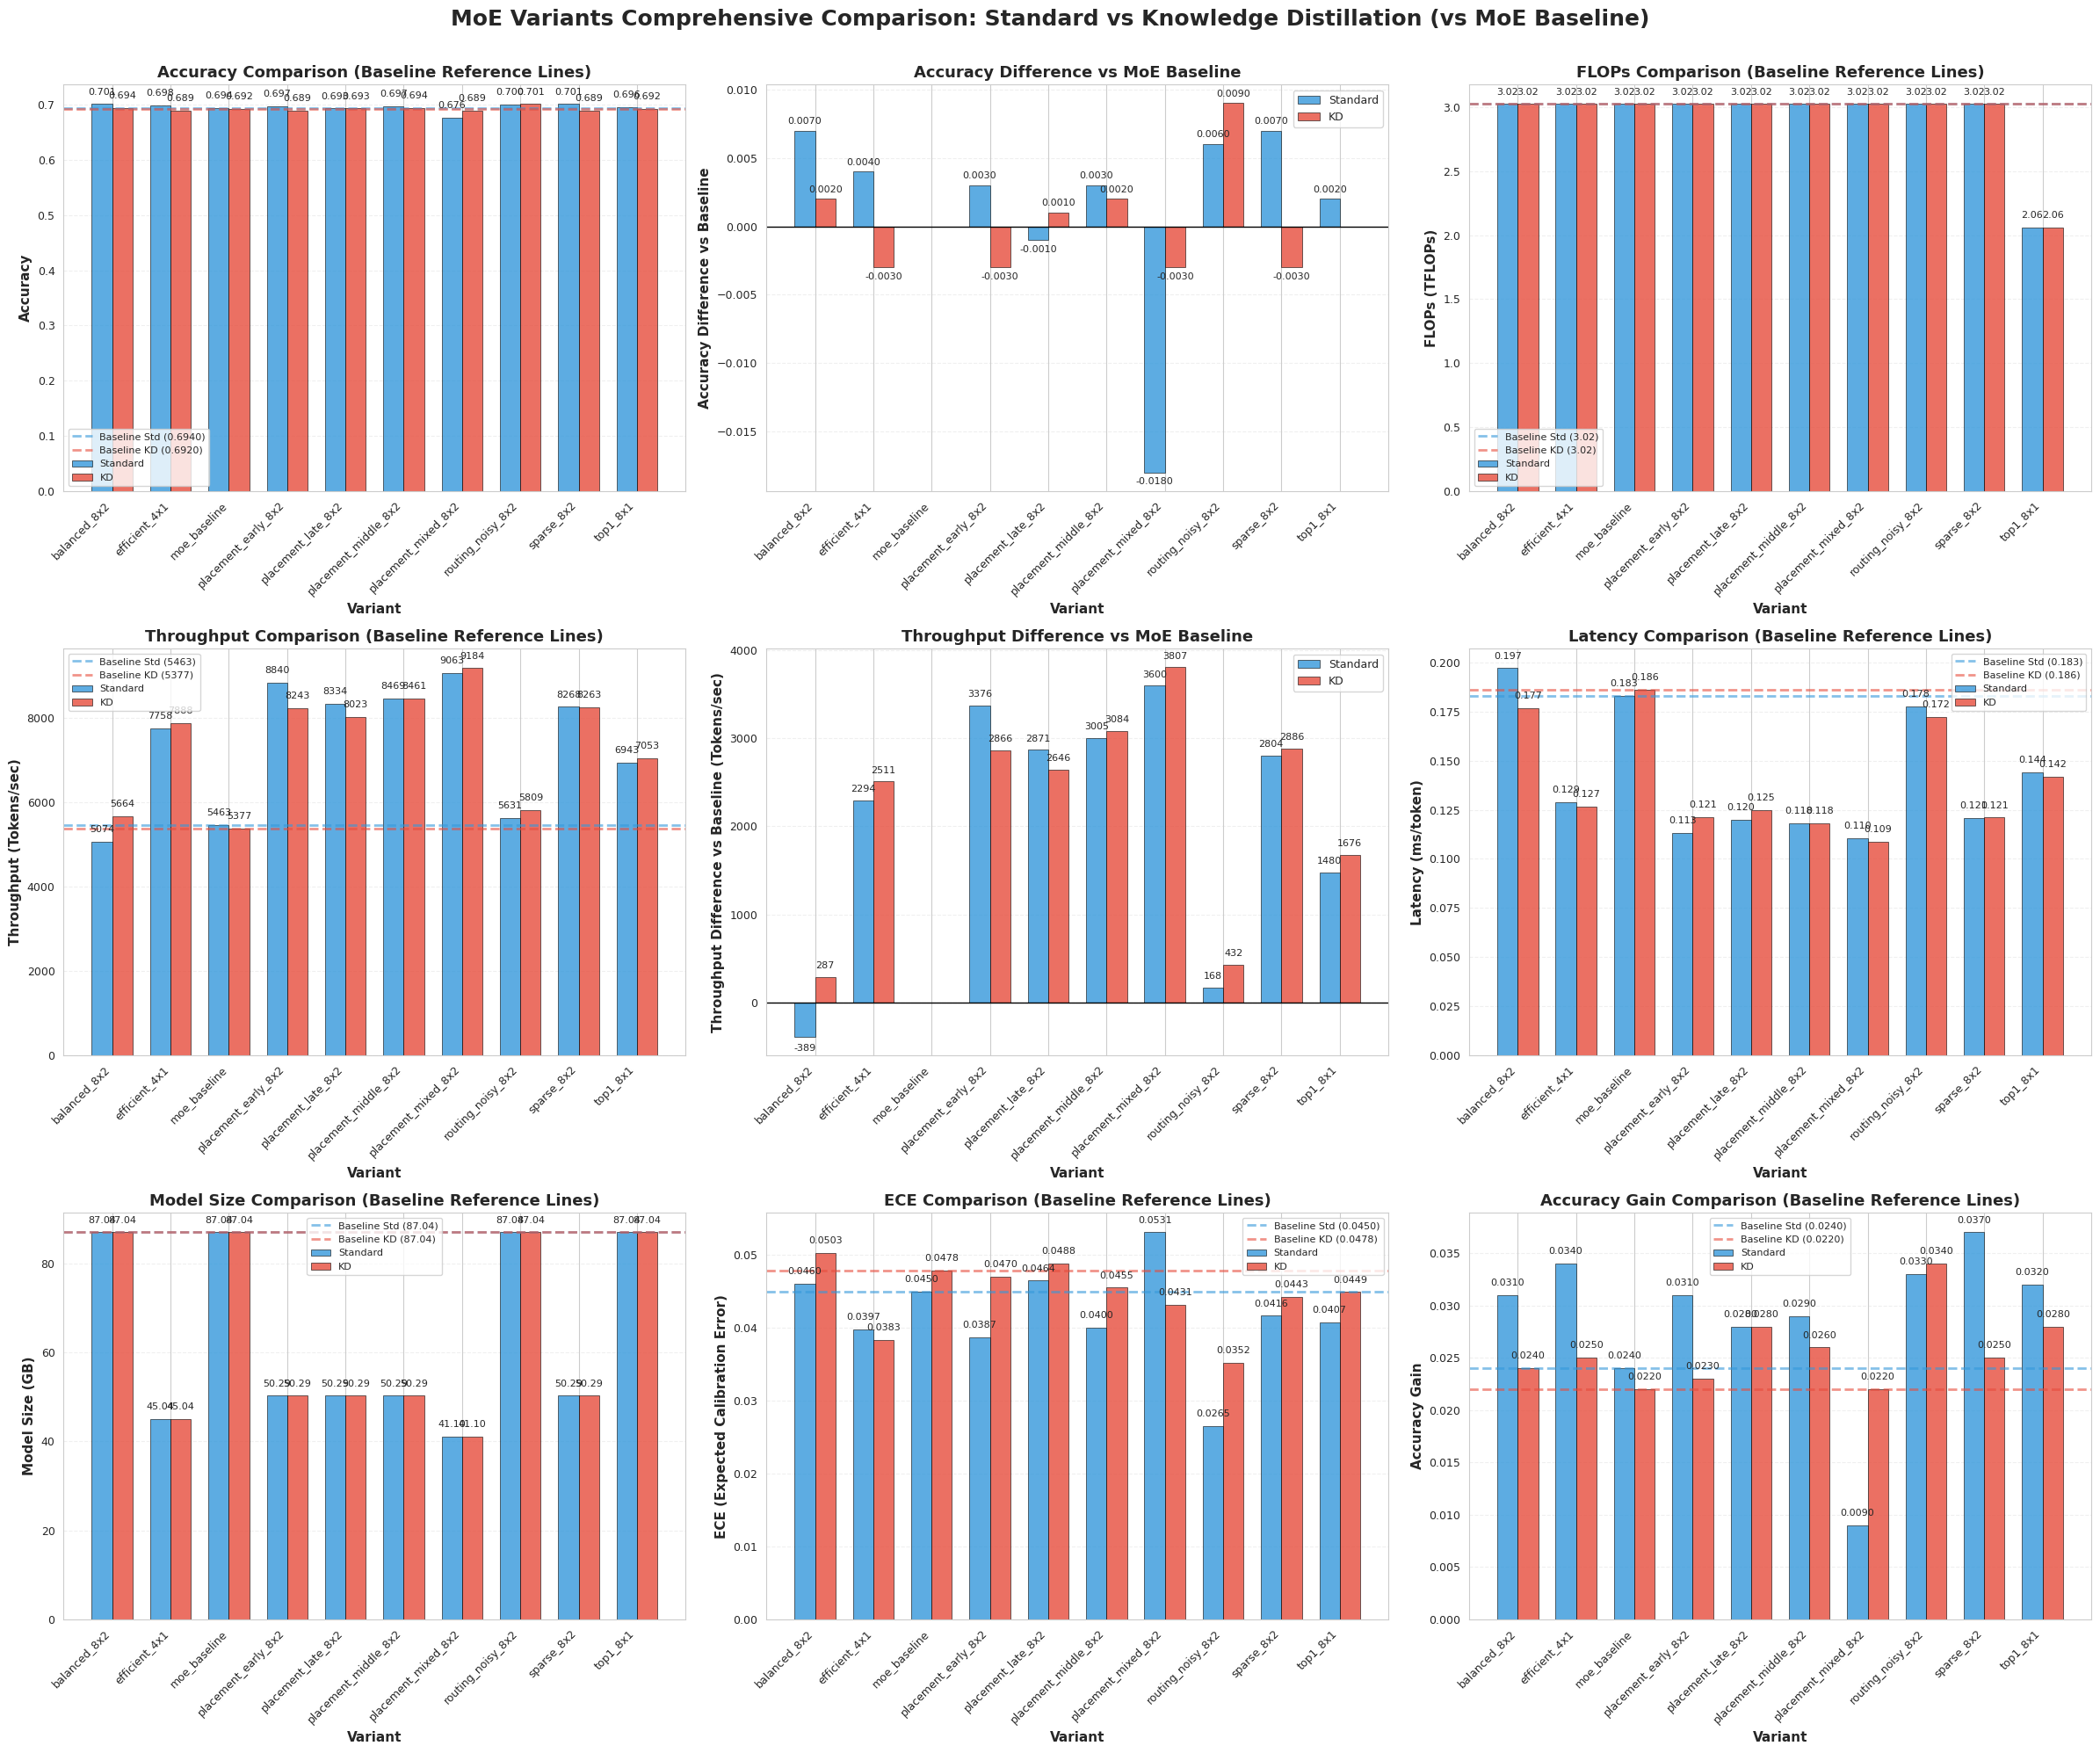


COMPREHENSIVE SUMMARY STATISTICS

Number of MoE variants compared: 10
Variants: balanced_8x2, efficient_4x1, moe_baseline, placement_early_8x2, placement_late_8x2, placement_middle_8x2, placement_mixed_8x2, routing_noisy_8x2, sparse_8x2, top1_8x1

----------------------------------------------------------------------------------------------------
MoE BASELINE REFERENCE VALUES:
  Standard Training:
    Accuracy:     0.6940
    ECE:          0.0450
    Throughput:   5463.2 tokens/sec
    Latency:      0.183 ms/token
    FLOPs:        3.02 TFLOPs
    Model Size:   87.04 GB
    Accuracy Gain: 0.0240
  KD Training:
    Accuracy:     0.6920
    ECE:          0.0478
    Throughput:   5377.0 tokens/sec
    Latency:      0.186 ms/token
    FLOPs:        3.02 TFLOPs
    Model Size:   87.04 GB
    Accuracy Gain: 0.0220

----------------------------------------------------------------------------------------------------
Dense Model Baseline:
  Standard - Accuracy: 0.6590, FLOPs: 8.80 TFLOPs
  KD 

In [58]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import os

# Set style with larger fonts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (24, 20)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10

# Define the experiments directory
experiments_dir = Path("experiments")
results_dir = Path("results")

# Ensure results directory exists
os.makedirs(results_dir, exist_ok=True)

# Find all MoE variant result files
standard_files = sorted(experiments_dir.glob("*_standard_results.json"))
kd_files = sorted(experiments_dir.glob("*_kd_results.json"))

# Extract variant names from file paths
def extract_variant_name(filename):
    """Extract variant name from filename"""
    return filename.stem.replace("_standard_results", "").replace("_kd_results", "")

# Load MoE baseline results (for comparison)
moe_baseline_standard = {}
moe_baseline_kd = {}

# Try to load MoE baseline standard results
baseline_standard_file = experiments_dir / "moe_baseline_standard_results.json"
if baseline_standard_file.exists():
    with open(baseline_standard_file, 'r') as f:
        moe_baseline_standard = json.load(f)
        print(f"Loaded MoE baseline standard: Accuracy={moe_baseline_standard.get('accuracy', 'N/A'):.4f}")

# Try to load MoE baseline KD results
baseline_kd_file = experiments_dir / "moe_baseline_kd_results.json"
if baseline_kd_file.exists():
    with open(baseline_kd_file, 'r') as f:
        moe_baseline_kd = json.load(f)
        print(f"Loaded MoE baseline KD: Accuracy={moe_baseline_kd.get('accuracy', 'N/A'):.4f}")

# Load dense model results
dense_standard = {}
dense_kd = {}

if (results_dir / "baseline_comprehensive.json").exists():
    with open(results_dir / "baseline_comprehensive.json", 'r') as f:
        dense_standard = json.load(f)

if (results_dir / "dense_kd_comprehensive.json").exists():
    with open(results_dir / "dense_kd_comprehensive.json", 'r') as f:
        dense_kd = json.load(f)

# Create a dictionary to store results
results_dict = {}

# Load standard results
for file in standard_files:
    variant_name = extract_variant_name(file)
    with open(file, 'r') as f:
        data = json.load(f)
        if variant_name not in results_dict:
            results_dict[variant_name] = {}
        results_dict[variant_name]['standard'] = data

# Load KD results
for file in kd_files:
    variant_name = extract_variant_name(file)
    with open(file, 'r') as f:
        data = json.load(f)
        if variant_name not in results_dict:
            results_dict[variant_name] = {}
        results_dict[variant_name]['kd'] = data

# Prepare data for visualization
variants = sorted(results_dict.keys())

# Get baseline values for comparison
baseline_std_acc = moe_baseline_standard.get('accuracy', 0) if moe_baseline_standard else 0
baseline_kd_acc = moe_baseline_kd.get('accuracy', 0) if moe_baseline_kd else 0
baseline_std_ece = moe_baseline_standard.get('ece', 0) if moe_baseline_standard else 0
baseline_kd_ece = moe_baseline_kd.get('ece', 0) if moe_baseline_kd else 0
baseline_std_throughput = moe_baseline_standard.get('tokens_per_second', 0) if moe_baseline_standard else 0
baseline_kd_throughput = moe_baseline_kd.get('tokens_per_second', 0) if moe_baseline_kd else 0
baseline_std_latency = moe_baseline_standard.get('ms_per_token', 0) if moe_baseline_standard else 0
baseline_kd_latency = moe_baseline_kd.get('ms_per_token', 0) if moe_baseline_kd else 0
baseline_std_flops = moe_baseline_standard.get('flops', 0) / 1e12 if moe_baseline_standard else 0
baseline_kd_flops = moe_baseline_kd.get('flops', 0) / 1e12 if moe_baseline_kd else 0
baseline_std_size = moe_baseline_standard.get('model_size_mb', 0) / 1024 if moe_baseline_standard else 0
baseline_kd_size = moe_baseline_kd.get('model_size_mb', 0) / 1024 if moe_baseline_kd else 0
baseline_std_gain = moe_baseline_standard.get('accuracy_gain', 0) if moe_baseline_standard else 0
baseline_kd_gain = moe_baseline_kd.get('accuracy_gain', 0) if moe_baseline_kd else 0

# Prepare all data arrays
standard_acc = []
kd_acc = []
standard_acc_diff = []
kd_acc_diff = []
standard_flops = []
kd_flops = []
standard_flops_diff = []
kd_flops_diff = []
standard_throughput = []
kd_throughput = []
standard_throughput_diff = []
kd_throughput_diff = []
standard_latency = []
kd_latency = []
standard_latency_diff = []
kd_latency_diff = []
standard_size = []
kd_size = []
standard_size_diff = []
kd_size_diff = []
standard_gain = []
kd_gain = []
standard_gain_diff = []
kd_gain_diff = []
standard_ece = []
kd_ece = []
standard_ece_diff = []
kd_ece_diff = []
standard_kte = []
kd_kte = []

for variant in variants:
    variant_data = results_dict[variant]
    
    # Accuracy
    if 'standard' in variant_data and 'accuracy' in variant_data['standard']:
        acc = variant_data['standard']['accuracy']
        standard_acc.append(acc)
        standard_acc_diff.append(acc - baseline_std_acc)
    else:
        standard_acc.append(0)
        standard_acc_diff.append(0)
    
    if 'kd' in variant_data and 'accuracy' in variant_data['kd']:
        acc = variant_data['kd']['accuracy']
        kd_acc.append(acc)
        kd_acc_diff.append(acc - baseline_kd_acc)
    else:
        kd_acc.append(0)
        kd_acc_diff.append(0)
    
    # Accuracy Gain
    if 'standard' in variant_data and 'accuracy_gain' in variant_data['standard']:
        gain = variant_data['standard']['accuracy_gain']
        standard_gain.append(gain)
        standard_gain_diff.append(gain - baseline_std_gain)
    else:
        standard_gain.append(0)
        standard_gain_diff.append(0)
    
    if 'kd' in variant_data and 'accuracy_gain' in variant_data['kd']:
        gain = variant_data['kd']['accuracy_gain']
        kd_gain.append(gain)
        kd_gain_diff.append(gain - baseline_kd_gain)
    else:
        kd_gain.append(0)
        kd_gain_diff.append(0)
    
    # FLOPs
    if 'standard' in variant_data and 'flops' in variant_data['standard']:
        flops = variant_data['standard']['flops'] / 1e12
        standard_flops.append(flops)
        standard_flops_diff.append(flops - baseline_std_flops)
    else:
        standard_flops.append(0)
        standard_flops_diff.append(0)
    
    if 'kd' in variant_data and 'flops' in variant_data['kd']:
        flops = variant_data['kd']['flops'] / 1e12
        kd_flops.append(flops)
        kd_flops_diff.append(flops - baseline_kd_flops)
    else:
        kd_flops.append(0)
        kd_flops_diff.append(0)
    
    # Throughput (tokens per second)
    if 'standard' in variant_data and 'tokens_per_second' in variant_data['standard']:
        throughput = variant_data['standard']['tokens_per_second']
        standard_throughput.append(throughput)
        standard_throughput_diff.append(throughput - baseline_std_throughput)
    else:
        standard_throughput.append(0)
        standard_throughput_diff.append(0)
    
    if 'kd' in variant_data and 'tokens_per_second' in variant_data['kd']:
        throughput = variant_data['kd']['tokens_per_second']
        kd_throughput.append(throughput)
        kd_throughput_diff.append(throughput - baseline_kd_throughput)
    else:
        kd_throughput.append(0)
        kd_throughput_diff.append(0)
    
    # Latency (ms per token)
    if 'standard' in variant_data and 'ms_per_token' in variant_data['standard']:
        latency = variant_data['standard']['ms_per_token']
        standard_latency.append(latency)
        standard_latency_diff.append(latency - baseline_std_latency)
    else:
        standard_latency.append(0)
        standard_latency_diff.append(0)
    
    if 'kd' in variant_data and 'ms_per_token' in variant_data['kd']:
        latency = variant_data['kd']['ms_per_token']
        kd_latency.append(latency)
        kd_latency_diff.append(latency - baseline_kd_latency)
    else:
        kd_latency.append(0)
        kd_latency_diff.append(0)
    
    # Model Size (convert MB to GB)
    if 'standard' in variant_data and 'model_size_mb' in variant_data['standard']:
        size = variant_data['standard']['model_size_mb'] / 1024
        standard_size.append(size)
        standard_size_diff.append(size - baseline_std_size)
    else:
        standard_size.append(0)
        standard_size_diff.append(0)
    
    if 'kd' in variant_data and 'model_size_mb' in variant_data['kd']:
        size = variant_data['kd']['model_size_mb'] / 1024
        kd_size.append(size)
        kd_size_diff.append(size - baseline_kd_size)
    else:
        kd_size.append(0)
        kd_size_diff.append(0)
    
    # ECE
    if 'standard' in variant_data and 'ece' in variant_data['standard']:
        ece = variant_data['standard']['ece']
        standard_ece.append(ece)
        standard_ece_diff.append(ece - baseline_std_ece)
    else:
        standard_ece.append(0)
        standard_ece_diff.append(0)
    
    if 'kd' in variant_data and 'ece' in variant_data['kd']:
        ece = variant_data['kd']['ece']
        kd_ece.append(ece)
        kd_ece_diff.append(ece - baseline_kd_ece)
    else:
        kd_ece.append(0)
        kd_ece_diff.append(0)
    
    # KTE (Knowledge Transfer Efficiency)
    if 'standard' in variant_data:
        std_data = variant_data['standard']
        if 'accuracy_gain' in std_data and std_data['accuracy_gain'] > 0:
            standard_kte.append(std_data['accuracy_gain'] * 100)  # Convert to percentage
        else:
            standard_kte.append(0)
    else:
        standard_kte.append(0)
    
    if 'kd' in variant_data:
        kd_data = variant_data['kd']
        if 'accuracy_gain' in kd_data and kd_data['accuracy_gain'] > 0:
            kd_kte.append(kd_data['accuracy_gain'] * 100)  # Convert to percentage
        else:
            kd_kte.append(0)
    else:
        kd_kte.append(0)

# Prepare dense model data for comparison
dense_standard_flops = dense_standard.get('flops', 0) / 1e12 if dense_standard else 0
dense_kd_flops = dense_kd.get('flops', 0) / 1e12 if dense_kd else 0

# Create the plots - 3 rows, 3 columns for 9 graphs
fig, axes = plt.subplots(3, 3, figsize=(24, 20))
fig.suptitle('MoE Variants Comprehensive Comparison: Standard vs Knowledge Distillation (vs MoE Baseline)', 
             fontsize=18, fontweight='bold', y=0.995)

x = np.arange(len(variants))
width = 0.35

# Helper function to add value labels
def add_value_labels(ax, bars, format_str='{:.3f}', offset_factor=0.02):
    """Add value labels on bars"""
    max_height = max([abs(bar.get_height()) for bar in bars if bar.get_height() != 0], default=0)
    y_offset = max_height * offset_factor if max_height > 0 else 0.01
    
    for bar in bars:
        height = bar.get_height()
        if height != 0:
            label_y = height + (y_offset if height >= 0 else -y_offset)
            ax.text(bar.get_x() + bar.get_width()/2., label_y,
                   format_str.format(height),
                   ha='center', va='bottom' if height >= 0 else 'top', 
                   fontsize=8, rotation=0)

# 1. Accuracy Comparison (Top-Left) - with baseline reference
ax1 = axes[0, 0]
bars1_std = ax1.bar(x - width/2, standard_acc, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars1_kd = ax1.bar(x + width/2, kd_acc, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
if baseline_std_acc > 0:
    ax1.axhline(y=baseline_std_acc, color='#3498db', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline Std ({baseline_std_acc:.4f})')
if baseline_kd_acc > 0:
    ax1.axhline(y=baseline_kd_acc, color='#e74c3c', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline KD ({baseline_kd_acc:.4f})')
ax1.set_xlabel('Variant', fontweight='bold')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Accuracy Comparison (Baseline Reference Lines)', fontweight='bold', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='best', fontsize=8)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(bottom=0)
add_value_labels(ax1, bars1_std + bars1_kd, '{:.3f}')

# 2. Accuracy Difference vs Baseline (Top-Middle)
ax2 = axes[0, 1]
bars2_std = ax2.bar(x - width/2, standard_acc_diff, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars2_kd = ax2.bar(x + width/2, kd_acc_diff, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Variant', fontweight='bold')
ax2.set_ylabel('Accuracy Difference vs Baseline', fontweight='bold')
ax2.set_title('Accuracy Difference vs MoE Baseline', fontweight='bold', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='best', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
add_value_labels(ax2, bars2_std + bars2_kd, '{:.4f}')

# 3. FLOPs Comparison (Top-Right) - with baseline reference
ax3 = axes[0, 2]
bars3_std = ax3.bar(x - width/2, standard_flops, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars3_kd = ax3.bar(x + width/2, kd_flops, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
if baseline_std_flops > 0:
    ax3.axhline(y=baseline_std_flops, color='#3498db', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline Std ({baseline_std_flops:.2f})')
if baseline_kd_flops > 0:
    ax3.axhline(y=baseline_kd_flops, color='#e74c3c', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline KD ({baseline_kd_flops:.2f})')
ax3.set_xlabel('Variant', fontweight='bold')
ax3.set_ylabel('FLOPs (TFLOPs)', fontweight='bold')
ax3.set_title('FLOPs Comparison (Baseline Reference Lines)', fontweight='bold', fontsize=13)
ax3.set_xticks(x)
ax3.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax3.legend(loc='best', fontsize=8)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_ylim(bottom=0)
add_value_labels(ax3, bars3_std + bars3_kd, '{:.2f}')

# 4. Throughput Comparison (Middle-Left) - with baseline reference
ax4 = axes[1, 0]
bars4_std = ax4.bar(x - width/2, standard_throughput, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars4_kd = ax4.bar(x + width/2, kd_throughput, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
if baseline_std_throughput > 0:
    ax4.axhline(y=baseline_std_throughput, color='#3498db', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline Std ({baseline_std_throughput:.0f})')
if baseline_kd_throughput > 0:
    ax4.axhline(y=baseline_kd_throughput, color='#e74c3c', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline KD ({baseline_kd_throughput:.0f})')
ax4.set_xlabel('Variant', fontweight='bold')
ax4.set_ylabel('Throughput (Tokens/sec)', fontweight='bold')
ax4.set_title('Throughput Comparison (Baseline Reference Lines)', fontweight='bold', fontsize=13)
ax4.set_xticks(x)
ax4.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax4.legend(loc='best', fontsize=8)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.set_ylim(bottom=0)
add_value_labels(ax4, bars4_std + bars4_kd, '{:.0f}')

# 5. Throughput Difference vs Baseline (Middle-Middle)
ax5 = axes[1, 1]
bars5_std = ax5.bar(x - width/2, standard_throughput_diff, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars5_kd = ax5.bar(x + width/2, kd_throughput_diff, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
ax5.set_xlabel('Variant', fontweight='bold')
ax5.set_ylabel('Throughput Difference vs Baseline (Tokens/sec)', fontweight='bold')
ax5.set_title('Throughput Difference vs MoE Baseline', fontweight='bold', fontsize=13)
ax5.set_xticks(x)
ax5.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax5.legend(loc='best', fontsize=9)
ax5.grid(axis='y', alpha=0.3, linestyle='--')
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
add_value_labels(ax5, bars5_std + bars5_kd, '{:.0f}')

# 6. Latency Comparison (Middle-Right) - with baseline reference
ax6 = axes[1, 2]
bars6_std = ax6.bar(x - width/2, standard_latency, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars6_kd = ax6.bar(x + width/2, kd_latency, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
if baseline_std_latency > 0:
    ax6.axhline(y=baseline_std_latency, color='#3498db', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline Std ({baseline_std_latency:.3f})')
if baseline_kd_latency > 0:
    ax6.axhline(y=baseline_kd_latency, color='#e74c3c', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline KD ({baseline_kd_latency:.3f})')
ax6.set_xlabel('Variant', fontweight='bold')
ax6.set_ylabel('Latency (ms/token)', fontweight='bold')
ax6.set_title('Latency Comparison (Baseline Reference Lines)', fontweight='bold', fontsize=13)
ax6.set_xticks(x)
ax6.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax6.legend(loc='best', fontsize=8)
ax6.grid(axis='y', alpha=0.3, linestyle='--')
ax6.set_ylim(bottom=0)
add_value_labels(ax6, bars6_std + bars6_kd, '{:.3f}')

# 7. Model Size Comparison (Bottom-Left) - with baseline reference
ax7 = axes[2, 0]
bars7_std = ax7.bar(x - width/2, standard_size, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars7_kd = ax7.bar(x + width/2, kd_size, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
if baseline_std_size > 0:
    ax7.axhline(y=baseline_std_size, color='#3498db', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline Std ({baseline_std_size:.2f})')
if baseline_kd_size > 0:
    ax7.axhline(y=baseline_kd_size, color='#e74c3c', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline KD ({baseline_kd_size:.2f})')
ax7.set_xlabel('Variant', fontweight='bold')
ax7.set_ylabel('Model Size (GB)', fontweight='bold')
ax7.set_title('Model Size Comparison (Baseline Reference Lines)', fontweight='bold', fontsize=13)
ax7.set_xticks(x)
ax7.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax7.legend(loc='best', fontsize=8)
ax7.grid(axis='y', alpha=0.3, linestyle='--')
ax7.set_ylim(bottom=0)
add_value_labels(ax7, bars7_std + bars7_kd, '{:.2f}')

# 8. ECE Comparison (Bottom-Middle) - with baseline reference
ax8 = axes[2, 1]
bars8_std = ax8.bar(x - width/2, standard_ece, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars8_kd = ax8.bar(x + width/2, kd_ece, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
if baseline_std_ece > 0:
    ax8.axhline(y=baseline_std_ece, color='#3498db', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline Std ({baseline_std_ece:.4f})')
if baseline_kd_ece > 0:
    ax8.axhline(y=baseline_kd_ece, color='#e74c3c', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline KD ({baseline_kd_ece:.4f})')
ax8.set_xlabel('Variant', fontweight='bold')
ax8.set_ylabel('ECE (Expected Calibration Error)', fontweight='bold')
ax8.set_title('ECE Comparison (Baseline Reference Lines)', fontweight='bold', fontsize=13)
ax8.set_xticks(x)
ax8.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax8.legend(loc='best', fontsize=8)
ax8.grid(axis='y', alpha=0.3, linestyle='--')
ax8.set_ylim(bottom=0)
add_value_labels(ax8, bars8_std + bars8_kd, '{:.4f}')

# 9. Accuracy Gain Comparison (Bottom-Right) - with baseline reference
ax9 = axes[2, 2]
bars9_std = ax9.bar(x - width/2, standard_gain, width, label='Standard', 
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
bars9_kd = ax9.bar(x + width/2, kd_gain, width, label='KD', 
                   color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
if baseline_std_gain > 0:
    ax9.axhline(y=baseline_std_gain, color='#3498db', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline Std ({baseline_std_gain:.4f})')
if baseline_kd_gain > 0:
    ax9.axhline(y=baseline_kd_gain, color='#e74c3c', linestyle='--', linewidth=2, 
                alpha=0.6, label=f'Baseline KD ({baseline_kd_gain:.4f})')
ax9.set_xlabel('Variant', fontweight='bold')
ax9.set_ylabel('Accuracy Gain', fontweight='bold')
ax9.set_title('Accuracy Gain Comparison (Baseline Reference Lines)', fontweight='bold', fontsize=13)
ax9.set_xticks(x)
ax9.set_xticklabels(variants, rotation=45, ha='right', fontsize=9)
ax9.legend(loc='best', fontsize=8)
ax9.grid(axis='y', alpha=0.3, linestyle='--')
ax9.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
add_value_labels(ax9, bars9_std + bars9_kd, '{:.4f}')

plt.tight_layout(rect=[0, 0, 1, 0.99])

# Save the figure automatically
save_path = results_dir / "moe_variants.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\nVisualization saved to: {save_path}")

plt.show()

# Print comprehensive summary statistics with baseline comparisons
print("\n" + "="*100)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*100)
print(f"\nNumber of MoE variants compared: {len(variants)}")
print(f"Variants: {', '.join(variants)}")

print("\n" + "-"*100)
print("MoE BASELINE REFERENCE VALUES:")
if moe_baseline_standard:
    print(f"  Standard Training:")
    print(f"    Accuracy:     {baseline_std_acc:.4f}")
    print(f"    ECE:          {baseline_std_ece:.4f}")
    print(f"    Throughput:   {baseline_std_throughput:.1f} tokens/sec")
    print(f"    Latency:      {baseline_std_latency:.3f} ms/token")
    print(f"    FLOPs:        {baseline_std_flops:.2f} TFLOPs")
    print(f"    Model Size:   {baseline_std_size:.2f} GB")
    print(f"    Accuracy Gain: {baseline_std_gain:.4f}")
if moe_baseline_kd:
    print(f"  KD Training:")
    print(f"    Accuracy:     {baseline_kd_acc:.4f}")
    print(f"    ECE:          {baseline_kd_ece:.4f}")
    print(f"    Throughput:   {baseline_kd_throughput:.1f} tokens/sec")
    print(f"    Latency:      {baseline_kd_latency:.3f} ms/token")
    print(f"    FLOPs:        {baseline_kd_flops:.2f} TFLOPs")
    print(f"    Model Size:   {baseline_kd_size:.2f} GB")
    print(f"    Accuracy Gain: {baseline_kd_gain:.4f}")

print("\n" + "-"*100)
print("Dense Model Baseline:")
if dense_standard:
    print(f"  Standard - Accuracy: {dense_standard.get('accuracy', 'N/A'):.4f}, "
          f"FLOPs: {dense_standard_flops:.2f} TFLOPs")
if dense_kd:
    print(f"  KD       - Accuracy: {dense_kd.get('accuracy', 'N/A'):.4f}, "
          f"FLOPs: {dense_kd_flops:.2f} TFLOPs")

print("\n" + "-"*100)
print("MoE VARIANTS - ABSOLUTE VALUES:")
print(f"  Accuracy Range:")
print(f"    Standard: {min(standard_acc):.4f} - {max(standard_acc):.4f} (Baseline: {baseline_std_acc:.4f})")
print(f"    KD:       {min(kd_acc):.4f} - {max(kd_acc):.4f} (Baseline: {baseline_kd_acc:.4f})")
print(f"  FLOPs Range (TFLOPs):")
print(f"    Standard: {min(standard_flops):.2f} - {max(standard_flops):.2f} (Baseline: {baseline_std_flops:.2f})")
print(f"    KD:       {min(kd_flops):.2f} - {max(kd_flops):.2f} (Baseline: {baseline_kd_flops:.2f})")
print(f"  Throughput Range (tokens/sec):")
print(f"    Standard: {min(standard_throughput):.1f} - {max(standard_throughput):.1f} (Baseline: {baseline_std_throughput:.1f})")
print(f"    KD:       {min(kd_throughput):.1f} - {max(kd_throughput):.1f} (Baseline: {baseline_kd_throughput:.1f})")
print(f"  Latency Range (ms/token):")
print(f"    Standard: {min(standard_latency):.3f} - {max(standard_latency):.3f} (Baseline: {baseline_std_latency:.3f})")
print(f"    KD:       {min(kd_latency):.3f} - {max(kd_latency):.3f} (Baseline: {baseline_kd_latency:.3f})")
print(f"  Model Size Range (GB):")
print(f"    Standard: {min(standard_size):.2f} - {max(standard_size):.2f} (Baseline: {baseline_std_size:.2f})")
print(f"    KD:       {min(kd_size):.2f} - {max(kd_size):.2f} (Baseline: {baseline_kd_size:.2f})")
print(f"  ECE Range:")
print(f"    Standard: {min(standard_ece):.4f} - {max(standard_ece):.4f} (Baseline: {baseline_std_ece:.4f})")
print(f"    KD:       {min(kd_ece):.4f} - {max(kd_ece):.4f} (Baseline: {baseline_kd_ece:.4f})")
print(f"  Accuracy Gain Range:")
print(f"    Standard: {min(standard_gain):.4f} - {max(standard_gain):.4f} (Baseline: {baseline_std_gain:.4f})")
print(f"    KD:       {min(kd_gain):.4f} - {max(kd_gain):.4f} (Baseline: {baseline_kd_gain:.4f})")

print("\n" + "-"*100)
print("MoE VARIANTS - DIFFERENCES VS BASELINE:")
if standard_acc_diff:
    print(f"  Accuracy Difference:")
    print(f"    Standard: {min(standard_acc_diff):.4f} to {max(standard_acc_diff):.4f} "
          f"(Avg: {np.mean(standard_acc_diff):.4f})")
    print(f"    KD:       {min(kd_acc_diff):.4f} to {max(kd_acc_diff):.4f} "
          f"(Avg: {np.mean(kd_acc_diff):.4f})")
if standard_throughput_diff:
    print(f"  Throughput Difference (tokens/sec):")
    print(f"    Standard: {min(standard_throughput_diff):.1f} to {max(standard_throughput_diff):.1f} "
          f"(Avg: {np.mean(standard_throughput_diff):.1f})")
    print(f"    KD:       {min(kd_throughput_diff):.1f} to {max(kd_throughput_diff):.1f} "
          f"(Avg: {np.mean(kd_throughput_diff):.1f})")
if standard_latency_diff:
    print(f"  Latency Difference (ms/token):")
    print(f"    Standard: {min(standard_latency_diff):.3f} to {max(standard_latency_diff):.3f} "
          f"(Avg: {np.mean(standard_latency_diff):.3f})")
    print(f"    KD:       {min(kd_latency_diff):.3f} to {max(kd_latency_diff):.3f} "
          f"(Avg: {np.mean(kd_latency_diff):.3f})")
if standard_flops_diff:
    print(f"  FLOPs Difference (TFLOPs):")
    print(f"    Standard: {min(standard_flops_diff):.2f} to {max(standard_flops_diff):.2f} "
          f"(Avg: {np.mean(standard_flops_diff):.2f})")
    print(f"    KD:       {min(kd_flops_diff):.2f} to {max(kd_flops_diff):.2f} "
          f"(Avg: {np.mean(kd_flops_diff):.2f})")
if standard_size_diff:
    print(f"  Model Size Difference (GB):")
    print(f"    Standard: {min(standard_size_diff):.2f} to {max(standard_size_diff):.2f} "
          f"(Avg: {np.mean(standard_size_diff):.2f})")
    print(f"    KD:       {min(kd_size_diff):.2f} to {max(kd_size_diff):.2f} "
          f"(Avg: {np.mean(kd_size_diff):.2f})")
if standard_ece_diff:
    print(f"  ECE Difference:")
    print(f"    Standard: {min(standard_ece_diff):.4f} to {max(standard_ece_diff):.4f} "
          f"(Avg: {np.mean(standard_ece_diff):.4f})")
    print(f"    KD:       {min(kd_ece_diff):.4f} to {max(kd_ece_diff):.4f} "
          f"(Avg: {np.mean(kd_ece_diff):.4f})")
if standard_gain_diff:
    print(f"  Accuracy Gain Difference:")
    print(f"    Standard: {min(standard_gain_diff):.4f} to {max(standard_gain_diff):.4f} "
          f"(Avg: {np.mean(standard_gain_diff):.4f})")
    print(f"    KD:       {min(kd_gain_diff):.4f} to {max(kd_gain_diff):.4f} "
          f"(Avg: {np.mean(kd_gain_diff):.4f})")

print("\n" + "-"*100)
print("MoE VARIANTS - KTE RANGE (%):")
if standard_kte:
    print(f"  Standard: {min(standard_kte):.2f}% to {max(standard_kte):.2f}%")
if kd_kte:
    print(f"  KD:       {min(kd_kte):.2f}% to {max(kd_kte):.2f}%")
print("="*100)